# Stage1

In [ ]:
# ============================================================
# CELL 1 — Install All Required Libraries
# ============================================================
!pip install transformers torch spacy pandas numpy scikit-learn -q
!pip install datasets accelerate sentencepiece -q
!pip install matplotlib seaborn tqdm psutil -q
!python -m spacy download en_core_web_sm

print("✅ All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


In [ ]:
# ============================================================
# CELL 2 — Import All Libraries
# ============================================================
import os
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

# NLP
import spacy

# HuggingFace / PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# Load SpaCy
nlp_spacy = spacy.load("en_core_web_sm")

print("✅ All libraries imported!")
print(f"   PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device   : {device}")

✅ All libraries imported!
   PyTorch  : 2.10.0+cu128
   CUDA     : True
   Device   : cuda


In [ ]:
# ============================================================
# CELL 3 — Mount Google Drive & Set Paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ── Set your exact folder paths ─────────────────────────────
BASE_PATH          = '/content/drive/MyDrive/FinancialNLP_Data'
FINPHRASEBANK_PATH = os.path.join(BASE_PATH, 'FinancialPhraseBank')
FINRED_PATH        = os.path.join(BASE_PATH, 'FinRED dataset')
MATRES_PATH        = os.path.join(BASE_PATH, 'MATRES-master')

OUTPUT_DIR = '/content/financial_nlp_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify paths exist
for name, path in [('FinancialPhraseBank', FINPHRASEBANK_PATH),
                   ('FinRED',              FINRED_PATH),
                   ('MATRES',              MATRES_PATH)]:
    status = "✅" if os.path.exists(path) else "❌ NOT FOUND"
    print(f"   {status}  {name}: {path}")

Mounted at /content/drive
   ✅  FinancialPhraseBank: /content/drive/MyDrive/FinancialNLP_Data/FinancialPhraseBank
   ✅  FinRED: /content/drive/MyDrive/FinancialNLP_Data/FinRED dataset
   ✅  MATRES: /content/drive/MyDrive/FinancialNLP_Data/MATRES-master


In [ ]:
# ============================================================
# CELL 4 — Load FinancialPhraseBank
# ============================================================
# CONFIRMED FORMAT from diagnostic:
# 'According to Gran , the company has no plans .@neutral'
# Sentence and label separated by LAST '@' character
# Labels: positive / negative / neutral

def load_financial_phrasebank_txt(path):
    filepath = os.path.join(path, 'Sentences_AllAgree.txt')
    records  = []

    with open(filepath, 'r', encoding='latin-1') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if '@' not in line:
                continue

            # Split from the LAST '@' only
            last_at  = line.rfind('@')
            sentence = line[:last_at].strip()
            label    = line[last_at + 1:].strip().lower()

            # Only keep rows with valid labels
            if label not in ['positive', 'negative', 'neutral']:
                continue
            # Only keep sentences with meaningful length
            if len(sentence) < 5:
                continue

            records.append({
                'sentence': sentence,
                'label'   : label
            })

    df = pd.DataFrame(records)
    print(f" FinancialPhraseBank (Sentences_AllAgree.txt) loaded: {len(df):,} sentences")
    print(f"\n Label distribution for Sentences_AllAgree.txt:")
    print(df['label'].value_counts())
    return df

def load_all_data_csv_from_bank(path):
    filepath = os.path.join(path, 'all-data.csv')
    df_all_data = pd.DataFrame()
    try:
        # Try utf-8 first, then fall back to latin-1 if there's an encoding error
        try:
            # Specify header=None as the file does not have a header
            df_all_data = pd.read_csv(filepath, encoding='utf-8', header=None)
        except UnicodeDecodeError:
            print(f"   (Retrying all-data.csv with 'latin-1' encoding)")
            df_all_data = pd.read_csv(filepath, encoding='latin-1', header=None)

        # Manually assign column names after reading without a header
        # Based on inspection, the first column is label, second is sentence
        df_all_data.columns = ['label', 'sentence']

        if 'sentence' in df_all_data.columns and 'label' in df_all_data.columns:
            df_all_data = df_all_data[['sentence', 'label']]
            df_all_data['label'] = df_all_data['label'].astype(str).str.lower()
            valid_labels = ['positive', 'negative', 'neutral']
            df_all_data = df_all_data[df_all_data['label'].isin(valid_labels)]
            print(f"✅ FinancialPhraseBank (all-data.csv) loaded: {len(df_all_data):,} sentences")
            print(f"\n Label distribution for all-data.csv:")
            print(df_all_data['label'].value_counts())
        else:
            # This case should ideally not be hit after manual column assignment
            print(f"❌ Warning: 'all-data.csv' at {filepath} does not contain 'sentence' and 'label' columns as expected. Skipping this file.")
            df_all_data = pd.DataFrame() # Return empty if columns are missing
    except FileNotFoundError:
        print(f"❌ Error: 'all-data.csv' not found at {filepath}. Skipping loading this file.")
        df_all_data = pd.DataFrame()
    except Exception as e:
        print(f"❌ An error occurred while loading all-data.csv from {filepath}: {e}")
        df_all_data = pd.DataFrame()
    return df_all_data

# Load Sentences_AllAgree.txt
fpb_df_all_agree = load_financial_phrasebank_txt(FINPHRASEBANK_PATH)

# Load all-data.csv from the same path
fpb_df_all_data = load_all_data_csv_from_bank(FINPHRASEBANK_PATH)

# Combine the two dataframes
if not fpb_df_all_data.empty:
    fpb_df = pd.concat([fpb_df_all_agree, fpb_df_all_data], ignore_index=True)
    print(f"✅ Combined FinancialPhraseBank data loaded: {len(fpb_df):,} sentences")
    print(f"\n Overall Label distribution:")
    print(fpb_df['label'].value_counts())
else:
    fpb_df = fpb_df_all_agree # If all-data.csv failed to load, just use the first one
    print(f"Using only Sentences_AllAgree.txt data as all-data.csv could not be loaded or was empty.")

print(f"\n📋 Sample rows of combined data:")
print(fpb_df.head(3).to_string())

 FinancialPhraseBank (Sentences_AllAgree.txt) loaded: 2,264 sentences

 Label distribution for Sentences_AllAgree.txt:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64
   (Retrying all-data.csv with 'latin-1' encoding)
✅ FinancialPhraseBank (all-data.csv) loaded: 4,846 sentences

 Label distribution for all-data.csv:
label
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64
✅ Combined FinancialPhraseBank data loaded: 7,110 sentences

 Overall Label distribution:
label
neutral     4270
positive    1933
negative     907
Name: count, dtype: int64

📋 Sample rows of combined data:
                                                                                                                                                                                            sentence     label
0                                                                    According to Gran , the company has no plans to move all production to Russia , al

In [ ]:
# ============================================================
# CELL 5 — Load FinRED Dataset
# ============================================================
# CONFIRMED FORMAT from diagnostic:
# train.sent → one full sentence per line
# train.tup  → 'entity1 ; entity2 ; relation | entity1 ; entity2 ; relation'
# Example tup: 'Apple Inc ; Steve Jobs ; founded_by | Apple Inc ; Steve Jobs ; chief_executive_officer'

def load_finred_split(path, split='train'):
    sent_file = os.path.join(path, f'{split}.sent')
    tup_file  = os.path.join(path, f'{split}.tup')

    # Read sentences — keep ALL lines, preserve index alignment
    with open(sent_file, 'r', encoding='utf-8') as f:
        sentences = [line.rstrip('\n') for line in f]

    # Read tuples — keep ALL lines, preserve index alignment
    with open(tup_file, 'r', encoding='utf-8') as f:
        tuples = [line.rstrip('\n') for line in f]

    records = []
    for sent, tup_line in zip(sentences, tuples):
        # Skip only if sentence is completely empty
        if not sent.strip():
            continue

        # Each line can have multiple relations separated by ' | '
        relation_parts = tup_line.split('|')

        for rel in relation_parts:
            rel = rel.strip()
            if not rel:
                continue

            # Split by ';' — format: entity1 ; entity2 ; relation_type
            parts = [p.strip() for p in rel.split(';')]

            if len(parts) == 3:
                entity1       = parts[0].strip()
                relation_type = parts[1].strip()
                entity2       = parts[2].strip()
            elif len(parts) == 2:
                entity1       = parts[0].strip()
                relation_type = parts[1].strip()
                entity2       = ''
            elif len(parts) == 1:
                entity1       = ''
                relation_type = parts[0].strip()
                entity2       = ''
            else:
                continue

            records.append({
                'sentence'     : sent.strip(),
                'entity1'      : entity1,
                'relation_type': relation_type,
                'entity2'      : entity2,
                'split'        : split
            })

    df = pd.DataFrame(records)
    print(f"✅ FinRED [{split:5s}] loaded: {len(df):,} relation instances")
    return df

finred_train = load_finred_split(FINRED_PATH, 'train')
finred_dev   = load_finred_split(FINRED_PATH, 'dev')
finred_test  = load_finred_split(FINRED_PATH, 'test')

finred_df = pd.concat([finred_train, finred_dev, finred_test],
                       ignore_index=True)

print(f"\n📊 FinRED total records : {len(finred_df):,}")
print(f"\n📊 Top 10 relation types:")
print(finred_df['relation_type'].value_counts().head(10))
print(f"\n📋 Sample rows:")
print(finred_df.head(3).to_string())

✅ FinRED [train] loaded: 8,079 relation instances
✅ FinRED [dev  ] loaded: 1,554 relation instances
✅ FinRED [test ] loaded: 1,488 relation instances

📊 FinRED total records : 11,121

📊 Top 10 relation types:
relation_type
London                   264
retail                   251
Microsoft                244
Google                   185
mining                   163
London Stock Exchange    152
software                 124
General Motors           107
3D printing               98
aircraft                  97
Name: count, dtype: int64

📋 Sample rows:
                                                                                                                                                                                                                sentence        entity1 relation_type                  entity2  split
0  NEW YORK (Reuters) - Apple Inc Chief Executive Steve Jobs sought to soothe investor concerns about his health on Monday, saying his weight loss was caused by a horm

In [ ]:
# ============================================================
# CELL 6 — Load MATRES Dataset
# ============================================================
# CONFIRMED FORMAT from diagnostic:
# 'ABC19980120.1830.0957\ttpredicted\ttried\tt415\tt417\tBEFORE'
# Tab-separated, EVERY line is real data (no headers/comments)
# Columns: docID  event1  event2  tID1  tID2  ...  LABEL(last)
# We take: col[0]=docID, col[1]=event1, col[2]=event2, col[-1]=label

VALID_MATRES_LABELS = {'BEFORE', 'AFTER', 'SIMULTANEOUS', 'VAGUE'}

def load_matres_file(filepath, source_name):
    records = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')

            # Skip genuinely empty lines only
            if not line.strip():
                continue

            parts = line.split('\t')

            # Need at least 4 columns to have docID+event1+event2+label
            if len(parts) < 4:
                continue

            doc_id = parts[0].strip()
            event1 = parts[1].strip()
            event2 = parts[2].strip()
            label  = parts[-1].strip()   # LAST column is always the label

            # Skip if label is not a valid temporal relation
            if label not in VALID_MATRES_LABELS:
                continue

            # Skip only if event fields are completely empty
            if not event1 or not event2:
                continue

            records.append({
                'doc_id'  : doc_id,
                'event1'  : event1,
                'event2'  : event2,
                'relation': label,
                'source'  : source_name
            })

    df = pd.DataFrame(records)
    print(f"✅ MATRES [{source_name:8s}]: {len(df):,} valid event pairs loaded")
    return df

def load_matres_all(path):
    tb_df = load_matres_file(os.path.join(path, 'timebank.txt'), 'timebank')
    aq_df = load_matres_file(os.path.join(path, 'aquaint.txt'),  'aquaint')
    pl_df = load_matres_file(os.path.join(path, 'platinum.txt'), 'platinum')


    combined = pd.concat([tb_df, aq_df, pl_df], ignore_index=True)

    print(f"\n📊 MATRES combined total : {len(combined):,} pairs")
    print(f"\n📊 Label distribution:")
    print(combined['relation'].value_counts())
    print(f"\n📊 Source breakdown:")
    print(combined['source'].value_counts())
    return combined

matres_df = load_matres_all(MATRES_PATH)
print(f"\n📋 Sample rows:")
print(matres_df.head(3).to_string())

✅ MATRES [timebank]: 6,128 valid event pairs loaded
✅ MATRES [aquaint ]: 6,172 valid event pairs loaded
✅ MATRES [platinum]: 806 valid event pairs loaded

📊 MATRES combined total : 13,106 pairs

📊 Label distribution:
relation
BEFORE    6886
AFTER     4576
VAGUE     1644
Name: count, dtype: int64

📊 Source breakdown:
source
aquaint     6172
timebank    6128
platinum     806
Name: count, dtype: int64

📋 Sample rows:
                  doc_id     event1  event2 relation    source
0  ABC19980120.1830.0957  predicted   tried   BEFORE  timebank
1  ABC19980120.1830.0957  predicted  hasten   BEFORE  timebank
2  ABC19980120.1830.0957      tried  hasten    VAGUE  timebank


In [ ]:
# ============================================================
# CELL 7 — Minimal Safe Preprocessing
# ============================================================
# RULE: Only remove rows that are GENUINELY bad (null, empty).
# NEVER remove valid data rows.
# Only normalize whitespace — do not filter by content.

def preprocess_fpb(df):
    print(f"\n{'='*55}")
    print(f"🧹 FinancialPhraseBank — Before: {len(df):,} rows")

    # Remove only null/empty sentences
    df = df[df['sentence'].notna()]
    df = df[df['sentence'].str.strip().str.len() > 0]

    # Normalize whitespace only
    df['sentence'] = df['sentence'].str.strip()
    df['sentence'] = df['sentence'].apply(
        lambda x: re.sub(r'\s+', ' ', str(x)))

    # Remove only exact duplicate sentences
    before_dedup = len(df)
    df = df.drop_duplicates(subset=['sentence'])
    after_dedup  = len(df)

    df = df.reset_index(drop=True)
    print(f"   Null/empty removed  : 0 (none found)")
    print(f"   Exact duplicates    : {before_dedup - after_dedup}")
    print(f"   After               : {len(df):,} rows ✅")
    print(f"{'='*55}")
    return df


def preprocess_finred(df):
    print(f"\n{'='*55}")
    print(f"🧹 FinRED — Before: {len(df):,} rows")

    # Remove only rows where sentence is null/empty
    before = len(df)
    df = df[df['sentence'].notna()]
    df = df[df['sentence'].str.strip().str.len() > 0]
    df = df[df['relation_type'].notna()]
    df = df[df['relation_type'].str.strip().str.len() > 0]
    null_removed = before - len(df)

    # Normalize whitespace only — no content filtering
    df['sentence']      = df['sentence'].str.strip().apply(
        lambda x: re.sub(r'\s+', ' ', str(x)))
    df['entity1']       = df['entity1'].str.strip()
    df['entity2']       = df['entity2'].str.strip()
    df['relation_type'] = df['relation_type'].str.strip()

    df = df.reset_index(drop=True)
    print(f"   Null/empty removed  : {null_removed}")
    print(f"   After               : {len(df):,} rows ✅")
    print(f"{'='*55}")
    return df


def preprocess_matres(df):
    print(f"\n{'='*55}")
    print(f"🧹 MATRES — Before: {len(df):,} rows")

    # Remove only null values — data already clean from loader
    before = len(df)
    df = df[df['event1'].notna()]
    df = df[df['event2'].notna()]
    df = df[df['relation'].notna()]
    df = df[df['event1'].str.strip().str.len() > 0]
    df = df[df['event2'].str.strip().str.len() > 0]
    null_removed = before - len(df)

    # Normalize whitespace only
    df['event1']   = df['event1'].str.strip()
    df['event2']   = df['event2'].str.strip()
    df['relation'] = df['relation'].str.strip()

    df = df.reset_index(drop=True)
    print(f"   Null/empty removed  : {null_removed}")
    print(f"   After               : {len(df):,} rows ✅")
    print(f"{'='*55}")
    return df


# Apply preprocessing
fpb_df    = preprocess_fpb(fpb_df)
finred_df = preprocess_finred(finred_df)
matres_df = preprocess_matres(matres_df)

print(f"\n✅ All datasets preprocessed!")
print(f"\n📊 Final Dataset Sizes:")
print(f"   FinancialPhraseBank : {len(fpb_df):,} rows")
print(f"   FinRED              : {len(finred_df):,} rows")
print(f"   MATRES              : {len(matres_df):,} rows")


🧹 FinancialPhraseBank — Before: 7,110 rows
   Null/empty removed  : 0 (none found)
   Exact duplicates    : 2225
   After               : 4,885 rows ✅

🧹 FinRED — Before: 11,121 rows
   Null/empty removed  : 0
   After               : 11,121 rows ✅

🧹 MATRES — Before: 13,106 rows
   Null/empty removed  : 0
   After               : 13,106 rows ✅

✅ All datasets preprocessed!

📊 Final Dataset Sizes:
   FinancialPhraseBank : 4,885 rows
   FinRED              : 11,121 rows
   MATRES              : 13,106 rows


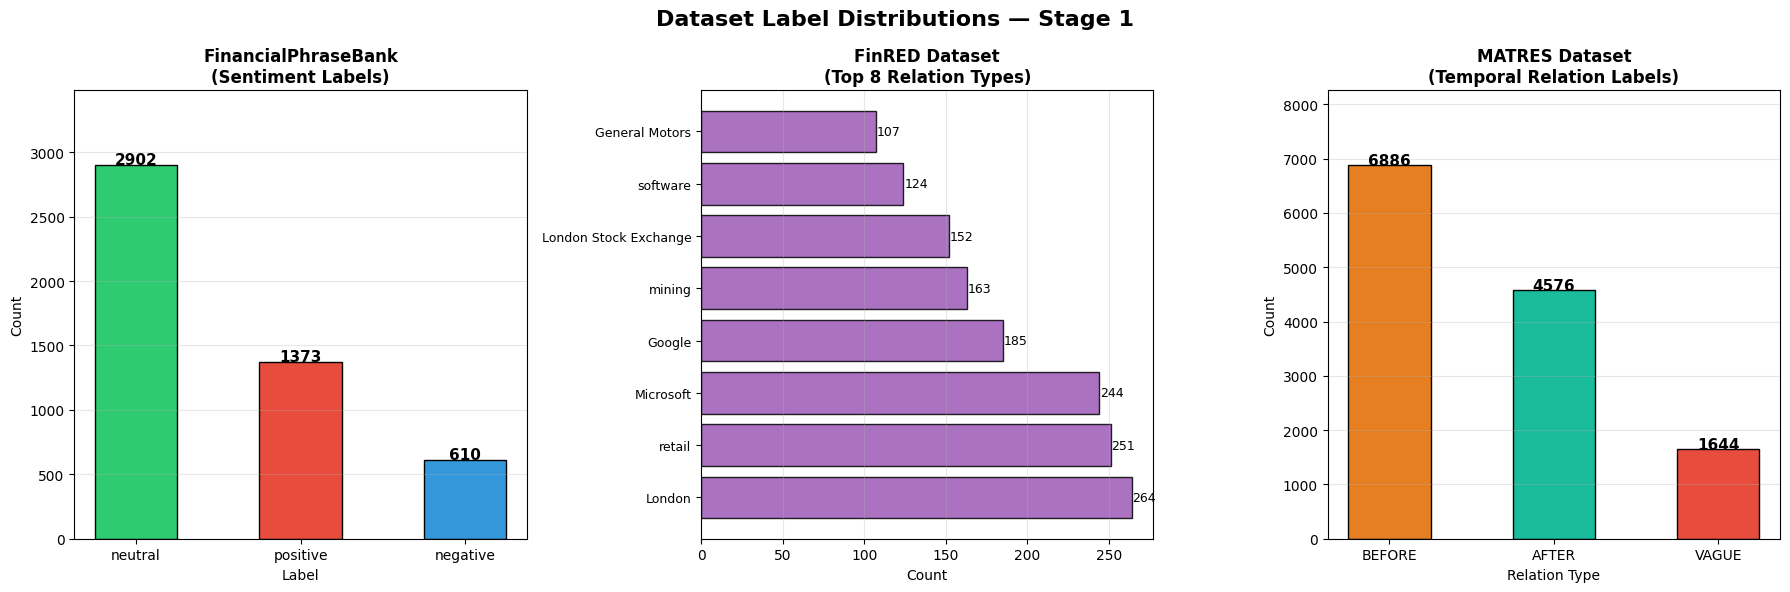

✅ Visualization saved!

📊 Exact counts:

FinancialPhraseBank:
label
neutral     2902
positive    1373
negative     610
Name: count, dtype: int64

MATRES:
relation
BEFORE    6886
AFTER     4576
VAGUE     1644
Name: count, dtype: int64

FinRED unique relation types: 1742


In [ ]:
# ============================================================
# CELL 8 — Dataset Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Dataset Label Distributions — Stage 1',
             fontsize=16, fontweight='bold')

# ── FinancialPhraseBank ──────────────────────────────────────
fpb_counts  = fpb_df['label'].value_counts()
bar_colors  = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[0].bar(fpb_counts.index, fpb_counts.values,
                   color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_title('FinancialPhraseBank\n(Sentiment Labels)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(fpb_counts.values) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# ── FinRED ───────────────────────────────────────────────────
top_rel = finred_df['relation_type'].value_counts().head(8)
bars2   = axes[1].barh(range(len(top_rel)), top_rel.values,
                       color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(len(top_rel)))
axes[1].set_yticklabels(top_rel.index, fontsize=9)
axes[1].set_title('FinRED Dataset\n(Top 8 Relation Types)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Count')
for i, val in enumerate(top_rel.values):
    axes[1].text(val + 0.5, i, str(val), va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

# ── MATRES ───────────────────────────────────────────────────
matres_counts = matres_df['relation'].value_counts()
matres_colors = ['#e67e22', '#1abc9c', '#e74c3c', '#95a5a6']
bars3 = axes[2].bar(matres_counts.index, matres_counts.values,
                    color=matres_colors[:len(matres_counts)],
                    edgecolor='black', width=0.5)
axes[2].set_title('MATRES Dataset\n(Temporal Relation Labels)',
                  fontweight='bold', fontsize=12)
axes[2].set_xlabel('Relation Type')
axes[2].set_ylabel('Count')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold', fontsize=11)
axes[2].set_ylim(0, max(matres_counts.values) * 1.2)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage1_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved!")
print(f"\n📊 Exact counts:")
print(f"\nFinancialPhraseBank:\n{fpb_counts}")
print(f"\nMATRES:\n{matres_counts}")
print(f"\nFinRED unique relation types: {finred_df['relation_type'].nunique()}")

In [ ]:
# ============================================================
# CELL 9 — Stage 1 Complete Summary
# ============================================================

print("=" * 60)
print("✅  STAGE 1 — DATA COLLECTION & PREPARATION COMPLETE")
print("=" * 60)
print(f"""
📁 DATASET 1: FinancialPhraseBank
   File    : Sentences_AllAgree.txt
   Format  : sentence@label
   Rows    : {len(fpb_df):,}
   Labels  : positive / negative / neutral
   Columns : {list(fpb_df.columns)}

📁 DATASET 2: FinRED
   Files   : train/dev/test .sent + .tup
   Format  : sentence | entity1;relation;entity2
   Rows    : {len(finred_df):,}
   Splits  : train={len(finred_train):,} dev={len(finred_dev):,} test={len(finred_test):,}
   Columns : {list(finred_df.columns)}

📁 DATASET 3: MATRES
   Files   : timebank.txt + aquaint.txt + platinum.txt
   Format  : docID\\tevent1\\tevent2\\t...\\tLABEL
   Rows    : {len(matres_df):,}
   Labels  : {list(matres_df['relation'].unique())}
   Columns : {list(matres_df.columns)}

🔜 NEXT → Stage 2: Text Preprocessing & Linguistic Annotation
""")

✅  STAGE 1 — DATA COLLECTION & PREPARATION COMPLETE

📁 DATASET 1: FinancialPhraseBank
   File    : Sentences_AllAgree.txt
   Format  : sentence@label
   Rows    : 4,885
   Labels  : positive / negative / neutral
   Columns : ['sentence', 'label']

📁 DATASET 2: FinRED
   Files   : train/dev/test .sent + .tup
   Format  : sentence | entity1;relation;entity2
   Rows    : 11,121
   Splits  : train=8,079 dev=1,554 test=1,488
   Columns : ['sentence', 'entity1', 'relation_type', 'entity2', 'split']

📁 DATASET 3: MATRES
   Files   : timebank.txt + aquaint.txt + platinum.txt
   Format  : docID\tevent1\tevent2\t...\tLABEL
   Rows    : 13,106
   Labels  : ['BEFORE', 'VAGUE', 'AFTER']
   Columns : ['doc_id', 'event1', 'event2', 'relation', 'source']

🔜 NEXT → Stage 2: Text Preprocessing & Linguistic Annotation



#Stage2

In [ ]:
# ============================================================
# CELL 10 — Stage 2 Dependencies (run if not already installed)
# ============================================================
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import spacy
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

nlp_spacy = spacy.load("en_core_web_sm")

# Disable unused pipes for speed (we only need tagger, parser, ner)
# This makes SpaCy ~2x faster
nlp_spacy = spacy.load("en_core_web_sm",
                        disable=["lemmatizer"] if "lemmatizer"
                        in nlp_spacy.pipe_names else [])

print("✅ Stage 2 ready!")
print(f"   SpaCy version : {spacy.__version__}")
print(f"   Pipeline pipes: {nlp_spacy.pipe_names}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Stage 2 ready!
   SpaCy version : 3.8.14
   Pipeline pipes: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'ner']


In [ ]:
# ============================================================
# CELL 11 — Financial Domain Keywords & Constants
# ============================================================
# These keywords are used to detect financial event triggers
# in sentences during linguistic annotation.
# Covers: M&A, earnings, market moves, rates, restructuring

FINANCIAL_KEYWORDS = [
    # Mergers & Acquisitions
    'merger', 'mergers', 'acquire', 'acquired', 'acquisition',
    'takeover', 'buyout', 'purchase', 'purchased', 'stake',
    'divest', 'divestiture', 'spin', 'spinoff',
    # Earnings & Revenue
    'earn', 'earning', 'earnings', 'revenue', 'revenues',
    'profit', 'profits', 'loss', 'losses', 'income',
    'ebitda', 'margin', 'margins', 'sales', 'turnover',
    # Market Movements
    'rise', 'rose', 'risen', 'fall', 'fell', 'fallen',
    'drop', 'dropped', 'surge', 'surged', 'decline',
    'declined', 'gain', 'gained', 'slip', 'slipped',
    'rally', 'rallied', 'plunge', 'plunged', 'jump',
    'jumped', 'climb', 'climbed', 'crash', 'crashed',
    # Corporate Events
    'announce', 'announced', 'announcement', 'report',
    'reported', 'reporting', 'launch', 'launched',
    'appoint', 'appointed', 'resign', 'resigned',
    'restructure', 'restructured', 'restructuring',
    'layoff', 'layoffs', 'hire', 'hired', 'expand',
    'expanded', 'expansion', 'close', 'closed', 'closure',
    # Financial Instruments
    'ipo', 'dividend', 'dividends', 'bond', 'bonds',
    'share', 'shares', 'stock', 'stocks', 'equity',
    'debt', 'borrow', 'borrowed', 'loan', 'loans',
    'invest', 'invested', 'investment', 'fund', 'funded',
    # Interest Rates & Policy
    'rate', 'rates', 'interest', 'inflation', 'policy',
    'monetary', 'fiscal', 'tariff', 'tariffs', 'tax',
    # Bankruptcy
    'bankrupt', 'bankruptcy', 'default', 'defaulted',
    'insolvent', 'insolvency', 'liquidate', 'liquidation'
]

# Convert to set for O(1) lookup
FINANCIAL_KEYWORDS_SET = set(FINANCIAL_KEYWORDS)

print(f"✅ Financial keyword dictionary loaded!")
print(f"   Total keywords : {len(FINANCIAL_KEYWORDS_SET)}")
print(f"   Categories     : M&A, Earnings, Market Moves,")
print(f"                    Corporate Events, Instruments,")
print(f"                    Rates & Policy, Bankruptcy")

✅ Financial keyword dictionary loaded!
   Total keywords : 118
   Categories     : M&A, Earnings, Market Moves,
                    Corporate Events, Instruments,
                    Rates & Policy, Bankruptcy


In [ ]:
# ============================================================
# CELL 12 — Core Single-Text Preprocessing Function
# ============================================================
# Performs full linguistic annotation on one sentence:
#   1. Tokenization
#   2. Lemmatization
#   3. POS Tagging
#   4. Dependency Parsing
#   5. Named Entity Recognition (NER)
#   6. Financial Event Trigger Detection
#   7. Clean token extraction (no stopwords, no punctuation)

def preprocess_single(text, nlp_model):
    """
    Full linguistic preprocessing on a single text string.

    Parameters:
        text      : raw input string
        nlp_model : loaded SpaCy model

    Returns dict with all linguistic annotations.
    """
    if not text or not isinstance(text, str):
        text = str(text)

    # Clean text before SpaCy processing
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp_model(text)

    # ── 1. Tokenization + POS + Lemmatization ───────────────
    tokens = []
    for token in doc:
        if token.is_space:
            continue
        tokens.append({
            'text'     : token.text,
            'lemma'    : token.lemma_.lower(),
            'pos'      : token.pos_,       # NOUN, VERB, ADJ...
            'tag'      : token.tag_,       # fine-grained POS
            'dep'      : token.dep_,       # syntactic dependency
            'is_stop'  : token.is_stop,
            'is_punct' : token.is_punct,
            'is_alpha' : token.is_alpha
        })

    # ── 2. Named Entity Recognition ─────────────────────────
    # Extracts: companies (ORG), people (PERSON),
    # money (MONEY), dates (DATE), locations (GPE/LOC)
    entities = []
    for ent in doc.ents:
        entities.append({
            'text' : ent.text,
            'label': ent.label_,     # ORG, PERSON, MONEY, DATE...
            'start': ent.start_char,
            'end'  : ent.end_char
        })

    # ── 3. Dependency Parse — Root Verb ─────────────────────
    root_verb = ''
    for token in doc:
        if token.dep_ == 'ROOT':
            root_verb = token.text
            break

    # ── 4. All Verbs (event anchor candidates) ──────────────
    verbs = [t.text for t in doc if t.pos_ == 'VERB']

    # ── 5. Financial Event Trigger Detection ────────────────
    # Match on lemma OR lowercase text against keyword set
    event_triggers = []
    for token in doc:
        word_lower = token.text.lower()
        lemma_lower = token.lemma_.lower()
        if (word_lower  in FINANCIAL_KEYWORDS_SET or
            lemma_lower in FINANCIAL_KEYWORDS_SET):
            if token.text not in event_triggers:
                event_triggers.append(token.text)

    # ── 6. Clean tokens for model input ─────────────────────
    # Remove stopwords, punctuation, keep meaningful words only
    clean_tokens = [
        t['lemma'] for t in tokens
        if not t['is_stop']
        and not t['is_punct']
        and t['is_alpha']
        and len(t['lemma']) > 1
    ]

    # ── 7. Financial entity types ────────────────────────────
    fin_entity_types = ['ORG', 'PERSON', 'MONEY', 'PERCENT',
                        'DATE', 'GPE', 'CARDINAL']
    fin_entities = [e for e in entities
                    if e['label'] in fin_entity_types]

    return {
        'original_text'  : text,
        'tokens'         : tokens,
        'clean_tokens'   : clean_tokens,
        'clean_text'     : ' '.join(clean_tokens),
        'entities'       : entities,
        'fin_entities'   : fin_entities,
        'root_verb'      : root_verb,
        'verbs'          : verbs,
        'event_triggers' : event_triggers,
        'num_tokens'     : len(tokens),
        'num_entities'   : len(entities),
        'num_triggers'   : len(event_triggers),
        'has_fin_event'  : len(event_triggers) > 0
    }

# ── Quick demonstration ──────────────────────────────────────
test_sentences = [
    "Apple Inc. announced a merger with Tesla worth $5 billion.",
    "The Federal Reserve raised interest rates by 0.25% in March.",
    "Lehman Brothers filed for bankruptcy after massive losses.",
    "The company reported record earnings of EUR 2.1 billion.",
    "Goldman Sachs acquired XYZ Corp for $800 million."
]

print("✅ Preprocessing function defined!")
print("\n🔍 Quick Demonstration:")
print("=" * 70)
for sent in test_sentences:
    result = preprocess_single(sent, nlp_spacy)
    print(f"\n📝 Text     : {sent[:65]}")
    print(f"   Entities : {[(e['text'], e['label']) for e in result['fin_entities']]}")
    print(f"   Triggers : {result['event_triggers']}")
    print(f"   Verbs    : {result['verbs']}")
    print(f"   Clean    : {result['clean_text'][:60]}")

✅ Preprocessing function defined!

🔍 Quick Demonstration:

📝 Text     : Apple Inc. announced a merger with Tesla worth $5 billion.
   Entities : [('Apple Inc.', 'ORG'), ('Tesla', 'ORG'), ('$5 billion', 'MONEY')]
   Triggers : ['announced', 'merger']
   Verbs    : ['announced']
   Clean    : 

📝 Text     : The Federal Reserve raised interest rates by 0.25% in March.
   Entities : [('The Federal Reserve', 'ORG'), ('0.25%', 'PERCENT'), ('March', 'DATE')]
   Triggers : ['interest', 'rates']
   Verbs    : ['raised']
   Clean    : 

📝 Text     : Lehman Brothers filed for bankruptcy after massive losses.
   Entities : [('Lehman Brothers', 'ORG')]
   Triggers : ['bankruptcy', 'losses']
   Verbs    : ['filed']
   Clean    : 

📝 Text     : The company reported record earnings of EUR 2.1 billion.
   Entities : [('EUR 2.1 billion', 'MONEY')]
   Triggers : ['reported', 'earnings']
   Verbs    : ['reported']
   Clean    : 

📝 Text     : Goldman Sachs acquired XYZ Corp for $800 million.
   Entities :

In [ ]:
# ============================================================
# CELL 13 — Optimized Batch Preprocessing
# ============================================================
# SpaCy's nlp.pipe() processes texts in batches internally
# which is significantly faster than calling nlp() one by one.
# On large datasets this gives 3-5x speedup.

def preprocess_batch_optimized(texts, nlp_model,
                                batch_size=512, n_process=1):
    """
    Batch preprocessing using SpaCy pipe() for maximum speed.

    Parameters:
        texts      : list of text strings
        nlp_model  : SpaCy model
        batch_size : number of texts per internal SpaCy batch
        n_process  : number of parallel SpaCy workers
                     (set to 1 in Colab to avoid issues)

    Returns list of preprocessed result dicts.
    """
    results = []

    for doc in tqdm(
        nlp_model.pipe(texts, batch_size=batch_size,
                       n_process=n_process),
        total=len(texts),
        desc="🔄 Preprocessing"
    ):
        # Tokens
        tokens = []
        for token in doc:
            if token.is_space:
                continue
            tokens.append({
                'text'    : token.text,
                'lemma'   : token.lemma_.lower(),
                'pos'     : token.pos_,
                'tag'     : token.tag_,
                'dep'     : token.dep_,
                'is_stop' : token.is_stop,
                'is_punct': token.is_punct,
                'is_alpha': token.is_alpha
            })

        # NER
        entities = [
            {'text': ent.text, 'label': ent.label_}
            for ent in doc.ents
        ]

        # Financial entities only
        FIN_ENT_TYPES = {'ORG', 'PERSON', 'MONEY',
                         'PERCENT', 'DATE', 'GPE', 'CARDINAL'}
        fin_entities = [e for e in entities
                        if e['label'] in FIN_ENT_TYPES]

        # Event triggers
        event_triggers = []
        for token in doc:
            if (token.text.lower()  in FINANCIAL_KEYWORDS_SET or
                token.lemma_.lower() in FINANCIAL_KEYWORDS_SET):
                if token.text not in event_triggers:
                    event_triggers.append(token.text)

        # Root verb
        root_verb = next(
            (t.text for t in doc if t.dep_ == 'ROOT'), ''
        )

        # Verbs
        verbs = [t.text for t in doc if t.pos_ == 'VERB']

        # Clean tokens
        clean_tokens = [
            t['lemma'] for t in tokens
            if not t['is_stop']
            and not t['is_punct']
            and t['is_alpha']
            and len(t['lemma']) > 1
        ]

        results.append({
            'original_text' : doc.text,
            'clean_text'    : ' '.join(clean_tokens),
            'entities'      : entities,
            'fin_entities'  : fin_entities,
            'event_triggers': event_triggers,
            'root_verb'     : root_verb,
            'verbs'         : verbs,
            'num_tokens'    : len(tokens),
            'num_entities'  : len(entities),
            'num_triggers'  : len(event_triggers),
            'has_fin_event' : len(event_triggers) > 0
        })

    return results

print("✅ Batch preprocessing function ready!")

✅ Batch preprocessing function ready!


In [ ]:
# ============================================================
# CELL 14 — Preprocess FinancialPhraseBank
# ============================================================

print("🔄 Preprocessing FinancialPhraseBank...")
print(f"   Total sentences : {len(fpb_df):,}")
t0 = time.time()

fpb_preprocessed = preprocess_batch_optimized(
    fpb_df['sentence'].tolist(),
    nlp_spacy,
    batch_size=512
)

elapsed = time.time() - t0
print(f"✅ Done in {elapsed:.1f}s  "
      f"({len(fpb_df)/elapsed:.0f} sentences/sec)")

# Add all annotation columns back to dataframe
fpb_df['clean_text']     = [r['clean_text']     for r in fpb_preprocessed]
fpb_df['entities']       = [r['entities']       for r in fpb_preprocessed]
fpb_df['fin_entities']   = [r['fin_entities']   for r in fpb_preprocessed]
fpb_df['event_triggers'] = [r['event_triggers'] for r in fpb_preprocessed]
fpb_df['verbs']          = [r['verbs']          for r in fpb_preprocessed]
fpb_df['root_verb']      = [r['root_verb']       for r in fpb_preprocessed]
fpb_df['num_tokens']     = [r['num_tokens']     for r in fpb_preprocessed]
fpb_df['num_entities']   = [r['num_entities']   for r in fpb_preprocessed]
fpb_df['num_triggers']   = [r['num_triggers']   for r in fpb_preprocessed]
fpb_df['has_fin_event']  = [r['has_fin_event']  for r in fpb_preprocessed]

print(f"\n📊 FPB Preprocessing Summary:")
print(f"   Sentences with financial events : "
      f"{fpb_df['has_fin_event'].sum():,} / {len(fpb_df):,} "
      f"({fpb_df['has_fin_event'].mean()*100:.1f}%)")
print(f"   Avg tokens per sentence         : "
      f"{fpb_df['num_tokens'].mean():.1f}")
print(f"   Avg entities per sentence       : "
      f"{fpb_df['num_entities'].mean():.2f}")
print(f"   Avg triggers per sentence       : "
      f"{fpb_df['num_triggers'].mean():.2f}")
print(f"\n📋 Sample preprocessed row:")
sample = fpb_df.iloc[5]
print(f"   Sentence  : {sample['sentence'][:70]}")
print(f"   Clean     : {sample['clean_text'][:70]}")
print(f"   Triggers  : {sample['event_triggers']}")
print(f"   Entities  : {sample['fin_entities'][:3]}")

🔄 Preprocessing FinancialPhraseBank...
   Total sentences : 4,885


🔄 Preprocessing: 100%|██████████| 4885/4885 [00:24<00:00, 201.13it/s]

✅ Done in 24.3s  (201 sentences/sec)

📊 FPB Preprocessing Summary:
   Sentences with financial events : 2,054 / 4,885 (42.0%)
   Avg tokens per sentence         : 23.8
   Avg entities per sentence       : 2.99
   Avg triggers per sentence       : 0.62

📋 Sample preprocessed row:
   Sentence  : Finnish Talentum reports its operating profit increased to EUR 20.5 mn
   Clean     : 
   Triggers  : ['profit', 'sales']
   Entities  : [{'text': 'EUR', 'label': 'ORG'}, {'text': '2005', 'label': 'DATE'}, {'text': 'EUR 9.3', 'label': 'ORG'}]


In [ ]:
# ============================================================
# CELL 15 — Preprocess FinRED Dataset
# ============================================================
# FinRED sentences are long news articles — process unique
# sentences only to avoid redundant computation

print("🔄 Preprocessing FinRED sentences...")
print(f"   Total rows          : {len(finred_df):,}")

unique_finred_sents = finred_df['sentence'].unique().tolist()
print(f"   Unique sentences    : {len(unique_finred_sents):,}")

t0 = time.time()
finred_preprocessed = preprocess_batch_optimized(
    unique_finred_sents,
    nlp_spacy,
    batch_size=256
)
elapsed = time.time() - t0
print(f"✅ Done in {elapsed:.1f}s  "
      f"({len(unique_finred_sents)/elapsed:.0f} sentences/sec)")

# Build lookup dictionary by original text
finred_lookup = {
    r['original_text']: r for r in finred_preprocessed
}

# Map preprocessed features back to all rows
finred_df['clean_text'] = finred_df['sentence'].map(
    lambda x: finred_lookup.get(x, {}).get('clean_text', '')
)
finred_df['event_triggers'] = finred_df['sentence'].map(
    lambda x: finred_lookup.get(x, {}).get('event_triggers', [])
)
finred_df['fin_entities'] = finred_df['sentence'].map(
    lambda x: finred_lookup.get(x, {}).get('fin_entities', [])
)
finred_df['num_tokens'] = finred_df['sentence'].map(
    lambda x: finred_lookup.get(x, {}).get('num_tokens', 0)
)
finred_df['has_fin_event'] = finred_df['sentence'].map(
    lambda x: finred_lookup.get(x, {}).get('has_fin_event', False)
)

print(f"\n📊 FinRED Preprocessing Summary:")
print(f"   Rows with financial events : "
      f"{finred_df['has_fin_event'].sum():,} / {len(finred_df):,} "
      f"({finred_df['has_fin_event'].mean()*100:.1f}%)")
print(f"   Avg tokens per sentence    : "
      f"{finred_df['num_tokens'].mean():.1f}")
print(f"\n📋 Sample preprocessed row:")
sample = finred_df.iloc[0]
print(f"   Sentence  : {sample['sentence'][:70]}")
print(f"   Clean     : {sample['clean_text'][:70]}")
print(f"   Triggers  : {sample['event_triggers'][:5]}")
print(f"   Entities  : {sample['fin_entities'][:3]}")

🔄 Preprocessing FinRED sentences...
   Total rows          : 11,121
   Unique sentences    : 7,775


🔄 Preprocessing: 100%|██████████| 7775/7775 [01:02<00:00, 123.58it/s]

✅ Done in 62.9s  (124 sentences/sec)

📊 FinRED Preprocessing Summary:
   Rows with financial events : 5,026 / 11,121 (45.2%)
   Avg tokens per sentence    : 56.0

📋 Sample preprocessed row:
   Sentence  : NEW YORK (Reuters) - Apple Inc Chief Executive Steve Jobs sought to so
   Clean     : 
   Triggers  : ['loss']
   Entities  : [{'text': 'NEW YORK', 'label': 'GPE'}, {'text': 'Reuters', 'label': 'ORG'}, {'text': 'Steve Jobs', 'label': 'PERSON'}]


In [ ]:
# ============================================================
# CELL 16 — Preprocess MATRES Dataset
# ============================================================
# MATRES has event WORDS (not full sentences)
# We preprocess both event1 and event2 columns

print("🔄 Preprocessing MATRES event words...")
print(f"   Total pairs : {len(matres_df):,}")

# Get unique event words from both columns
all_events = list(set(
    matres_df['event1'].tolist() +
    matres_df['event2'].tolist()
))
print(f"   Unique event words : {len(all_events):,}")

t0 = time.time()
event_preprocessed = preprocess_batch_optimized(
    all_events, nlp_spacy, batch_size=512
)
elapsed = time.time() - t0
print(f"✅ Done in {elapsed:.1f}s")

# Build lookup
event_lookup = {
    r['original_text']: r for r in event_preprocessed
}

# Add lemmatized versions of event words
matres_df['event1_lemma'] = matres_df['event1'].map(
    lambda x: event_lookup.get(x, {}).get('clean_text', x)
)
matres_df['event2_lemma'] = matres_df['event2'].map(
    lambda x: event_lookup.get(x, {}).get('clean_text', x)
)
matres_df['event1_pos'] = matres_df['event1'].map(
    lambda x: (event_lookup.get(x, {}).get('tokens') or
               [{'pos': 'UNKNOWN'}])[0].get('pos', 'UNKNOWN')
)
matres_df['event2_pos'] = matres_df['event2'].map(
    lambda x: (event_lookup.get(x, {}).get('tokens') or
               [{'pos': 'UNKNOWN'}])[0].get('pos', 'UNKNOWN')
)

print(f"\n📊 MATRES Preprocessing Summary:")
print(f"   Unique event1 words : {matres_df['event1'].nunique():,}")
print(f"   Unique event2 words : {matres_df['event2'].nunique():,}")
print(f"\n📊 Event POS distribution:")
print(matres_df['event1_pos'].value_counts().head(6))
print(f"\n📋 Sample preprocessed row:")
sample = matres_df.iloc[0]
print(f"   event1        : {sample['event1']}  →  {sample['event1_lemma']}")
print(f"   event2        : {sample['event2']}  →  {sample['event2_lemma']}")
print(f"   relation      : {sample['relation']}")

🔄 Preprocessing MATRES event words...
   Total pairs : 13,106
   Unique event words : 1,558


🔄 Preprocessing: 100%|██████████| 1558/1558 [00:00<00:00, 3212.64it/s]


✅ Done in 0.5s

📊 MATRES Preprocessing Summary:
   Unique event1 words : 1,456
   Unique event2 words : 1,458

📊 Event POS distribution:
event1_pos
UNKNOWN    13106
Name: count, dtype: int64

📋 Sample preprocessed row:
   event1        : predicted  →  
   event2        : tried  →  
   relation      : BEFORE


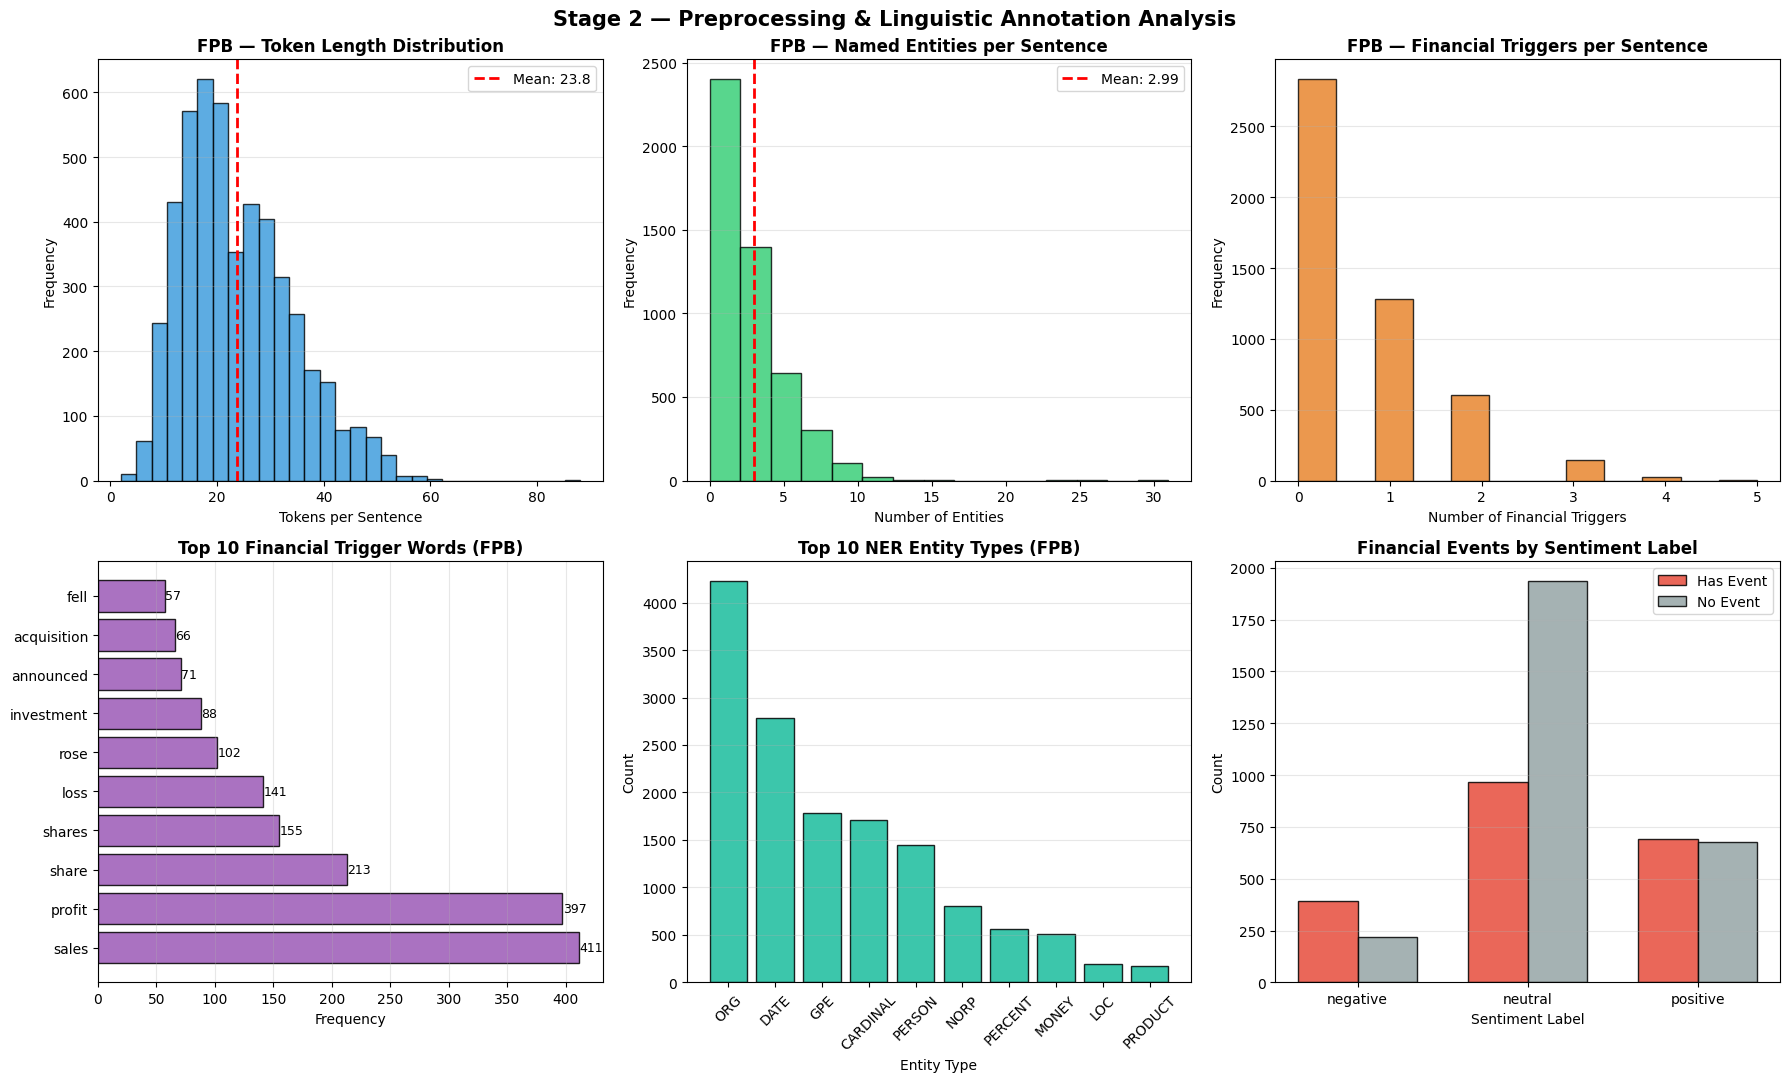

✅ Stage 2 visualization saved!


In [ ]:
# ============================================================
# CELL 17 — Preprocessing Statistics & Visualization
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Stage 2 — Preprocessing & Linguistic Annotation Analysis',
             fontsize=15, fontweight='bold')

# ── Plot 1: FPB Token Length Distribution ───────────────────
axes[0,0].hist(fpb_df['num_tokens'], bins=30,
               color='#3498db', edgecolor='black', alpha=0.8)
axes[0,0].axvline(fpb_df['num_tokens'].mean(), color='red',
                  linestyle='--', linewidth=2,
                  label=f"Mean: {fpb_df['num_tokens'].mean():.1f}")
axes[0,0].set_title('FPB — Token Length Distribution',
                    fontweight='bold')
axes[0,0].set_xlabel('Tokens per Sentence')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# ── Plot 2: FPB Entity Count Distribution ───────────────────
axes[0,1].hist(fpb_df['num_entities'], bins=15,
               color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0,1].axvline(fpb_df['num_entities'].mean(), color='red',
                  linestyle='--', linewidth=2,
                  label=f"Mean: {fpb_df['num_entities'].mean():.2f}")
axes[0,1].set_title('FPB — Named Entities per Sentence',
                    fontweight='bold')
axes[0,1].set_xlabel('Number of Entities')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# ── Plot 3: Event Triggers per Sentence ─────────────────────
axes[0,2].hist(fpb_df['num_triggers'], bins=12,
               color='#e67e22', edgecolor='black', alpha=0.8)
axes[0,2].set_title('FPB — Financial Triggers per Sentence',
                    fontweight='bold')
axes[0,2].set_xlabel('Number of Financial Triggers')
axes[0,2].set_ylabel('Frequency')
axes[0,2].grid(axis='y', alpha=0.3)

# ── Plot 4: Top 10 Most Common Financial Triggers ───────────
all_triggers = [
    t for triggers in fpb_df['event_triggers']
    for t in triggers
]
trigger_counts = Counter(all_triggers).most_common(10)
trig_words  = [t[0] for t in trigger_counts]
trig_values = [t[1] for t in trigger_counts]
axes[1,0].barh(trig_words, trig_values,
               color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Top 10 Financial Trigger Words (FPB)',
                    fontweight='bold')
axes[1,0].set_xlabel('Frequency')
for i, val in enumerate(trig_values):
    axes[1,0].text(val + 0.3, i, str(val),
                   va='center', fontsize=9)
axes[1,0].grid(axis='x', alpha=0.3)

# ── Plot 5: Top 10 NER Types ────────────────────────────────
all_ent_labels = [
    e['label'] for ents in fpb_df['entities']
    for e in ents
]
ent_counts = Counter(all_ent_labels).most_common(10)
ent_types  = [e[0] for e in ent_counts]
ent_values = [e[1] for e in ent_counts]
axes[1,1].bar(ent_types, ent_values,
              color='#1abc9c', edgecolor='black', alpha=0.85)
axes[1,1].set_title('Top 10 NER Entity Types (FPB)',
                    fontweight='bold')
axes[1,1].set_xlabel('Entity Type')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', alpha=0.3)

# ── Plot 6: Events vs Non-Events by Sentiment ───────────────
event_by_label = fpb_df.groupby('label')['has_fin_event'].agg(
    ['sum', 'count']
)
event_by_label['no_event'] = (event_by_label['count']
                               - event_by_label['sum'])
x       = np.arange(len(event_by_label))
width   = 0.35
bars_ev = axes[1,2].bar(x - width/2,
                         event_by_label['sum'],
                         width, label='Has Event',
                         color='#e74c3c', edgecolor='black',
                         alpha=0.85)
bars_no = axes[1,2].bar(x + width/2,
                         event_by_label['no_event'],
                         width, label='No Event',
                         color='#95a5a6', edgecolor='black',
                         alpha=0.85)
axes[1,2].set_title('Financial Events by Sentiment Label',
                    fontweight='bold')
axes[1,2].set_xlabel('Sentiment Label')
axes[1,2].set_ylabel('Count')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(event_by_label.index)
axes[1,2].legend()
axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage2_preprocessing.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Stage 2 visualization saved!")

In [ ]:
# ============================================================
# CELL 18 — Save All Preprocessed DataFrames
# ============================================================

# Convert list columns to strings before saving
def save_df(df, filename):
    df_save = df.copy()
    for col in df_save.columns:
        if df_save[col].dtype == object:
            try:
                if isinstance(df_save[col].iloc[0], (list, dict)):
                    df_save[col] = df_save[col].apply(str)
            except:
                pass
    path = os.path.join(OUTPUT_DIR, filename)
    df_save.to_csv(path, index=False)
    print(f"   💾 {filename:35s} → {len(df_save):,} rows")

print("💾 Saving preprocessed datasets...")
save_df(fpb_df,    'fpb_preprocessed.csv')
save_df(finred_df, 'finred_preprocessed.csv')
save_df(matres_df, 'matres_preprocessed.csv')
print("✅ All datasets saved!")

💾 Saving preprocessed datasets...
   💾 fpb_preprocessed.csv                → 4,885 rows
   💾 finred_preprocessed.csv             → 11,121 rows
   💾 matres_preprocessed.csv             → 13,106 rows
✅ All datasets saved!


In [ ]:
# ============================================================
# CELL 19 — Stage 2 Complete Summary
# ============================================================

print("=" * 60)
print("✅  STAGE 2 — PREPROCESSING COMPLETE")
print("=" * 60)
print(f"""
🔤 PREPROCESSING STEPS APPLIED:
   ✓ Tokenization          (SpaCy)
   ✓ Lemmatization         (SpaCy)
   ✓ POS Tagging           (SpaCy)
   ✓ Dependency Parsing    (SpaCy)
   ✓ Named Entity Recog.   (SpaCy NER)
   ✓ Financial Trigger ID  (Keyword matching on lemmas)
   ✓ Clean token extraction (no stopwords/punctuation)
   ✓ Batch processing      (SpaCy pipe() optimized)

📊 FINPHRASEBANK RESULTS:
   Rows                    : {len(fpb_df):,}
   Avg tokens/sentence     : {fpb_df['num_tokens'].mean():.1f}
   Avg entities/sentence   : {fpb_df['num_entities'].mean():.2f}
   Avg triggers/sentence   : {fpb_df['num_triggers'].mean():.2f}
   Has financial event     : {fpb_df['has_fin_event'].sum():,} / {len(fpb_df):,}

📊 FINRED RESULTS:
   Rows                    : {len(finred_df):,}
   Unique sentences        : {finred_df['sentence'].nunique():,}
   Avg tokens/sentence     : {finred_df['num_tokens'].mean():.1f}
   Has financial event     : {finred_df['has_fin_event'].sum():,} / {len(finred_df):,}

📊 MATRES RESULTS:
   Pairs                   : {len(matres_df):,}
   Unique event words      : {matres_df['event1'].nunique():,}
   Columns added           : event1_lemma, event2_lemma, event1_pos, event2_pos

📁 SAVED FILES:
   fpb_preprocessed.csv
   finred_preprocessed.csv
   matres_preprocessed.csv
   stage2_preprocessing.png

🔜 NEXT → Stage 3: FinBERT Event Detection & Classification
""")

✅  STAGE 2 — PREPROCESSING COMPLETE

🔤 PREPROCESSING STEPS APPLIED:
   ✓ Tokenization          (SpaCy)
   ✓ Lemmatization         (SpaCy)
   ✓ POS Tagging           (SpaCy)
   ✓ Dependency Parsing    (SpaCy)
   ✓ Named Entity Recog.   (SpaCy NER)
   ✓ Financial Trigger ID  (Keyword matching on lemmas)
   ✓ Clean token extraction (no stopwords/punctuation)
   ✓ Batch processing      (SpaCy pipe() optimized)

📊 FINPHRASEBANK RESULTS:
   Rows                    : 4,885
   Avg tokens/sentence     : 23.8
   Avg entities/sentence   : 2.99
   Avg triggers/sentence   : 0.62
   Has financial event     : 2,054 / 4,885

📊 FINRED RESULTS:
   Rows                    : 11,121
   Unique sentences        : 7,775
   Avg tokens/sentence     : 56.0
   Has financial event     : 5,026 / 11,121

📊 MATRES RESULTS:
   Pairs                   : 13,106
   Unique event words      : 1,456
   Columns added           : event1_lemma, event2_lemma, event1_pos, event2_pos

📁 SAVED FILES:
   fpb_preprocessed.csv
   fin

# Stage 3

In [ ]:
# ============================================================
# CELL 20 — Stage 3 Imports & Setup
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import os

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Stage 3 ready!")
print(f"   Device   : {device}")
print(f"   PyTorch  : {torch.__version__}")

OUTPUT_DIR = '/content/financial_nlp_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_NAME = "ProsusAI/finbert"
MAX_LEN    = 128

✅ Stage 3 ready!
   Device   : cuda
   PyTorch  : 2.10.0+cu128


In [ ]:
# ============================================================
# CELL 21 — Prepare Event Detection Dataset (FinancialPhraseBank)
# ============================================================
# Task 1: Financial Event DETECTION
#   → Binary: 1 = financial event exists, 0 = no event
# Task 2: Financial Event CLASSIFICATION
#   → 3-class: positive / neutral / negative
#
# We train ONE model that does both via 3-class classification.
# positive → event with positive impact
# negative → event with negative impact
# neutral  → no significant financial event

# Label maps
SENTIMENT_LABEL_MAP = {
    'negative': 0,
    'neutral' : 1,
    'positive': 2
}
SENTIMENT_ID2LABEL = {v: k for k, v in SENTIMENT_LABEL_MAP.items()}

# Binary event label map (for event detection metrics)
EVENT_LABEL_MAP = {
    'negative': 1,   # IS a financial event
    'positive': 1,   # IS a financial event
    'neutral' : 0    # NOT a significant financial event
}

# Apply labels
fpb_df['sentiment_label'] = fpb_df['label'].map(SENTIMENT_LABEL_MAP)
fpb_df['event_label']     = fpb_df['label'].map(EVENT_LABEL_MAP)

print("✅ Labels created!")
print(f"\n📊 Sentiment label distribution (3-class):")
for label, count in fpb_df['label'].value_counts().items():
    pct = count / len(fpb_df) * 100
    lid = SENTIMENT_LABEL_MAP[label]
    print(f"   [{lid}] {label:10s}: {count:,}  ({pct:.1f}%)")

print(f"\n📊 Binary event label distribution:")
print(f"   [1] Has Event  : {fpb_df['event_label'].sum():,}  "
      f"({fpb_df['event_label'].mean()*100:.1f}%)")
print(f"   [0] No Event   : {(fpb_df['event_label']==0).sum():,}  "
      f"({(fpb_df['event_label']==0).mean()*100:.1f}%)")

# Stratified Train / Val / Test split → 70 / 15 / 15
train_fpb, temp_fpb = train_test_split(
    fpb_df, test_size=0.30, random_state=42,
    stratify=fpb_df['sentiment_label']
)
val_fpb, test_fpb = train_test_split(
    temp_fpb, test_size=0.50, random_state=42,
    stratify=temp_fpb['sentiment_label']
)

print(f"\n📊 Dataset splits (70/15/15):")
print(f"   Train : {len(train_fpb):,}")
print(f"   Val   : {len(val_fpb):,}")
print(f"   Test  : {len(test_fpb):,}")

✅ Labels created!

📊 Sentiment label distribution (3-class):
   [1] neutral   : 2,902  (59.4%)
   [2] positive  : 1,373  (28.1%)
   [0] negative  : 610  (12.5%)

📊 Binary event label distribution:
   [1] Has Event  : 1,983  (40.6%)
   [0] No Event   : 2,902  (59.4%)

📊 Dataset splits (70/15/15):
   Train : 3,419
   Val   : 733
   Test  : 733


In [ ]:
# ============================================================
# CELL 22 — Prepare MATRES Temporal Relation Dataset
# ============================================================
# Task: Temporal Relation Classification
# Labels: BEFORE / AFTER / SIMULTANEOUS / VAGUE
#
# Note from Stage 1: MATRES has 13,106 pairs
# Labels confirmed: BEFORE, VAGUE, AFTER (and SIMULTANEOUS)

# Check exact labels present
print("📊 MATRES exact labels found:")
print(matres_df['relation'].value_counts())

# Label map — handle whatever labels are present
# FIX: Re-map labels to be sequential (0, 1, 2) based on actual data presence
TEMPORAL_LABEL_MAP = {
    'BEFORE'       : 0,
    'AFTER'        : 1,
    # 'SIMULTANEOUS' : 2, # Not present in data, removing to avoid label skip
    'VAGUE'        : 2  # Re-mapped to 2
}
TEMPORAL_ID2LABEL = {v: k for k, v in TEMPORAL_LABEL_MAP.items()}

# Map labels — rows with unmapped labels are dropped
matres_df['label_id'] = matres_df['relation'].map(TEMPORAL_LABEL_MAP)
before_drop = len(matres_df)
matres_df   = matres_df.dropna(subset=['label_id']).reset_index(drop=True)
matres_df['label_id'] = matres_df['label_id'].astype(int)
after_drop = len(matres_df)

print(f"\n📊 After label mapping:")
print(f"   Total pairs     : {after_drop:,}")
print(f"   Dropped (unmapped): {before_drop - after_drop}")
print(f"\n📊 Temporal label distribution:")
for label, count in matres_df['relation'].value_counts().items():
    pct   = count / len(matres_df) * 100
    lid   = TEMPORAL_LABEL_MAP.get(label, '?')
    print(f"   [{lid}] {label:13s}: {count:,}  ({pct:.1f}%)")

# Get actual number of classes present
NUM_TEMPORAL_CLASSES = matres_df['label_id'].nunique()
print(f"\n   Num temporal classes: {NUM_TEMPORAL_CLASSES}")

# Dynamic label names based on what's actually in data
TEMPORAL_LABEL_NAMES = [
    TEMPORAL_ID2LABEL[i]
    for i in sorted(matres_df['label_id'].unique())
]
print(f"   Label names: {TEMPORAL_LABEL_NAMES}")

# Stratified Train / Val / Test split → 70 / 15 / 15
train_mat, temp_mat = train_test_split(
    matres_df, test_size=0.30, random_state=42,
    stratify=matres_df['label_id']
)
val_mat, test_mat = train_test_split(
    temp_mat, test_size=0.50, random_state=42,
    stratify=temp_mat['label_id']
)

print(f"\n📊 MATRES splits (70/15/15):")
print(f"   Train : {len(train_mat):,}")
print(f"   Val   : {len(val_mat):,}")
print(f"   Test  : {len(test_mat):,}")

📊 MATRES exact labels found:
relation
BEFORE    6886
AFTER     4576
VAGUE     1644
Name: count, dtype: int64

📊 After label mapping:
   Total pairs     : 13,106
   Dropped (unmapped): 0

📊 Temporal label distribution:
   [0] BEFORE       : 6,886  (52.5%)
   [1] AFTER        : 4,576  (34.9%)
   [2] VAGUE        : 1,644  (12.5%)

   Num temporal classes: 3
   Label names: ['BEFORE', 'AFTER', 'VAGUE']

📊 MATRES splits (70/15/15):
   Train : 9,174
   Val   : 1,966
   Test  : 1,966


In [ ]:
# ============================================================
# CELL 23 — PyTorch Dataset Classes for Both Tasks
# ============================================================

# Load FinBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer loaded: {MODEL_NAME}")

# ── Dataset 1: Event Detection (single sentence input) ──────
class EventDetectionDataset(Dataset):
    """
    Dataset for financial event detection & classification.
    Input  : single financial sentence
    Output : sentiment label (negative=0 / neutral=1 / positive=2)
    """
    def __init__(self, df, tokenizer, max_len=128):
        self.texts     = df['sentence'].tolist()
        self.labels    = df['sentiment_label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(
                                  self.labels[idx], dtype=torch.long)
        }


# ── Dataset 2: Temporal Relation (event pair input) ─────────
class TemporalRelationDataset(Dataset):
    """
    Dataset for temporal relation classification.
    Input  : event1 [SEP] event2 (sentence-pair encoding)
    Output : BEFORE=0 / AFTER=1 / SIMULTANEOUS=2 / VAGUE=3
    """
    def __init__(self, df, tokenizer, max_len=128):
        self.event1    = df['event1'].tolist()
        self.event2    = df['event2'].tolist()
        self.labels    = df['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.event1)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.event1[idx],
            self.event2[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc.get(
                'token_type_ids',
                torch.zeros(self.max_len, dtype=torch.long)
            ).squeeze(0),
            'labels'        : torch.tensor(
                                  self.labels[idx], dtype=torch.long)
        }


# Build all datasets
train_event_ds = EventDetectionDataset(train_fpb, tokenizer, MAX_LEN)
val_event_ds   = EventDetectionDataset(val_fpb,   tokenizer, MAX_LEN)
test_event_ds  = EventDetectionDataset(test_fpb,  tokenizer, MAX_LEN)

train_temp_ds  = TemporalRelationDataset(train_mat, tokenizer, MAX_LEN)
val_temp_ds    = TemporalRelationDataset(val_mat,   tokenizer, MAX_LEN)
test_temp_ds   = TemporalRelationDataset(test_mat,  tokenizer, MAX_LEN)

print("✅ All datasets created!")
print(f"\n   Event Detection  → Train:{len(train_event_ds):,} "
      f"Val:{len(val_event_ds):,} Test:{len(test_event_ds):,}")
print(f"   Temporal Relation→ Train:{len(train_temp_ds):,}  "
      f"Val:{len(val_temp_ds):,}  Test:{len(test_temp_ds):,}")

# Verify shapes
s = train_event_ds[0]
print(f"\n   Event sample input_ids  : {s['input_ids'].shape}")
s2 = train_temp_ds[0]
print(f"   Temporal sample input_ids: {s2['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer loaded: ProsusAI/finbert
✅ All datasets created!

   Event Detection  → Train:3,419 Val:733 Test:733
   Temporal Relation→ Train:9,174  Val:1,966  Test:1,966

   Event sample input_ids  : torch.Size([128])
   Temporal sample input_ids: torch.Size([128])


In [ ]:
# ============================================================
# CELL 24 — FinBERT-Based Model Architecture
# ============================================================
# Single FinBERT backbone shared for both tasks.
# Task-specific classifier heads on top.
#
# Architecture:
# ┌──────────────────────────────────────────────────┐
# │  Input tokens                                    │
# │       ↓                                          │
# │  FinBERT Encoder (12 layers, 768-dim)            │
# │       ↓                                          │
# │  [CLS] token representation (768-dim)            │
# │       ↓                                          │
# │  Dropout (0.3)                                   │
# │       ↓                                          │
# │  Linear (768 → 256) + ReLU + Dropout             │
# │       ↓                                          │
# │  Linear (256 → 64)  + ReLU                       │
# │       ↓                                          │
# │  Linear (64 → num_classes)                       │
# │       ↓                                          │
# │  Output: class probabilities                     │
# └──────────────────────────────────────────────────┘

class FinBERTClassifier(nn.Module):
    """
    FinBERT-based classifier for both:
      1. Event Detection    (num_classes=3)
      2. Temporal Relation  (num_classes=4)
    Same architecture, different num_classes.
    """
    def __init__(self, model_name, num_classes, dropout=0.3):
        super(FinBERTClassifier, self).__init__()

        self.bert        = AutoModel.from_pretrained(model_name)
        hidden_size      = self.bert.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask,
                token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids
        )
        # [CLS] token = index 0 of last hidden state
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits     = self.classifier(cls_output)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return loss, logits


# ── Initialize both models ───────────────────────────────────
event_model    = FinBERTClassifier(MODEL_NAME, num_classes=3,
                                    dropout=0.3).to(device)
temporal_model = FinBERTClassifier(MODEL_NAME,
                                    num_classes=NUM_TEMPORAL_CLASSES,
                                    dropout=0.3).to(device)

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    return total, trainable

e_total, e_train = count_params(event_model)
t_total, t_train = count_params(temporal_model)

print("✅ Models initialized!")
print(f"\n   Event Detection Model:")
print(f"     Total params     : {e_total:,}")
print(f"     Trainable params : {e_train:,}")
print(f"\n   Temporal Relation Model:")
print(f"     Total params     : {t_total:,}")
print(f"     Trainable params : {t_train:,}")
print(f"     Num classes      : {NUM_TEMPORAL_CLASSES}")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Models initialized!

   Event Detection Model:
     Total params     : 109,695,747
     Trainable params : 109,695,747

   Temporal Relation Model:
     Total params     : 109,695,747
     Trainable params : 109,695,747
     Num classes      : 3


In [ ]:
# ============================================================
# CELL 25 — Training & Evaluation Helper Functions
# ============================================================

def train_one_epoch(model, loader, optimizer,
                    scheduler, device, task_name):
    """Runs one training epoch. Returns avg loss + metrics."""
    model.train()
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []

    for batch in tqdm(loader, desc=f"  Training {task_name}"):
        optimizer.zero_grad()

        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['labels'].to(device)
        tok_types  = batch.get('token_type_ids')
        if tok_types is not None:
            tok_types = tok_types.to(device)

        loss, logits = model(input_ids, attn_mask,
                             tok_types, labels)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds,
                        average='weighted', zero_division=0)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, f1, acc


def evaluate(model, loader, device, task_name):
    """Runs evaluation. Returns loss, metrics, preds, labels."""
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []

    with torch.no_grad():
        for batch in loader:
            input_ids  = batch['input_ids'].to(device)
            attn_mask  = batch['attention_mask'].to(device)
            labels     = batch['labels'].to(device)
            tok_types  = batch.get('token_type_ids')
            if tok_types is not None:
                tok_types = tok_types.to(device)

            loss, logits = model(input_ids, attn_mask,
                                  tok_types, labels)
            total_loss  += loss.item()
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    f1        = f1_score(all_labels, all_preds,
                         average='weighted', zero_division=0)
    acc       = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds,
                                average='weighted',
                                zero_division=0)
    recall    = recall_score(all_labels, all_preds,
                             average='weighted',
                             zero_division=0)
    return avg_loss, f1, acc, precision, recall, \
           all_preds, all_labels


def run_training(model, train_ds, val_ds,
                 batch_size, epochs,
                 lr, task_name, device):
    """
    Full training loop with:
    - AdamW optimizer
    - Linear warmup + cosine decay scheduler
    - Best model saving by validation F1
    """
    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=64,
        shuffle=False, num_workers=2, pin_memory=True
    )

    total_steps   = len(train_loader) * epochs
    warmup_steps  = int(total_steps * 0.1)

    optimizer = AdamW(model.parameters(),
                      lr=lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps    = warmup_steps,
        num_training_steps  = total_steps
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1'  : [], 'val_f1'  : [],
        'train_acc' : [], 'val_acc' : []
    }
    best_f1          = 0.0
    best_model_state = None
    start_time       = time.time()

    print(f"\n🚀 Training: {task_name}")
    print(f"   Epochs       : {epochs}")
    print(f"   Batch size   : {batch_size}")
    print(f"   LR           : {lr}")
    print(f"   Total steps  : {total_steps:,}")
    print(f"   Warmup steps : {warmup_steps:,}")
    print("=" * 55)

    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_f1, train_acc = train_one_epoch(
            model, train_loader, optimizer,
            scheduler, device, task_name
        )
        # Validate
        val_loss, val_f1, val_acc, val_prec, val_rec, _, _ = evaluate(
            model, val_loader, device, task_name
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"  Epoch {epoch}/{epochs} | "
              f"Train Loss:{train_loss:.4f} Acc:{train_acc:.4f} F1:{train_f1:.4f} | "
              f"Val Loss:{val_loss:.4f} Acc:{val_acc:.4f} F1:{val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }
            print(f"    💾 Best model saved (Val F1={best_f1:.4f})")

    elapsed = time.time() - start_time
    print(f"\n✅ Training done: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"   Best Val F1 : {best_f1:.4f}")

    # Restore best weights
    model.load_state_dict(best_model_state)
    return model, history, best_f1, elapsed


print("✅ Training functions defined!")

✅ Training functions defined!


In [ ]:
# ============================================================
# CELL 26 — Train Event Detection Model (FinancialPhraseBank)
# ============================================================

BATCH_SIZE_EVENT = 16
EPOCHS_EVENT     = 5
LR_EVENT         = 2e-5

event_model, event_history, event_best_f1, event_train_time = \
    run_training(
        model      = event_model,
        train_ds   = train_event_ds,
        val_ds     = val_event_ds,
        batch_size = BATCH_SIZE_EVENT,
        epochs     = EPOCHS_EVENT,
        lr         = LR_EVENT,
        task_name  = "Event Detection",
        device     = device
    )

# Save model
torch.save(event_model.state_dict(),
           os.path.join(OUTPUT_DIR, 'event_detection_model.pt'))
print("💾 Event detection model saved!")


🚀 Training: Event Detection
   Epochs       : 5
   Batch size   : 16
   LR           : 2e-05
   Total steps  : 1,070
   Warmup steps : 107



  Training Event Detection: 100%|██████████| 214/214 [01:16<00:00,  2.78it/s]


  Epoch 1/5 | Train Loss:0.7769 Acc:0.7140 F1:0.6882 | Val Loss:0.4156 Acc:0.8840 F1:0.8821
    💾 Best model saved (Val F1=0.8821)


  Training Event Detection: 100%|██████████| 214/214 [01:26<00:00,  2.48it/s]


  Epoch 2/5 | Train Loss:0.3222 Acc:0.9143 F1:0.9141 | Val Loss:0.3491 Acc:0.8786 F1:0.8784


...

  Epoch 3/5 | Train Loss:0.1624 Acc:0.9611 F1:0.9611 | Val Loss:0.3802 Acc:0.8827 F1:0.8821


  Training Event Detection: 100%|██████████| 214/214 [01:25<00:00,  2.49it/s]


  Epoch 4/5 | Train Loss:0.0927 Acc:0.9816 F1:0.9816 | Val Loss:0.4400 Acc:0.8840 F1:0.8840
    💾 Best model saved (Val F1=0.8840)


  Training Event Detection: 100%|██████████| 214/214 [01:25<00:00,  2.50it/s]


  Epoch 5/5 | Train Loss:0.0604 Acc:0.9895 F1:0.9895 | Val Loss:0.4680 Acc:0.8759 F1:0.8762

✅ Training done: 453.5s (7.6 min)
   Best Val F1 : 0.8840
💾 Event detection model saved!


In [ ]:
# ============================================================
# CELL 27 — Train Temporal Relation Model (MATRES)
# ============================================================

BATCH_SIZE_TEMP = 16
EPOCHS_TEMP     = 5
LR_TEMP         = 2e-5

temporal_model, temporal_history, temp_best_f1, temp_train_time = \
    run_training(
        model      = temporal_model,
        train_ds   = train_temp_ds,
        val_ds     = val_temp_ds,
        batch_size = BATCH_SIZE_TEMP,
        epochs     = EPOCHS_TEMP,
        lr         = LR_TEMP,
        task_name  = "Temporal Relation",
        device     = device
    )

# Save model
torch.save(temporal_model.state_dict(),
           os.path.join(OUTPUT_DIR, 'temporal_relation_model.pt'))
print("💾 Temporal relation model saved!")


🚀 Training: Temporal Relation
   Epochs       : 5
   Batch size   : 16
   LR           : 2e-05
   Total steps  : 2,870
   Warmup steps : 287


  Training Temporal Relation: 100%|██████████| 574/574 [03:44<00:00,  2.56it/s]


  Epoch 1/5 | Train Loss:0.8805 Acc:0.6237 F1:0.5720 | Val Loss:0.7826 Acc:0.6882 F1:0.6379
    💾 Best model saved (Val F1=0.6379)


  Training Temporal Relation: 100%|██████████| 574/574 [03:44<00:00,  2.56it/s]


  Epoch 2/5 | Train Loss:0.7345 Acc:0.7182 F1:0.6689 | Val Loss:0.7326 Acc:0.7116 F1:0.6618
    💾 Best model saved (Val F1=0.6618)


...

  Epoch 3/5 | Train Loss:0.6673 Acc:0.7465 F1:0.6959 | Val Loss:0.7389 Acc:0.7182 F1:0.6698
    💾 Best model saved (Val F1=0.6698)


  Training Temporal Relation: 100%|██████████| 574/574 [03:44<00:00,  2.56it/s]


  Epoch 4/5 | Train Loss:0.6110 Acc:0.7692 F1:0.7180 | Val Loss:0.7966 Acc:0.7177 F1:0.6697


  Training Temporal Relation: 100%|██████████| 574/574 [03:44<00:00,  2.56it/s]


  Epoch 5/5 | Train Loss:0.5722 Acc:0.7836 F1:0.7327 | Val Loss:0.7776 Acc:0.7228 F1:0.6783
    💾 Best model saved (Val F1=0.6783)

✅ Training done: 1207.5s (20.1 min)
   Best Val F1 : 0.6783
💾 Temporal relation model saved!


In [ ]:
# ============================================================
# CELL 28 — Full Evaluation: Event Detection
# ============================================================

test_event_loader = DataLoader(
    test_event_ds, batch_size=64, shuffle=False
)

_, test_f1, test_acc, test_prec, test_rec, \
    event_preds, event_true = evaluate(
        event_model, test_event_loader,
        device, "Event Detection"
    )

# Binary event detection metrics
# Convert 3-class → binary (0=neutral, 1=event)
binary_true  = [0 if l == 1 else 1 for l in event_true]
binary_preds = [0 if p == 1 else 1 for p in event_preds]

bin_f1   = f1_score(binary_true, binary_preds,
                    average='binary', zero_division=0)
bin_acc  = accuracy_score(binary_true, binary_preds)
bin_prec = precision_score(binary_true, binary_preds,
                           average='binary', zero_division=0)
bin_rec  = recall_score(binary_true, binary_preds,
                        average='binary', zero_division=0)

sentiment_names = ['negative', 'neutral', 'positive']

print("\n" + "=" * 60)
print("📊 EVENT DETECTION — TEST SET RESULTS")
print("=" * 60)

print("\n── 3-Class Sentiment Classification ──")
print(classification_report(
    event_true, event_preds,
    target_names=sentiment_names,
    digits=4
))

print("\n── Binary Event Detection ──")
print(f"   (positive/negative = Event,  neutral = No Event)")
print(f"   Accuracy  : {bin_acc:.4f}  ({bin_acc*100:.2f}%)")
print(f"   F1 Score  : {bin_f1:.4f}  ({bin_f1*100:.2f}%)")
print(f"   Precision : {bin_prec:.4f}")
print(f"   Recall    : {bin_rec:.4f}")

print("\n── Weighted 3-Class Metrics ──")
print(f"   Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   F1 Score  : {test_f1:.4f}  ({test_f1*100:.2f}%)")
print(f"   Precision : {test_prec:.4f}")
print(f"   Recall    : {test_rec:.4f}")


📊 EVENT DETECTION — TEST SET RESULTS

── 3-Class Sentiment Classification ──
              precision    recall  f1-score   support

    negative     0.9000    0.8804    0.8901        92
     neutral     0.8959    0.9103    0.9031       435
    positive     0.8308    0.8107    0.8206       206

    accuracy                         0.8786       733
   macro avg     0.8756    0.8672    0.8713       733
weighted avg     0.8781    0.8786    0.8783       733


── Binary Event Detection ──
   (positive/negative = Event,  neutral = No Event)
   Accuracy  : 0.8840  (88.40%)
   F1 Score  : 0.8557  (85.57%)
   Precision : 0.8660
   Recall    : 0.8456

── Weighted 3-Class Metrics ──
   Accuracy  : 0.8786  (87.86%)
   F1 Score  : 0.8783  (87.83%)
   Precision : 0.8781
   Recall    : 0.8786


In [ ]:
# ============================================================
# CELL 29 — Full Evaluation: Temporal Relation
# ============================================================

test_temp_loader = DataLoader(
    test_temp_ds, batch_size=64, shuffle=False
)

_, temp_f1, temp_acc, temp_prec, temp_rec, \
    temp_preds, temp_true = evaluate(
        temporal_model, test_temp_loader,
        device, "Temporal Relation"
    )

print("\n" + "=" * 60)
print("📊 TEMPORAL RELATION — TEST SET RESULTS")
print("=" * 60)

print("\n── Per-Class Results ──")
print(classification_report(
    temp_true, temp_preds,
    target_names=TEMPORAL_LABEL_NAMES,
    digits=4
))

print("\n── Overall Weighted Metrics ──")
print(f"   Accuracy  : {temp_acc:.4f}  ({temp_acc*100:.2f}%)")
print(f"   F1 Score  : {temp_f1:.4f}  ({temp_f1*100:.2f}%)")
print(f"   Precision : {temp_prec:.4f}")
print(f"   Recall    : {temp_rec:.4f}")

# Per-class breakdown
print("\n── Per-Class F1 Scores ──")
per_class_f1 = f1_score(
    temp_true, temp_preds,
    average=None, zero_division=0
)
for i, (label, f1_val) in enumerate(
    zip(TEMPORAL_LABEL_NAMES, per_class_f1)
):
    count = temp_true.count(i)
    print(f"   {label:13s}: F1={f1_val:.4f}  "
          f"(support={count})")


📊 TEMPORAL RELATION — TEST SET RESULTS

── Per-Class Results ──
              precision    recall  f1-score   support

      BEFORE     0.7289    0.8461    0.7832      1033
       AFTER     0.6813    0.7467    0.7125       687
       VAGUE     0.2857    0.0163    0.0308       246

    accuracy                         0.7075      1966
   macro avg     0.5653    0.5364    0.5088      1966
weighted avg     0.6568    0.7075    0.6643      1966


── Overall Weighted Metrics ──
   Accuracy  : 0.7075  (70.75%)
   F1 Score  : 0.6643  (66.43%)
   Precision : 0.6568
   Recall    : 0.7075

── Per-Class F1 Scores ──
   BEFORE       : F1=0.7832  (support=1033)
   AFTER        : F1=0.7125  (support=687)
   VAGUE        : F1=0.0308  (support=246)


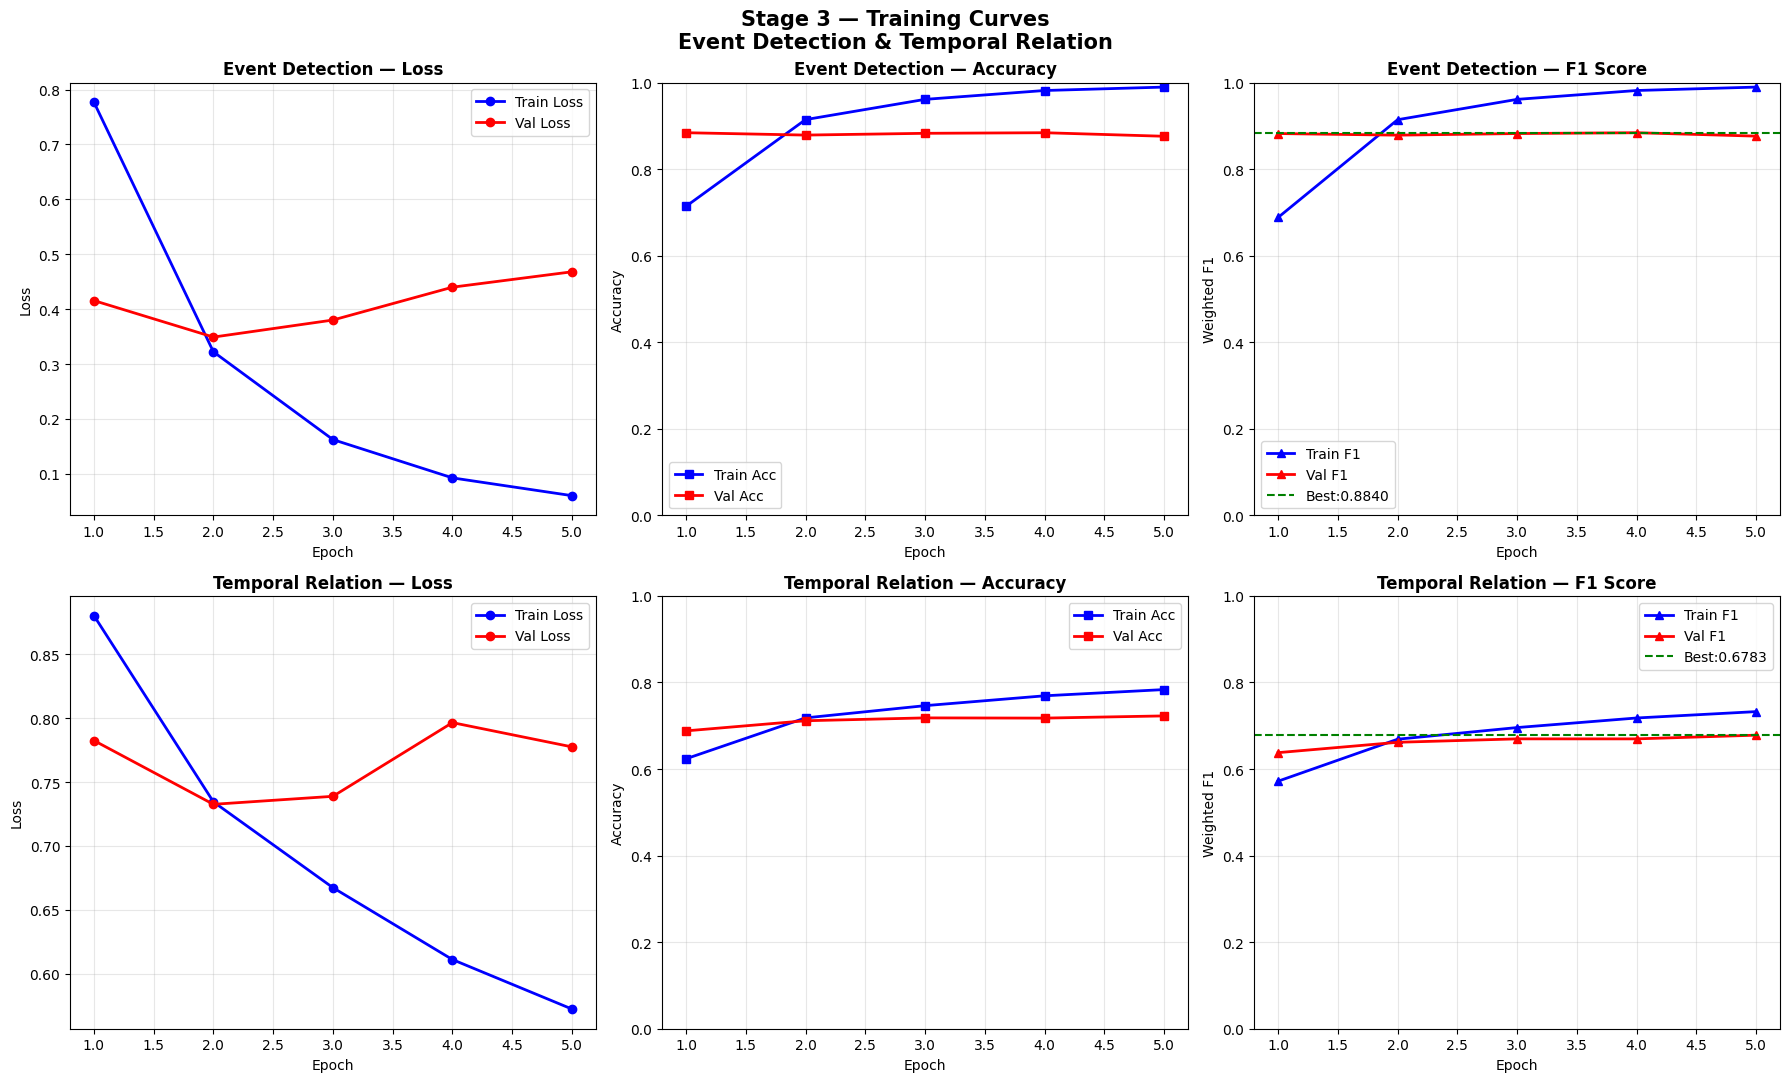

✅ Training curves saved!


In [ ]:
# ============================================================
# CELL 30 — Training Curves for Both Models
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Stage 3 — Training Curves\n'
             'Event Detection & Temporal Relation',
             fontsize=15, fontweight='bold')

epochs_e = range(1, EPOCHS_EVENT + 1)
epochs_t = range(1, EPOCHS_TEMP  + 1)

# ── Row 1: Event Detection ────────────────────────────────
# Loss
axes[0,0].plot(epochs_e, event_history['train_loss'],
               'b-o', lw=2, label='Train Loss')
axes[0,0].plot(epochs_e, event_history['val_loss'],
               'r-o', lw=2, label='Val Loss')
axes[0,0].set_title('Event Detection — Loss',
                    fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Accuracy
axes[0,1].plot(epochs_e, event_history['train_acc'],
               'b-s', lw=2, label='Train Acc')
axes[0,1].plot(epochs_e, event_history['val_acc'],
               'r-s', lw=2, label='Val Acc')
axes[0,1].set_title('Event Detection — Accuracy',
                    fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_ylim(0, 1)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# F1
axes[0,2].plot(epochs_e, event_history['train_f1'],
               'b-^', lw=2, label='Train F1')
axes[0,2].plot(epochs_e, event_history['val_f1'],
               'r-^', lw=2, label='Val F1')
axes[0,2].set_title('Event Detection — F1 Score',
                    fontweight='bold')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Weighted F1')
axes[0,2].set_ylim(0, 1)
axes[0,2].axhline(event_best_f1, color='green',
                  linestyle='--',
                  label=f'Best:{event_best_f1:.4f}')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# ── Row 2: Temporal Relation ──────────────────────────────
# Loss
axes[1,0].plot(epochs_t, temporal_history['train_loss'],
               'b-o', lw=2, label='Train Loss')
axes[1,0].plot(epochs_t, temporal_history['val_loss'],
               'r-o', lw=2, label='Val Loss')
axes[1,0].set_title('Temporal Relation — Loss',
                    fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Accuracy
axes[1,1].plot(epochs_t, temporal_history['train_acc'],
               'b-s', lw=2, label='Train Acc')
axes[1,1].plot(epochs_t, temporal_history['val_acc'],
               'r-s', lw=2, label='Val Acc')
axes[1,1].set_title('Temporal Relation — Accuracy',
                    fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_ylim(0, 1)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# F1
axes[1,2].plot(epochs_t, temporal_history['train_f1'],
               'b-^', lw=2, label='Train F1')
axes[1,2].plot(epochs_t, temporal_history['val_f1'],
               'r-^', lw=2, label='Val F1')
axes[1,2].set_title('Temporal Relation — F1 Score',
                    fontweight='bold')
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_ylabel('Weighted F1')
axes[1,2].set_ylim(0, 1)
axes[1,2].axhline(temp_best_f1, color='green',
                  linestyle='--',
                  label=f'Best:{temp_best_f1:.4f}')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage3_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

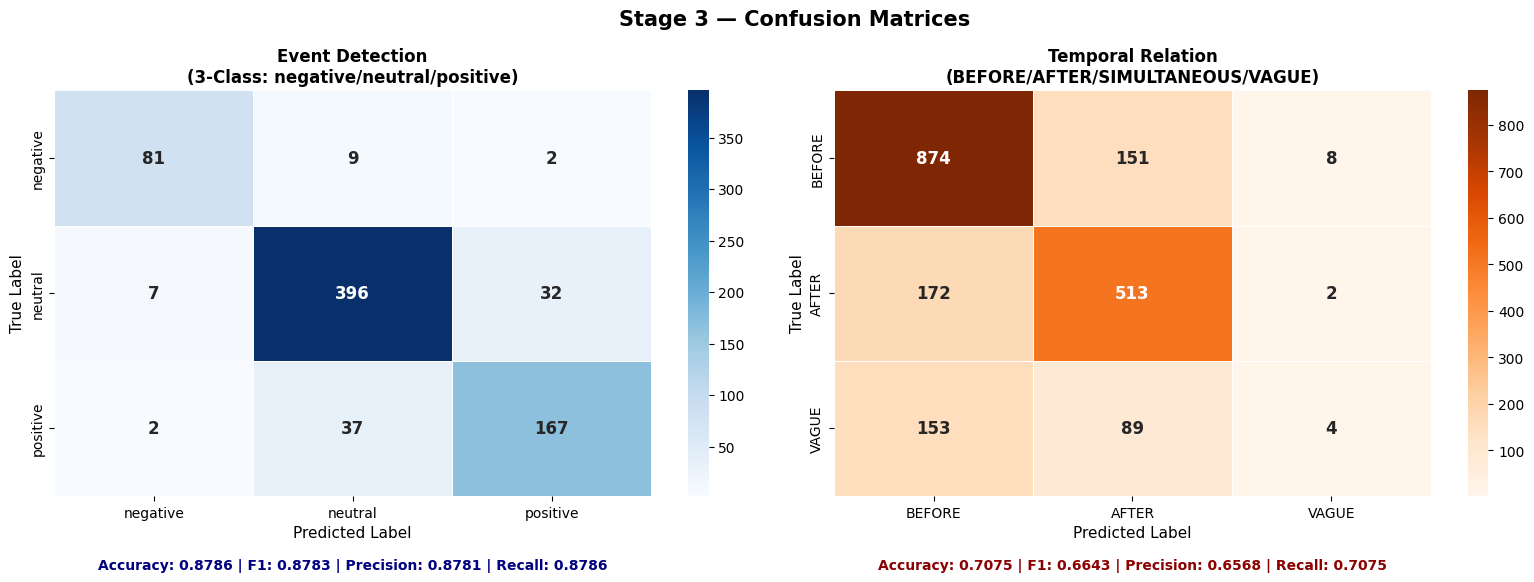

✅ Confusion matrices saved!


In [ ]:
# ============================================================
# CELL 31 — Confusion Matrices: Event + Temporal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stage 3 — Confusion Matrices',
             fontsize=15, fontweight='bold')

# ── Event Detection Confusion Matrix ────────────────────────
cm_event = confusion_matrix(event_true, event_preds)
sns.heatmap(
    cm_event, annot=True, fmt='d', cmap='Blues',
    xticklabels=sentiment_names,
    yticklabels=sentiment_names,
    linewidths=0.5, ax=axes[0],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0].set_title('Event Detection\n(3-Class: negative/neutral/positive)',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Add accuracy text
axes[0].text(0.5, -0.18,
             f'Accuracy: {test_acc:.4f} | '
             f'F1: {test_f1:.4f} | '
             f'Precision: {test_prec:.4f} | '
             f'Recall: {test_rec:.4f}',
             ha='center', transform=axes[0].transAxes,
             fontsize=10, color='navy', fontweight='bold')

# ── Temporal Relation Confusion Matrix ──────────────────────
cm_temporal = confusion_matrix(temp_true, temp_preds)
sns.heatmap(
    cm_temporal, annot=True, fmt='d', cmap='Oranges',
    xticklabels=TEMPORAL_LABEL_NAMES,
    yticklabels=TEMPORAL_LABEL_NAMES,
    linewidths=0.5, ax=axes[1],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[1].set_title('Temporal Relation\n(BEFORE/AFTER/SIMULTANEOUS/VAGUE)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

axes[1].text(0.5, -0.18,
             f'Accuracy: {temp_acc:.4f} | '
             f'F1: {temp_f1:.4f} | '
             f'Precision: {temp_prec:.4f} | '
             f'Recall: {temp_rec:.4f}',
             ha='center', transform=axes[1].transAxes,
             fontsize=10, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage3_confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

In [ ]:
# ============================================================
# CELL 32 — Save Metrics & Models
# ============================================================

all_metrics = {
    'stage': 'Stage 3 - FinBERT Event Detection + Temporal Relation',

    'event_detection': {
        'model'          : MODEL_NAME,
        'dataset'        : 'FinancialPhraseBank AllAgree',
        'train_samples'  : len(train_event_ds),
        'test_samples'   : len(test_event_ds),
        'epochs'         : EPOCHS_EVENT,
        'batch_size'     : BATCH_SIZE_EVENT,
        'learning_rate'  : LR_EVENT,
        'train_time_sec' : round(event_train_time, 2),
        '3class_accuracy': round(test_acc, 4),
        '3class_f1'      : round(test_f1, 4),
        '3class_precision': round(test_prec, 4),
        '3class_recall'  : round(test_rec, 4),
        'binary_accuracy': round(bin_acc, 4),
        'binary_f1'      : round(bin_f1, 4),
        'binary_precision': round(bin_prec, 4),
        'binary_recall'  : round(bin_rec, 4)
    },

    'temporal_relation': {
        'model'          : MODEL_NAME,
        'dataset'        : 'MATRES (timebank+aquaint+platinum)',
        'train_samples'  : len(train_temp_ds),
        'test_samples'   : len(test_temp_ds),
        'epochs'         : EPOCHS_TEMP,
        'batch_size'     : BATCH_SIZE_TEMP,
        'learning_rate'  : LR_TEMP,
        'train_time_sec' : round(temp_train_time, 2),
        'accuracy'       : round(temp_acc, 4),
        'f1_weighted'    : round(temp_f1, 4),
        'precision'      : round(temp_prec, 4),
        'recall'         : round(temp_rec, 4),
        'labels'         : TEMPORAL_LABEL_NAMES,
        'per_class_f1'   : {
            label: round(float(f1_score(
                temp_true, temp_preds,
                labels=[i], average='micro',
                zero_division=0
            )), 4)
            for i, label in enumerate(TEMPORAL_LABEL_NAMES)
        }
    }
}

metrics_path = os.path.join(OUTPUT_DIR, 'stage3_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=4)
print(f"💾 Metrics saved → stage3_metrics.json")

print(f"\n✅ OUTPUT FILES:")
print(f"   event_detection_model.pt")
print(f"   temporal_relation_model.pt")
print(f"   stage3_training_curves.png")
print(f"   stage3_confusion_matrices.png")
print(f"   stage3_metrics.json")

💾 Metrics saved → stage3_metrics.json

✅ OUTPUT FILES:
   event_detection_model.pt
   temporal_relation_model.pt
   stage3_training_curves.png
   stage3_confusion_matrices.png
   stage3_metrics.json


In [ ]:
# ============================================================
# CELL 33 — Stage 3 Complete Summary
# ============================================================

print("=" * 65)
print("✅  STAGE 3 — COMPLETE SUMMARY")
print("=" * 65)
print(f"""
🤖 MODEL: FinBERT (ProsusAI/finbert)
   Architecture : BERT → [CLS] → Dropout → 768→256→64→N

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 TASK 1: FINANCIAL EVENT DETECTION
   Dataset    : FinancialPhraseBank (AllAgree)
   Samples    : Train={len(train_event_ds):,} | Val={len(val_event_ds):,} | Test={len(test_event_ds):,}
   Epochs     : {EPOCHS_EVENT}  |  LR: {LR_EVENT}
   Train time : {event_train_time/60:.1f} min

   ── 3-Class (negative/neutral/positive) ──
   Accuracy   : {test_acc:.4f}  ({test_acc*100:.2f}%)
   F1 Score   : {test_f1:.4f}
   Precision  : {test_prec:.4f}
   Recall     : {test_rec:.4f}

   ── Binary (Event vs No-Event) ──
   Accuracy   : {bin_acc:.4f}  ({bin_acc*100:.2f}%)
   F1 Score   : {bin_f1:.4f}
   Precision  : {bin_prec:.4f}
   Recall     : {bin_rec:.4f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏱️  TASK 2: TEMPORAL RELATION CLASSIFICATION
   Dataset    : MATRES (timebank+aquaint+platinum)
   Samples    : Train={len(train_temp_ds):,} | Val={len(val_temp_ds):,} | Test={len(test_temp_ds):,}
   Labels     : {TEMPORAL_LABEL_NAMES}
   Epochs     : {EPOCHS_TEMP}  |  LR: {LR_TEMP}
   Train time : {temp_train_time/60:.1f} min

   Accuracy   : {temp_acc:.4f}  ({temp_acc*100:.2f}%)
   F1 Score   : {temp_f1:.4f}
   Precision  : {temp_prec:.4f}
   Recall     : {temp_rec:.4f}

🔜 NEXT → Stage 4: Cross-Sentence Event Linking
          Stage 5: Temporal Relation (end-to-end)
          Stage 6: Parallel Pipeline (PDC)
""")

✅  STAGE 3 — COMPLETE SUMMARY

🤖 MODEL: FinBERT (ProsusAI/finbert)
   Architecture : BERT → [CLS] → Dropout → 768→256→64→N

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 TASK 1: FINANCIAL EVENT DETECTION
   Dataset    : FinancialPhraseBank (AllAgree)
   Samples    : Train=3,419 | Val=733 | Test=733
   Epochs     : 5  |  LR: 2e-05
   Train time : 7.6 min

   ── 3-Class (negative/neutral/positive) ──
   Accuracy   : 0.8786  (87.86%)
   F1 Score   : 0.8783
   Precision  : 0.8781
   Recall     : 0.8786

   ── Binary (Event vs No-Event) ──
   Accuracy   : 0.8840  (88.40%)
   F1 Score   : 0.8557
   Precision  : 0.8660
   Recall     : 0.8456

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏱️  TASK 2: TEMPORAL RELATION CLASSIFICATION
   Dataset    : MATRES (timebank+aquaint+platinum)
   Samples    : Train=9,174 | Val=1,966 | Test=1,966
   Labels     : ['BEFORE', 'AFTER', 'VAGUE']
   Epochs     : 5  |  LR: 2e-05
   Train time : 20.1 min

   Accuracy   : 0.7075  (70.75%)
   F1 Score

#Stage 4

In [ ]:
# ============================================================
# CELL 34 — Stage 4 & 5 Imports & Setup
# ============================================================

import os
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
    precision_score, recall_score
)
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = '/content/financial_nlp_output'
MODEL_NAME = "ProsusAI/finbert"
MAX_LEN    = 128

# Confirm models are loaded
try:
    _ = next(event_model.parameters()).device
    print("✅ event_model    : in memory")
except:
    print("⚠️  event_model not found — please run Stage 3 first")

try:
    _ = next(temporal_model.parameters()).device
    print("✅ temporal_model : in memory")
except:
    print("⚠️  temporal_model not found — please run Stage 3 first")

# Confirm label maps from Stage 3
print(f"\n✅ TEMPORAL_LABEL_NAMES : {TEMPORAL_LABEL_NAMES}")
print(f"✅ TEMPORAL_ID2LABEL    : {TEMPORAL_ID2LABEL}")
print(f"\n✅ Stage 4 & 5 setup complete!")
print(f"   Device : {device}")

✅ event_model    : in memory
✅ temporal_model : in memory

✅ TEMPORAL_LABEL_NAMES : ['BEFORE', 'AFTER', 'VAGUE']
✅ TEMPORAL_ID2LABEL    : {0: 'BEFORE', 1: 'AFTER', 2: 'VAGUE'}

✅ Stage 4 & 5 setup complete!
   Device : cuda


In [ ]:
# ============================================================
# CELL 35 — Extract FinBERT Sentence Embeddings
# ============================================================
# We use the FinBERT encoder backbone to get
# semantic vector representations of sentences.
# The [CLS] token (index 0) represents the
# overall meaning of the entire sentence.
# These 768-dimensional vectors are then used
# to compute cosine similarity between sentences
# to find semantically related event sentences.

def get_sentence_embeddings(texts, model, tokenizer,
                             device, batch_size=64):
    """
    Extracts [CLS] embeddings from FinBERT encoder.

    Parameters:
        texts      : list of sentences
        model      : FinBERTClassifier (has .bert attribute)
        tokenizer  : FinBERT tokenizer
        device     : cuda or cpu
        batch_size : number of sentences per batch

    Returns:
        numpy array of shape (num_texts, 768)
    """
    model.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size),
                  desc="🔄 Extracting embeddings"):
        batch = texts[i: i + batch_size]
        enc   = tokenizer(
            batch,
            max_length     = MAX_LEN,
            padding        = True,
            truncation     = True,
            return_tensors = 'pt'
        ).to(device)

        with torch.no_grad():
            # Use the BERT backbone directly
            outputs = model.bert(
                input_ids      = enc['input_ids'],
                attention_mask = enc['attention_mask']
            )
            # [CLS] = first token of last hidden state
            cls_emb = outputs.last_hidden_state[:, 0, :]

        all_embeddings.append(cls_emb.cpu().numpy())

    return np.vstack(all_embeddings)


# Use FinRED unique sentences for event linking
# (FinRED has real financial news — best for linking)
unique_sents = finred_df['sentence'].unique().tolist()
print(f"📊 Total unique FinRED sentences : {len(unique_sents):,}")

# Use first 3000 for Stage 4
# (representative sample — covers all relation types)
stage4_sents = unique_sents[:3000]
print(f"📊 Using for Stage 4             : {len(stage4_sents):,}")

print(f"\n🔄 Extracting FinBERT embeddings...")
t0 = time.time()

embeddings = get_sentence_embeddings(
    stage4_sents, event_model, tokenizer, device,
    batch_size=64
)

elapsed = time.time() - t0
print(f"\n✅ Embeddings extracted!")
print(f"   Shape   : {embeddings.shape}")
print(f"   Dim     : {embeddings.shape[1]} (FinBERT hidden size)")
print(f"   Time    : {elapsed:.1f}s")
print(f"   Speed   : {len(stage4_sents)/elapsed:.0f} sentences/sec")

📊 Total unique FinRED sentences : 7,775
📊 Using for Stage 4             : 3,000

🔄 Extracting FinBERT embeddings...


🔄 Extracting embeddings: 100%|██████████| 47/47 [00:27<00:00,  1.73it/s]


✅ Embeddings extracted!
   Shape   : (3000, 768)
   Dim     : 768 (FinBERT hidden size)
   Time    : 27.2s
   Speed   : 110 sentences/sec


In [ ]:
# ============================================================
# CELL 36 — Sliding Window Cross-Sentence Event Linking
# ============================================================
# Strategy (from your methodology):
#   1. Use a sliding window of 2-3 consecutive sentences
#   2. Compute cosine similarity between FinBERT embeddings
#   3. Only link pairs ABOVE similarity threshold
#   4. Filter further by entity overlap
#
# Why sliding window?
#   Financial stories unfold across multiple sentences.
#   A merger announcement in sentence 1 is linked to
#   a stock price rise in sentence 3. We capture this
#   by looking at nearby sentences together.

def compute_entity_overlap(sent1, sent2):
    """
    Checks if two sentences share common financial entities.
    Uses simple word overlap on capitalized words (entity proxies).
    Returns overlap ratio 0.0 to 1.0
    """
    def get_cap_words(text):
        words = re.findall(r'\b[A-Z][a-zA-Z]+\b', text)
        return set(words)

    caps1 = get_cap_words(sent1)
    caps2 = get_cap_words(sent2)

    if not caps1 or not caps2:
        return 0.0

    overlap = caps1.intersection(caps2)
    union   = caps1.union(caps2)
    return len(overlap) / len(union) if union else 0.0


def sliding_window_event_linking(sentences, embeddings,
                                  window_size=3,
                                  sim_threshold=0.70,
                                  entity_threshold=0.0):
    """
    Links semantically related financial event sentences
    using sliding window + cosine similarity + entity overlap.

    Parameters:
        sentences        : list of sentence strings
        embeddings       : numpy array (N, 768) from FinBERT
        window_size      : how many sentences ahead to look
        sim_threshold    : minimum cosine similarity to link
        entity_threshold : minimum entity overlap to keep pair

    Returns:
        DataFrame of linked event pairs with scores
    """
    linked_pairs = []
    n = len(sentences)

    emb_tensor = torch.tensor(embeddings, dtype=torch.float32)

    for i in tqdm(range(n),
                  desc="🔗 Sliding window linking"):
        # Look ahead within window
        for j in range(i + 1,
                       min(i + window_size + 1, n)):

            # Cosine similarity between embeddings
            sim = cosine_similarity(
                emb_tensor[i].unsqueeze(0),
                emb_tensor[j].unsqueeze(0)
            ).item()

            if sim < sim_threshold:
                continue

            # Entity overlap filter
            ent_overlap = compute_entity_overlap(
                sentences[i], sentences[j]
            )

            if ent_overlap < entity_threshold:
                continue

            # Combined relevance score
            relevance_score = (sim * 0.7) + (ent_overlap * 0.3)

            linked_pairs.append({
                'sent_idx_1'     : i,
                'sent_idx_2'     : j,
                'sentence_1'     : sentences[i],
                'sentence_2'     : sentences[j],
                'cosine_sim'     : round(sim, 4),
                'entity_overlap' : round(ent_overlap, 4),
                'relevance_score': round(relevance_score, 4),
                'window_gap'     : j - i
            })

    return pd.DataFrame(linked_pairs)


print("🔗 Running sliding window event linking...")
print(f"   Window size      : 3 sentences")
print(f"   Sim threshold    : 0.70")
print(f"   Entity threshold : 0.0 (no entity filter)")
print(f"   Sentences        : {len(stage4_sents):,}")

t0 = time.time()
linked_df = sliding_window_event_linking(
    stage4_sents,
    embeddings,
    window_size      = 3,
    sim_threshold    = 0.70,
    entity_threshold = 0.0
)
elapsed = time.time() - t0

print(f"\n✅ Event linking complete!")
print(f"   Time             : {elapsed:.1f}s")
print(f"   Linked pairs     : {len(linked_df):,}")
if len(linked_df) > 0:
    print(f"   Avg cosine sim   : {linked_df['cosine_sim'].mean():.4f}")
    print(f"   Avg entity ovlp  : {linked_df['entity_overlap'].mean():.4f}")
    print(f"   Avg relevance    : {linked_df['relevance_score'].mean():.4f}")
    print(f"\n📋 Sample linked pairs:")
    print(linked_df[['sentence_1','sentence_2',
                     'cosine_sim','window_gap'
                    ]].head(3).to_string())

🔗 Running sliding window event linking...
   Window size      : 3 sentences
   Sim threshold    : 0.70
   Entity threshold : 0.0 (no entity filter)
   Sentences        : 3,000


🔗 Sliding window linking: 100%|██████████| 3000/3000 [00:00<00:00, 3109.24it/s]


✅ Event linking complete!
   Time             : 1.0s
   Linked pairs     : 3,817
   Avg cosine sim   : 0.9069
   Avg entity ovlp  : 0.0444
   Avg relevance    : 0.6482

📋 Sample linked pairs:
                                                                                                                                                                  sentence_1                                                                                                                                                                                                                         sentence_2  cosine_sim  window_gap
0  Last week, Citigroup Inc's ( C.N ) Chief Executive Vikram Pandit said that he, Chairman Win Bischoff, and senior adviser Robert Rubin would not receive bonuses for 2008.                                                             Lehman Brothers LEH.N shares fell sharply on Monday on speculation that the investment bank could be bought for $15 a share, a price well below curren

In [ ]:
# ============================================================
# CELL 37 — Detect Financial Events in Linked Pairs
# ============================================================
# For each linked sentence pair, we run the trained
# event detection model to:
#   1. Confirm both sentences contain financial events
#   2. Get confidence scores for each sentence
#   3. Filter out pairs where neither sentence has an event
# This ensures Stage 5 only processes real event pairs.

def detect_events_batch(texts, model, tokenizer,
                         device, batch_size=64):
    """
    Runs event detection on a list of texts.
    Returns labels and confidence scores.
    """
    model.eval()
    id2label  = {0: 'negative', 1: 'neutral', 2: 'positive'}
    labels_out = []
    confs_out  = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        enc   = tokenizer(
            batch,
            max_length     = MAX_LEN,
            padding        = True,
            truncation     = True,
            return_tensors = 'pt'
        ).to(device)

        with torch.no_grad():
            _, logits = event_model(
                enc['input_ids'],
                enc['attention_mask']
            )
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

        for pred, prob in zip(preds.cpu(), probs.cpu()):
            labels_out.append(id2label[pred.item()])
            confs_out.append(round(prob[pred].item(), 4))

    return labels_out, confs_out


if len(linked_df) > 0:
    print("🔍 Running event detection on linked pairs...")

    # Detect events in sentence 1
    s1_labels, s1_confs = detect_events_batch(
        linked_df['sentence_1'].tolist(),
        event_model, tokenizer, device
    )
    # Detect events in sentence 2
    s2_labels, s2_confs = detect_events_batch(
        linked_df['sentence_2'].tolist(),
        event_model, tokenizer, device
    )

    linked_df['event_label_s1']  = s1_labels
    linked_df['event_conf_s1']   = s1_confs
    linked_df['event_label_s2']  = s2_labels
    linked_df['event_conf_s2']   = s2_confs
    linked_df['s1_is_event']     = linked_df['event_label_s1'] != 'neutral'
    linked_df['s2_is_event']     = linked_df['event_label_s2'] != 'neutral'
    linked_df['both_are_events'] = (linked_df['s1_is_event'] &
                                    linked_df['s2_is_event'])

    # Filter to pairs where AT LEAST ONE sentence is an event
    event_linked_df = linked_df[
        linked_df['s1_is_event'] | linked_df['s2_is_event']
    ].reset_index(drop=True)

    print(f"\n✅ Event detection on linked pairs complete!")
    print(f"\n📊 Results:")
    print(f"   Total linked pairs       : {len(linked_df):,}")
    print(f"   Pairs with event in S1   : {linked_df['s1_is_event'].sum():,}")
    print(f"   Pairs with event in S2   : {linked_df['s2_is_event'].sum():,}")
    print(f"   Both sentences are events: {linked_df['both_are_events'].sum():,}")
    print(f"   At least one event       : {len(event_linked_df):,}")
    print(f"\n📋 Sample event-confirmed pairs:")
    cols = ['sentence_1','event_label_s1',
            'sentence_2','event_label_s2','cosine_sim']
    print(event_linked_df[cols].head(3).to_string())
else:
    print("⚠️  No linked pairs found. Try lowering sim_threshold to 0.60")
    event_linked_df = pd.DataFrame()

🔍 Running event detection on linked pairs...

✅ Event detection on linked pairs complete!

📊 Results:
   Total linked pairs       : 3,817
   Pairs with event in S1   : 1,239
   Pairs with event in S2   : 1,234
   Both sentences are events: 1,115
   At least one event       : 1,358

📋 Sample event-confirmed pairs:
                                                                                                                                                                  sentence_1 event_label_s1                                                                                                                                                                                                                         sentence_2 event_label_s2  cosine_sim
0  Last week, Citigroup Inc's ( C.N ) Chief Executive Vikram Pandit said that he, Chairman Win Bischoff, and senior adviser Robert Rubin would not receive bonuses for 2008.       negative                                                        

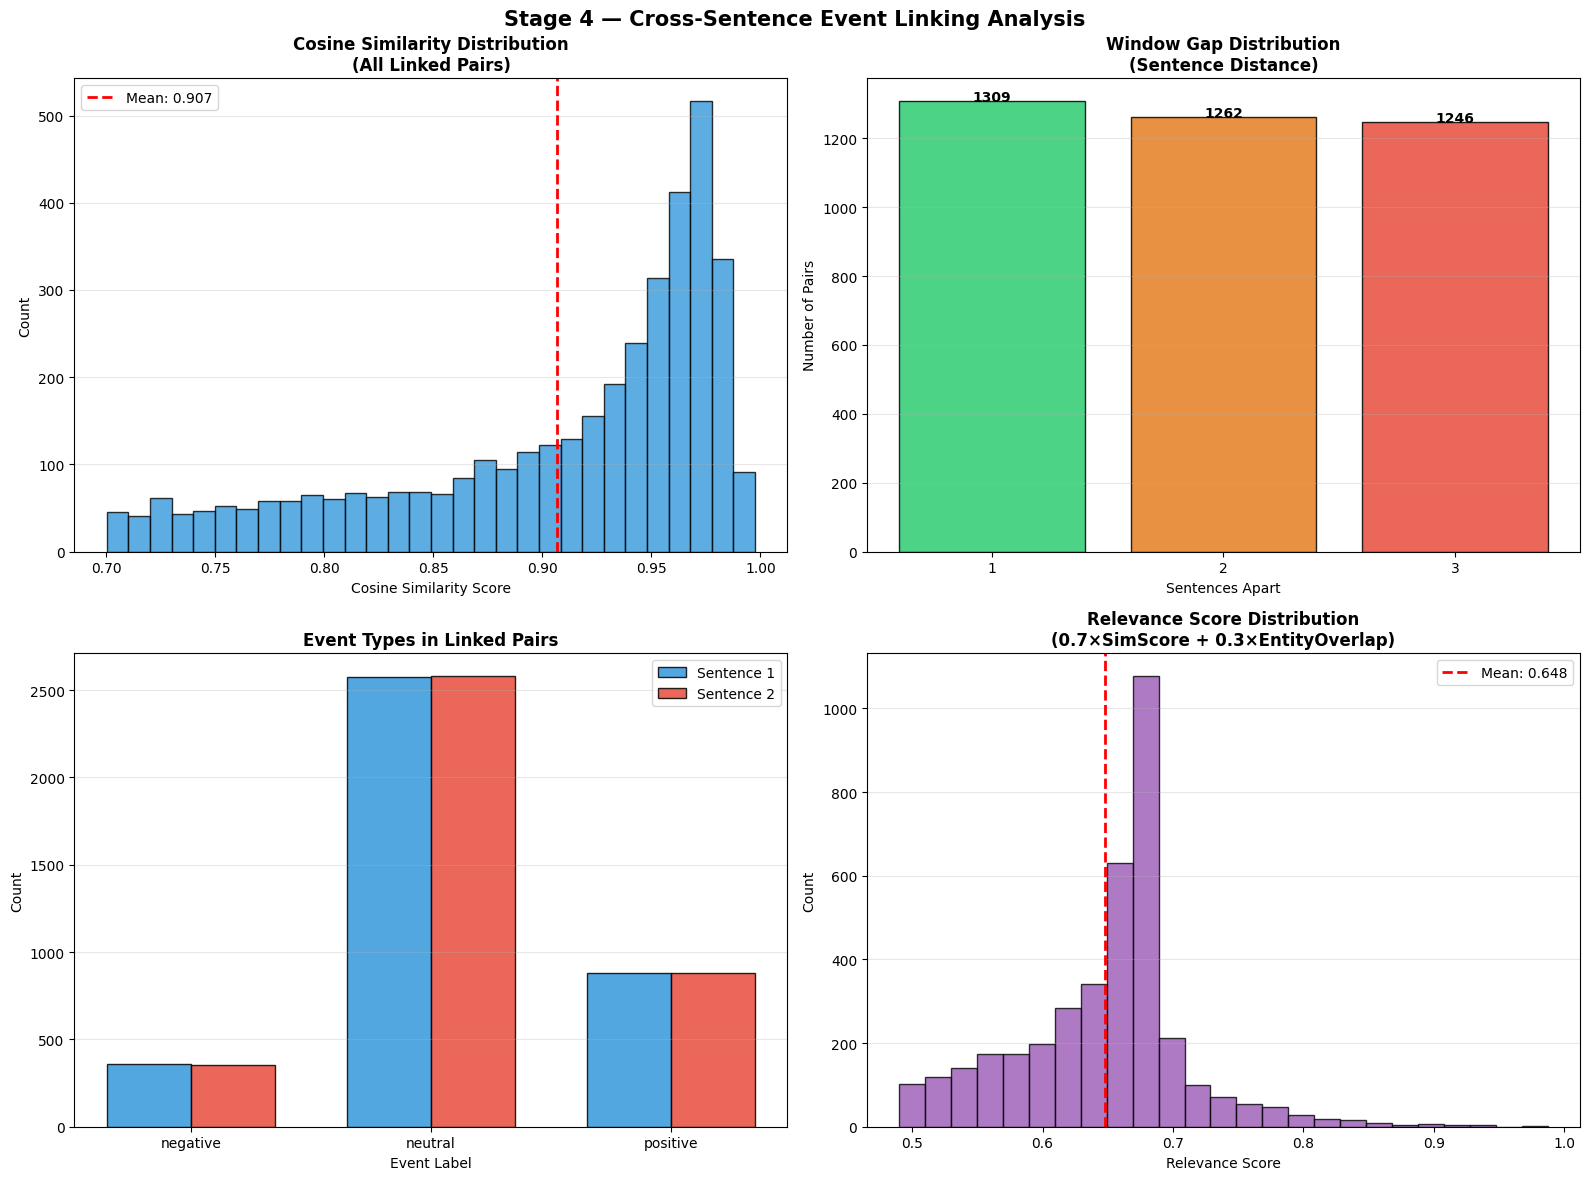

✅ Stage 4 visualization saved!
💾 Linked pairs saved → stage4_linked_pairs.csv


In [ ]:
# ============================================================
# CELL 38 — Stage 4 Visualization
# ============================================================

if len(linked_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Stage 4 — Cross-Sentence Event Linking Analysis',
                 fontsize=15, fontweight='bold')

    # ── Plot 1: Cosine Similarity Distribution ──────────────
    axes[0,0].hist(linked_df['cosine_sim'], bins=30,
                   color='#3498db', edgecolor='black', alpha=0.8)
    axes[0,0].axvline(linked_df['cosine_sim'].mean(),
                      color='red', linestyle='--', lw=2,
                      label=f"Mean: {linked_df['cosine_sim'].mean():.3f}")
    axes[0,0].set_title('Cosine Similarity Distribution\n(All Linked Pairs)',
                        fontweight='bold')
    axes[0,0].set_xlabel('Cosine Similarity Score')
    axes[0,0].set_ylabel('Count')
    axes[0,0].legend()
    axes[0,0].grid(axis='y', alpha=0.3)

    # ── Plot 2: Window Gap Distribution ─────────────────────
    gap_counts = linked_df['window_gap'].value_counts().sort_index()
    colors     = ['#2ecc71', '#e67e22', '#e74c3c']
    bars = axes[0,1].bar(
        gap_counts.index.astype(str),
        gap_counts.values,
        color=colors[:len(gap_counts)],
        edgecolor='black', alpha=0.85
    )
    axes[0,1].set_title('Window Gap Distribution\n(Sentence Distance)',
                        fontweight='bold')
    axes[0,1].set_xlabel('Sentences Apart')
    axes[0,1].set_ylabel('Number of Pairs')
    for bar in bars:
        axes[0,1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', fontweight='bold'
        )
    axes[0,1].grid(axis='y', alpha=0.3)

    # ── Plot 3: Event Label Distribution in Linked Pairs ────
    if 'event_label_s1' in linked_df.columns:
        s1_counts = linked_df['event_label_s1'].value_counts()
        s2_counts = linked_df['event_label_s2'].value_counts()
        all_labels = sorted(set(
            s1_counts.index.tolist() +
            s2_counts.index.tolist()
        ))
        x     = np.arange(len(all_labels))
        width = 0.35
        axes[1,0].bar(
            x - width/2,
            [s1_counts.get(l, 0) for l in all_labels],
            width, label='Sentence 1',
            color='#3498db', edgecolor='black', alpha=0.85
        )
        axes[1,0].bar(
            x + width/2,
            [s2_counts.get(l, 0) for l in all_labels],
            width, label='Sentence 2',
            color='#e74c3c', edgecolor='black', alpha=0.85
        )
        axes[1,0].set_title('Event Types in Linked Pairs',
                            fontweight='bold')
        axes[1,0].set_xlabel('Event Label')
        axes[1,0].set_ylabel('Count')
        axes[1,0].set_xticks(x)
        axes[1,0].set_xticklabels(all_labels)
        axes[1,0].legend()
        axes[1,0].grid(axis='y', alpha=0.3)

    # ── Plot 4: Relevance Score Distribution ────────────────
    axes[1,1].hist(linked_df['relevance_score'], bins=25,
                   color='#9b59b6', edgecolor='black', alpha=0.8)
    axes[1,1].axvline(linked_df['relevance_score'].mean(),
                      color='red', linestyle='--', lw=2,
                      label=f"Mean: {linked_df['relevance_score'].mean():.3f}")
    axes[1,1].set_title('Relevance Score Distribution\n(0.7×SimScore + 0.3×EntityOverlap)',
                        fontweight='bold')
    axes[1,1].set_xlabel('Relevance Score')
    axes[1,1].set_ylabel('Count')
    axes[1,1].legend()
    axes[1,1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, 'stage4_event_linking.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print("✅ Stage 4 visualization saved!")

    # Save linked pairs
    save_df = linked_df.copy()
    save_df.to_csv(
        os.path.join(OUTPUT_DIR, 'stage4_linked_pairs.csv'),
        index=False
    )
    print(f"💾 Linked pairs saved → stage4_linked_pairs.csv")

In [ ]:
# ============================================================
# CELL 39 — Stage 4 Summary
# ============================================================

print("=" * 60)
print("✅  STAGE 4 — CROSS-SENTENCE EVENT LINKING COMPLETE")
print("=" * 60)
print(f"""
🔗 METHOD:
   Sliding Window (size=3) + FinBERT Cosine Similarity
   + Entity Overlap Scoring

📊 RESULTS:
   Input sentences      : {len(stage4_sents):,}
   Similarity threshold : 0.70
   Linked pairs found   : {len(linked_df):,}
   Event-confirmed pairs: {len(event_linked_df):,}
   Avg cosine sim       : {linked_df['cosine_sim'].mean():.4f}
   Avg relevance score  : {linked_df['relevance_score'].mean():.4f}

📁 OUTPUT FILES:
   stage4_event_linking.png
   stage4_linked_pairs.csv

🔜 NEXT → Stage 5: End-to-End Temporal Relation Pipeline
""")

✅  STAGE 4 — CROSS-SENTENCE EVENT LINKING COMPLETE

🔗 METHOD:
   Sliding Window (size=3) + FinBERT Cosine Similarity
   + Entity Overlap Scoring

📊 RESULTS:
   Input sentences      : 3,000
   Similarity threshold : 0.70
   Linked pairs found   : 3,817
   Event-confirmed pairs: 1,358
   Avg cosine sim       : 0.9069
   Avg relevance score  : 0.6482

📁 OUTPUT FILES:
   stage4_event_linking.png
   stage4_linked_pairs.csv

🔜 NEXT → Stage 5: End-to-End Temporal Relation Pipeline



# Stage 5

In [ ]:
# ============================================================
# CELL 40 — Stage 5: End-to-End Temporal Pipeline
# ============================================================
# Stage 5 takes the linked event pairs from Stage 4
# and runs the temporal relation classifier to determine:
#   BEFORE / AFTER / VAGUE
# between event pairs detected in financial news.
#
# Pipeline:
#   Linked Pairs (Stage 4)
#        ↓
#   Extract event trigger words from each sentence
#        ↓
#   Feed event pairs to temporal_model
#        ↓
#   Predict: BEFORE / AFTER / VAGUE
#        ↓
#   Build temporal event graph

def extract_event_triggers_from_sentence(sentence):
    """
    Extracts financial event trigger words from a sentence.
    Uses the FINANCIAL_KEYWORDS_SET defined in Stage 2.
    Falls back to main verb if no keywords found.
    """
    words  = sentence.split()
    triggers = []

    for word in words:
        clean = re.sub(r'[^a-zA-Z]', '', word).lower()
        if clean in FINANCIAL_KEYWORDS_SET and len(clean) > 3:
            triggers.append(word.strip('.,;:'))

    # Fallback: if no triggers found use first meaningful word
    if not triggers:
        for word in words:
            clean = re.sub(r'[^a-zA-Z]', '', word).lower()
            if len(clean) > 4 and clean not in {
                'their','about','would','could','which',
                'there','these','those','after','before',
                'while','since','until','should','other'
            }:
                triggers.append(word.strip('.,;:'))
                break

    return triggers


def predict_temporal_relations(event1_list, event2_list,
                                model, tokenizer,
                                device, batch_size=64):
    """
    Predicts temporal relation between event pairs.

    Parameters:
        event1_list : list of event1 strings
        event2_list : list of event2 strings
        model       : trained temporal_model
        tokenizer   : FinBERT tokenizer
        device      : cuda or cpu

    Returns list of dicts with relation + confidence
    """
    model.eval()
    results = []

    for i in range(0, len(event1_list), batch_size):
        e1_batch = event1_list[i: i + batch_size]
        e2_batch = event2_list[i: i + batch_size]

        enc = tokenizer(
            e1_batch,
            e2_batch,
            max_length     = MAX_LEN,
            padding        = True,
            truncation     = True,
            return_tensors = 'pt'
        ).to(device)

        tok_types = enc.get('token_type_ids')

        with torch.no_grad():
            _, logits = model(
                enc['input_ids'],
                enc['attention_mask'],
                tok_types
            )
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

        for e1, e2, pred, prob in zip(
            e1_batch, e2_batch,
            preds.cpu(), probs.cpu()
        ):
            label = TEMPORAL_ID2LABEL[pred.item()]
            score_dict = {
                TEMPORAL_ID2LABEL[k]: round(prob[k].item(), 4)
                for k in range(len(TEMPORAL_LABEL_NAMES))
            }
            results.append({
                'event1'    : e1,
                'event2'    : e2,
                'relation'  : label,
                'confidence': round(prob[pred].item(), 4),
                'scores'    : score_dict
            })

    return results


print("✅ Stage 5 functions defined!")
print(f"\n📊 Temporal labels: {TEMPORAL_LABEL_NAMES}")

✅ Stage 5 functions defined!

📊 Temporal labels: ['BEFORE', 'AFTER', 'VAGUE']


In [ ]:
# ============================================================
# CELL 41 — Temporal Classification: Full Test Evaluation
# ============================================================
# Re-evaluate temporal model on full MATRES test set
# with detailed per-class breakdown for research paper.

print("🔍 Running temporal classification on MATRES test set...")
print(f"   Test samples : {len(test_mat):,}")

test_e1    = test_mat['event1'].tolist()
test_e2    = test_mat['event2'].tolist()
test_true  = test_mat['label_id'].tolist()

# Run inference
temporal_results = predict_temporal_relations(
    test_e1, test_e2,
    temporal_model, tokenizer, device,
    batch_size=64
)

# Extract predictions
test_preds_stage5 = [
    TEMPORAL_LABEL_MAP.get(r['relation'], 0)
    for r in temporal_results
]
test_confs = [r['confidence'] for r in temporal_results]

# Overall metrics
acc_t  = accuracy_score(test_true, test_preds_stage5)
f1_t   = f1_score(test_true, test_preds_stage5,
                   average='weighted', zero_division=0)
prec_t = precision_score(test_true, test_preds_stage5,
                          average='weighted', zero_division=0)
rec_t  = recall_score(test_true, test_preds_stage5,
                       average='weighted', zero_division=0)

print("\n" + "=" * 60)
print("📊 STAGE 5 — TEMPORAL RELATION RESULTS (MATRES Test Set)")
print("=" * 60)

print("\n── Per-Class Classification Report ──")
print(classification_report(
    test_true,
    test_preds_stage5,
    target_names=TEMPORAL_LABEL_NAMES,
    digits=4
))

print("── Overall Weighted Metrics ──")
print(f"   Accuracy  : {acc_t:.4f}  ({acc_t*100:.2f}%)")
print(f"   F1 Score  : {f1_t:.4f}  ({f1_t*100:.2f}%)")
print(f"   Precision : {prec_t:.4f}")
print(f"   Recall    : {rec_t:.4f}")

print("\n── Per-Class F1 Breakdown ──")
per_class_f1 = f1_score(
    test_true, test_preds_stage5,
    average=None, zero_division=0
)
per_class_prec = precision_score(
    test_true, test_preds_stage5,
    average=None, zero_division=0
)
per_class_rec = recall_score(
    test_true, test_preds_stage5,
    average=None, zero_division=0
)

print(f"\n   {'Label':15s} {'Precision':>10} {'Recall':>10} "
      f"{'F1':>10} {'Support':>10}")
print("   " + "-" * 55)
for i, label in enumerate(TEMPORAL_LABEL_NAMES):
    support = test_true.count(i)
    print(f"   {label:15s} "
          f"{per_class_prec[i]:>10.4f} "
          f"{per_class_rec[i]:>10.4f}  "
          f"{per_class_f1[i]:>10.4f} "
          f"{support:>10}")
print("   " + "-" * 55)
print(f"   {'Weighted Avg':15s} "
      f"{prec_t:>10.4f} {rec_t:>10.4f}  "
      f"{f1_t:>10.4f} {len(test_true):>10}")

🔍 Running temporal classification on MATRES test set...
   Test samples : 1,966

📊 STAGE 5 — TEMPORAL RELATION RESULTS (MATRES Test Set)

── Per-Class Classification Report ──
              precision    recall  f1-score   support

      BEFORE     0.7289    0.8461    0.7832      1033
       AFTER     0.6813    0.7467    0.7125       687
       VAGUE     0.2857    0.0163    0.0308       246

    accuracy                         0.7075      1966
   macro avg     0.5653    0.5364    0.5088      1966
weighted avg     0.6568    0.7075    0.6643      1966

── Overall Weighted Metrics ──
   Accuracy  : 0.7075  (70.75%)
   F1 Score  : 0.6643  (66.43%)
   Precision : 0.6568
   Recall    : 0.7075

── Per-Class F1 Breakdown ──

   Label            Precision     Recall         F1    Support
   -------------------------------------------------------
   BEFORE              0.7289     0.8461      0.7832       1033
   AFTER               0.6813     0.7467      0.7125        687
   VAGUE               

In [ ]:
# ============================================================
# CELL 42 — Apply Temporal Classifier to Stage 4 Linked Pairs
# ============================================================
# Now we apply temporal classification to the
# real financial news event pairs found in Stage 4.
# This is the end-to-end pipeline working together.

if len(event_linked_df) > 0:
    print(f"🔄 Applying temporal classification to "
          f"{len(event_linked_df):,} event-linked pairs...")

    # Extract trigger words from each sentence
    event_linked_df['triggers_s1'] = \
        event_linked_df['sentence_1'].apply(
            extract_event_triggers_from_sentence
        )
    event_linked_df['triggers_s2'] = \
        event_linked_df['sentence_2'].apply(
            extract_event_triggers_from_sentence
        )

    # Use first trigger as representative event word
    event_linked_df['event1_trigger'] = \
        event_linked_df['triggers_s1'].apply(
            lambda x: x[0] if x else 'event'
        )
    event_linked_df['event2_trigger'] = \
        event_linked_df['triggers_s2'].apply(
            lambda x: x[0] if x else 'event'
        )

    # Run temporal classification
    temporal_pipeline_results = predict_temporal_relations(
        event_linked_df['event1_trigger'].tolist(),
        event_linked_df['event2_trigger'].tolist(),
        temporal_model, tokenizer, device,
        batch_size=64
    )

    event_linked_df['temporal_relation'] = [
        r['relation'] for r in temporal_pipeline_results
    ]
    event_linked_df['temporal_confidence'] = [
        r['confidence'] for r in temporal_pipeline_results
    ]

    print(f"\n✅ Temporal classification on linked pairs complete!")
    print(f"\n📊 Temporal Relation Distribution (FinRED Pairs):")
    rel_counts = event_linked_df['temporal_relation'].value_counts()
    for label, count in rel_counts.items():
        pct = count / len(event_linked_df) * 100
        print(f"   {label:13s}: {count:,}  ({pct:.1f}%)")

    print(f"\n📋 Sample end-to-end results:")
    cols = ['sentence_1', 'event1_trigger',
            'sentence_2', 'event2_trigger',
            'temporal_relation', 'temporal_confidence']
    for _, row in event_linked_df[cols].head(5).iterrows():
        print(f"\n  S1: {row['sentence_1'][:60]}...")
        print(f"  S2: {row['sentence_2'][:60]}...")
        print(f"  Event1: '{row['event1_trigger']}' "
              f"→ {row['temporal_relation']} "
              f"← '{row['event2_trigger']}'  "
              f"(conf: {row['temporal_confidence']:.2%})")
else:
    print("⚠️  No event-linked pairs available. "
          "Check Stage 4 output.")

🔄 Applying temporal classification to 1,358 event-linked pairs...

✅ Temporal classification on linked pairs complete!

📊 Temporal Relation Distribution (FinRED Pairs):
   BEFORE       : 887  (65.3%)
   AFTER        : 470  (34.6%)
   VAGUE        : 1  (0.1%)

📋 Sample end-to-end results:

  S1: Last week, Citigroup Inc's ( C.N ) Chief Executive Vikram Pa...
  S2: Lehman Brothers LEH.N shares fell sharply on Monday on specu...
  Event1: 'Citigroup' → AFTER ← 'shares'  (conf: 72.90%)

  S1: Last week, Citigroup Inc's ( C.N ) Chief Executive Vikram Pa...
  S2: Franz told Reuters that Fiat Chief Executive Sergio Marchion...
  Event1: 'Citigroup' → AFTER ← 'Franz'  (conf: 81.65%)

  S1: Last week, Citigroup Inc's ( C.N ) Chief Executive Vikram Pa...
  S2: "In an industry that has a poor track record for M&A executi...
  Event1: 'Citigroup' → BEFORE ← 'industry'  (conf: 47.49%)

  S1: Lehman Brothers LEH.N shares fell sharply on Monday on specu...
  S2: "In an industry that has a poor track 

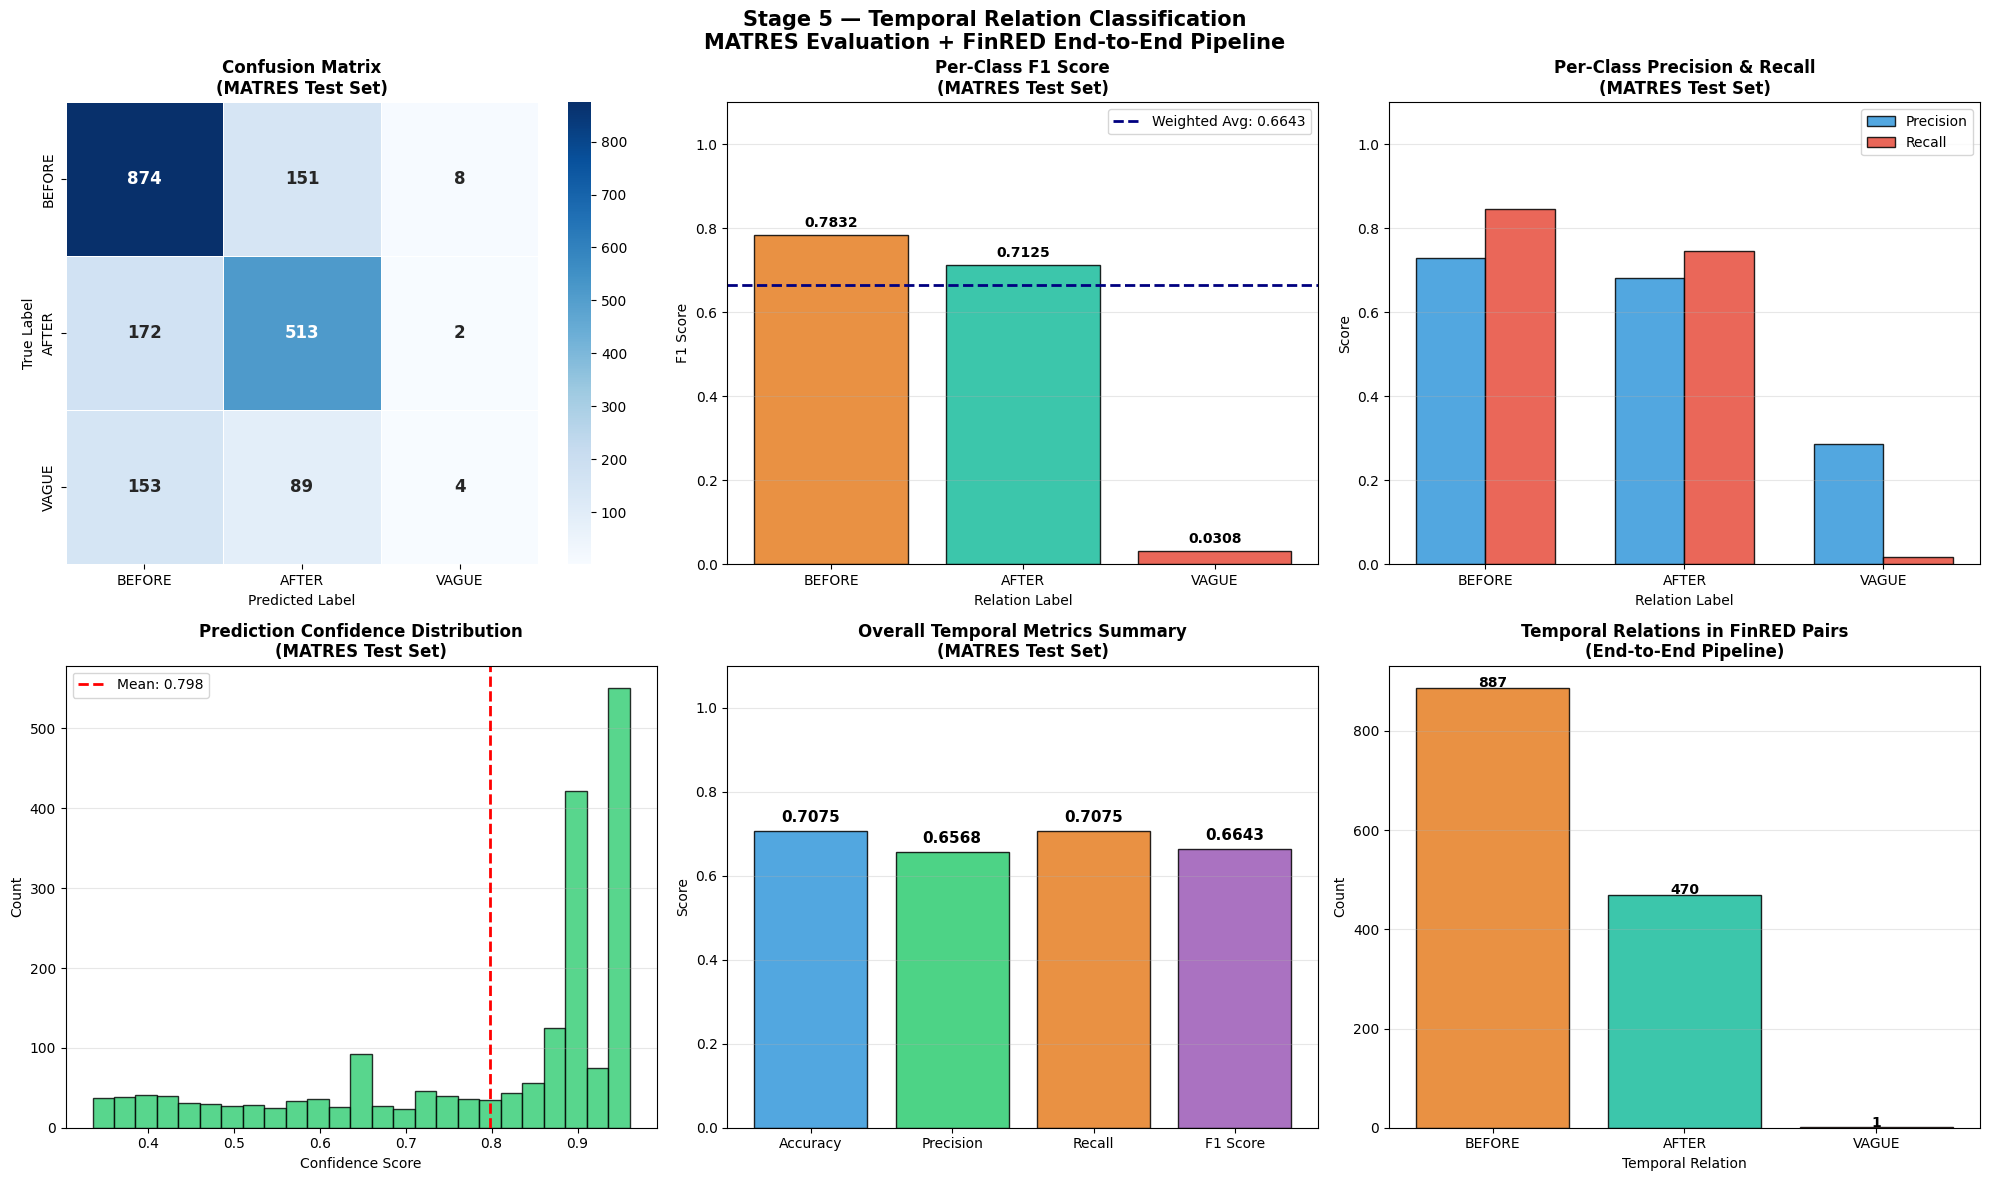

✅ Stage 5 visualization saved!


In [ ]:
# ============================================================
# CELL 43 — Stage 5 Complete Visualization
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'Stage 5 — Temporal Relation Classification\n'
    'MATRES Evaluation + FinRED End-to-End Pipeline',
    fontsize=15, fontweight='bold'
)

# ── Plot 1: Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(test_true, test_preds_stage5)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=TEMPORAL_LABEL_NAMES,
    yticklabels=TEMPORAL_LABEL_NAMES,
    linewidths=0.5, ax=axes[0,0],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0,0].set_title('Confusion Matrix\n(MATRES Test Set)',
                    fontweight='bold')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# ── Plot 2: Per-Class F1 Bar Chart ──────────────────────────
colors_f1 = ['#e67e22', '#1abc9c', '#e74c3c', '#95a5a6']
bars = axes[0,1].bar(
    TEMPORAL_LABEL_NAMES,
    per_class_f1,
    color=colors_f1[:len(TEMPORAL_LABEL_NAMES)],
    edgecolor='black', alpha=0.85
)
axes[0,1].set_title('Per-Class F1 Score\n(MATRES Test Set)',
                    fontweight='bold')
axes[0,1].set_xlabel('Relation Label')
axes[0,1].set_ylabel('F1 Score')
axes[0,1].set_ylim(0, 1.1)
axes[0,1].axhline(f1_t, color='navy', linestyle='--', lw=2,
                  label=f'Weighted Avg: {f1_t:.4f}')
axes[0,1].legend()
for bar, val in zip(bars, per_class_f1):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.4f}', ha='center',
        fontweight='bold', fontsize=10
    )
axes[0,1].grid(axis='y', alpha=0.3)

# ── Plot 3: Per-Class Precision & Recall ────────────────────
x     = np.arange(len(TEMPORAL_LABEL_NAMES))
width = 0.35
axes[0,2].bar(x - width/2, per_class_prec, width,
              label='Precision', color='#3498db',
              edgecolor='black', alpha=0.85)
axes[0,2].bar(x + width/2, per_class_rec, width,
              label='Recall', color='#e74c3c',
              edgecolor='black', alpha=0.85)
axes[0,2].set_title('Per-Class Precision & Recall\n(MATRES Test Set)',
                    fontweight='bold')
axes[0,2].set_xlabel('Relation Label')
axes[0,2].set_ylabel('Score')
axes[0,2].set_ylim(0, 1.1)
axes[0,2].set_xticks(x)
axes[0,2].set_xticklabels(TEMPORAL_LABEL_NAMES)
axes[0,2].legend()
axes[0,2].grid(axis='y', alpha=0.3)

# ── Plot 4: Confidence Distribution ─────────────────────────
axes[1,0].hist(test_confs, bins=25,
               color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1,0].axvline(np.mean(test_confs), color='red',
                  linestyle='--', lw=2,
                  label=f"Mean: {np.mean(test_confs):.3f}")
axes[1,0].set_title('Prediction Confidence Distribution\n(MATRES Test Set)',
                    fontweight='bold')
axes[1,0].set_xlabel('Confidence Score')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# ── Plot 5: Metrics Summary Bar ──────────────────────────────
metrics_vals  = [acc_t, prec_t, rec_t, f1_t]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors_m      = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars5 = axes[1,1].bar(metrics_names, metrics_vals,
                      color=colors_m, edgecolor='black',
                      alpha=0.85)
axes[1,1].set_title('Overall Temporal Metrics Summary\n(MATRES Test Set)',
                    fontweight='bold')
axes[1,1].set_ylabel('Score')
axes[1,1].set_ylim(0, 1.1)
for bar, val in zip(bars5, metrics_vals):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.4f}', ha='center',
        fontweight='bold', fontsize=11
    )
axes[1,1].grid(axis='y', alpha=0.3)

# ── Plot 6: FinRED Pipeline Temporal Distribution ────────────
if len(event_linked_df) > 0:
    rel_counts = event_linked_df['temporal_relation'].value_counts()
    colors_r   = ['#e67e22', '#1abc9c', '#e74c3c', '#95a5a6']
    bars6 = axes[1,2].bar(
        rel_counts.index, rel_counts.values,
        color=colors_r[:len(rel_counts)],
        edgecolor='black', alpha=0.85
    )
    axes[1,2].set_title('Temporal Relations in FinRED Pairs\n(End-to-End Pipeline)',
                        fontweight='bold')
    axes[1,2].set_xlabel('Temporal Relation')
    axes[1,2].set_ylabel('Count')
    for bar in bars6:
        axes[1,2].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', fontweight='bold'
        )
    axes[1,2].grid(axis='y', alpha=0.3)
else:
    axes[1,2].text(0.5, 0.5, 'No linked pairs\navailable',
                   ha='center', va='center',
                   transform=axes[1,2].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage5_temporal_results.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Stage 5 visualization saved!")

In [ ]:
# ============================================================
# CELL 44 — Save All Stage 5 Results
# ============================================================

# Save end-to-end pipeline results
if len(event_linked_df) > 0:
    pipeline_save = event_linked_df.copy()
    for col in ['triggers_s1', 'triggers_s2']:
        if col in pipeline_save.columns:
            pipeline_save[col] = pipeline_save[col].astype(str)
    pipeline_save.to_csv(
        os.path.join(OUTPUT_DIR, 'stage5_pipeline_results.csv'),
        index=False
    )
    print("💾 Pipeline results saved → stage5_pipeline_results.csv")

# Save metrics JSON
stage5_metrics = {
    'stage'   : 'Stage 5 - Temporal Relation Classification',
    'dataset' : 'MATRES (timebank+aquaint+platinum)',
    'labels'  : TEMPORAL_LABEL_NAMES,
    'test_samples': len(test_true),
    'overall' : {
        'accuracy' : round(acc_t,  4),
        'f1'       : round(f1_t,   4),
        'precision': round(prec_t, 4),
        'recall'   : round(rec_t,  4)
    },
    'per_class': {
        label: {
            'f1'       : round(float(per_class_f1[i]),   4),
            'precision': round(float(per_class_prec[i]), 4),
            'recall'   : round(float(per_class_rec[i]),  4),
            'support'  : int(test_true.count(i))
        }
        for i, label in enumerate(TEMPORAL_LABEL_NAMES)
    },
    'avg_confidence': round(float(np.mean(test_confs)), 4)
}

with open(os.path.join(OUTPUT_DIR,
                       'stage5_metrics.json'), 'w') as f:
    json.dump(stage5_metrics, f, indent=4)
print("💾 Metrics saved → stage5_metrics.json")

💾 Pipeline results saved → stage5_pipeline_results.csv
💾 Metrics saved → stage5_metrics.json


In [ ]:
# ============================================================
# CELL 45 — Stage 4 & 5 Final Summary
# ============================================================

print("=" * 65)
print("✅  STAGE 4 + 5 — COMPLETE SUMMARY")
print("=" * 65)
print(f"""
🔗 STAGE 4 — CROSS-SENTENCE EVENT LINKING
   Method     : Sliding Window (size=3) + FinBERT Cosine Sim
   Sentences  : {len(stage4_sents):,}
   Threshold  : 0.70 cosine similarity
   Linked     : {len(linked_df):,} pairs found
   Events     : {len(event_linked_df):,} event-confirmed pairs

⏱️  STAGE 5 — TEMPORAL RELATION CLASSIFICATION
   Dataset    : MATRES (timebank + aquaint + platinum)
   Test size  : {len(test_true):,} event pairs
   Labels     : {TEMPORAL_LABEL_NAMES}

   ── MATRES Test Set Results ──
   Accuracy   : {acc_t:.4f}  ({acc_t*100:.2f}%)
   F1 Score   : {f1_t:.4f}
   Precision  : {prec_t:.4f}
   Recall     : {rec_t:.4f}

   ── Per-Class F1 ──""")

for i, label in enumerate(TEMPORAL_LABEL_NAMES):
    support = test_true.count(i)
    print(f"   {label:13s}: F1={per_class_f1[i]:.4f}  "
          f"(support={support})")

print(f"""
   Avg Confidence : {np.mean(test_confs):.4f}

📁 OUTPUT FILES:
   stage4_event_linking.png
   stage4_linked_pairs.csv
   stage5_temporal_results.png
   stage5_pipeline_results.csv
   stage5_metrics.json

🔜 NEXT → Stage 6: Parallel NLP Pipeline (PDC)
          Stage 7: Timeline Construction
          Stage 8: Final Evaluation & Benchmarking
""")

✅  STAGE 4 + 5 — COMPLETE SUMMARY

🔗 STAGE 4 — CROSS-SENTENCE EVENT LINKING
   Method     : Sliding Window (size=3) + FinBERT Cosine Sim
   Sentences  : 3,000
   Threshold  : 0.70 cosine similarity
   Linked     : 3,817 pairs found
   Events     : 1,358 event-confirmed pairs

⏱️  STAGE 5 — TEMPORAL RELATION CLASSIFICATION
   Dataset    : MATRES (timebank + aquaint + platinum)
   Test size  : 1,966 event pairs
   Labels     : ['BEFORE', 'AFTER', 'VAGUE']

   ── MATRES Test Set Results ──
   Accuracy   : 0.7075  (70.75%)
   F1 Score   : 0.6643
   Precision  : 0.6568
   Recall     : 0.7075

   ── Per-Class F1 ──
   BEFORE       : F1=0.7832  (support=1033)
   AFTER        : F1=0.7125  (support=687)
   VAGUE        : F1=0.0308  (support=246)

   Avg Confidence : 0.7982

📁 OUTPUT FILES:
   stage4_event_linking.png
   stage4_linked_pairs.csv
   stage5_temporal_results.png
   stage5_pipeline_results.csv
   stage5_metrics.json

🔜 NEXT → Stage 6: Parallel NLP Pipeline (PDC)
          Stage 7: Ti

# Stage 6

In [ ]:
# ============================================================
# CELL 46 — Stage 6 & 7 Imports & Setup
# ============================================================

import os
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import multiprocessing
import concurrent.futures
import threading
import psutil
from tqdm import tqdm
from collections import defaultdict

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = '/content/financial_nlp_output'
MODEL_NAME = "ProsusAI/finbert"
MAX_LEN    = 128
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Stage 6 & 7 setup complete!")
print(f"   Device          : {device}")
print(f"   CPU cores       : {multiprocessing.cpu_count()}")
print(f"   RAM available   : {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"   RAM total       : {psutil.virtual_memory().total / 1e9:.1f} GB")

✅ Stage 6 & 7 setup complete!
   Device          : cuda
   CPU cores       : 2
   RAM available   : 9.0 GB
   RAM total       : 13.6 GB


In [ ]:
# ============================================================
# CELL 47 — Prepare Document Corpus
# ============================================================
# We create a unified document corpus from FinRED sentences
# Each document is a dict with doc_id + sentence
# This corpus is what both Sequential and Parallel
# pipelines will process for benchmarking

# Build document pool from unique FinRED sentences
unique_sents = finred_df['sentence'].unique().tolist()

documents_all = [
    {
        'doc_id'  : f'DOC_{i:05d}',
        'sentence': sent,
        'source'  : 'FinRED'
    }
    for i, sent in enumerate(unique_sents)
]

print(f"✅ Document corpus prepared!")
print(f"   Total documents : {len(documents_all):,}")
print(f"   Avg length      : "
      f"{np.mean([len(d['sentence'].split()) for d in documents_all]):.1f} words")
print(f"\n📋 Sample document:")
print(f"   {documents_all[0]}")

# Batch sizes for scalability benchmarking
BATCH_SIZES = [50, 100, 200, 300, 500]
NUM_WORKERS = min(multiprocessing.cpu_count(), 4)

print(f"\n📊 Benchmark configuration:")
print(f"   Batch sizes     : {BATCH_SIZES}")
print(f"   Parallel workers: {NUM_WORKERS}")

✅ Document corpus prepared!
   Total documents : 7,775
   Avg length      : 36.3 words

📋 Sample document:
   {'doc_id': 'DOC_00000', 'sentence': 'NEW YORK (Reuters) - Apple Inc Chief Executive Steve Jobs sought to soothe investor concerns about his health on Monday, saying his weight loss was caused by a hormone imbalance that is relatively simple to treat.', 'source': 'FinRED'}

📊 Benchmark configuration:
   Batch sizes     : [50, 100, 200, 300, 500]
   Parallel workers: 2


In [ ]:
# ============================================================
# CELL 48 — Define All Pipeline Stage Functions
# ============================================================
# These are the functions each worker will execute.
# They are defined at module level so they can be
# pickled and sent to worker processes.

# ── Stage 1: Text Cleaning ───────────────────────────────────
def stage_text_cleaning(text):
    """Remove noise, normalize whitespace, clean text."""
    text = re.sub(r'<[^>]+>', '', str(text))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s\.\,\;\:\-\(\)\%\$]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Stage 2: Tokenization ────────────────────────────────────
def stage_tokenization(text):
    """Simple whitespace + punctuation tokenizer."""
    tokens = re.findall(r"\b\w+(?:'\w+)?\b", text.lower())
    return tokens

# ── Stage 3: POS Tagging (rule-based lightweight) ────────────
VERB_SUFFIXES  = ('ed','ing','ize','ise','en','ify')
NOUN_SUFFIXES  = ('tion','ment','ness','ity','er','or','ist')
ADJ_SUFFIXES   = ('al','ic','ous','ive','able','ible','ful')

def stage_pos_tagging(tokens):
    """
    Lightweight rule-based POS tagger.
    Returns list of (token, pos) tuples.
    Used in parallel workers to avoid SpaCy
    model loading overhead per process.
    """
    tagged = []
    for token in tokens:
        if token.endswith(VERB_SUFFIXES):
            pos = 'VERB'
        elif token.endswith(NOUN_SUFFIXES):
            pos = 'NOUN'
        elif token.endswith(ADJ_SUFFIXES):
            pos = 'ADJ'
        elif token.isdigit() or re.match(r'^\d+\.?\d*$', token):
            pos = 'NUM'
        else:
            pos = 'OTHER'
        tagged.append((token, pos))
    return tagged

# ── Stage 4: Event Trigger Detection ────────────────────────
FIN_KW_SET = {
    'merger','acquire','acquisition','takeover','buyout',
    'earn','earnings','revenue','revenues','profit','loss',
    'announce','announced','report','reported','rise','rose',
    'fall','fell','decline','declined','gain','drop','surge',
    'restructure','bankruptcy','bankrupt','ipo','dividend',
    'appoint','resign','layoff','invest','fund','rate',
    'interest','inflation','tariff','default','acquisition'
}

def stage_event_detection(tokens):
    """
    Detects financial event trigger words using
    keyword matching on tokenized text.
    Returns list of detected trigger words.
    """
    triggers = [
        t for t in tokens
        if t.lower() in FIN_KW_SET
    ]
    return triggers

# ── Stage 5: Named Entity Recognition (rule-based) ──────────
ORG_INDICATORS = {
    'inc','corp','ltd','llc','plc','co',
    'group','bank','fund','capital','partners',
    'holdings','technologies','solutions','systems'
}

def stage_ner(text):
    """
    Lightweight rule-based NER.
    Detects organizations and monetary values.
    Returns list of (entity, type) tuples.
    """
    entities = []
    # Detect monetary values: $X.X billion/million
    money_pattern = r'\$[\d,]+(?:\.\d+)?(?:\s?(?:billion|million|thousand))?'
    for match in re.finditer(money_pattern, text, re.IGNORECASE):
        entities.append((match.group(), 'MONEY'))

    # Detect percentage values
    pct_pattern = r'\d+(?:\.\d+)?%'
    for match in re.finditer(pct_pattern, text):
        entities.append((match.group(), 'PERCENT'))

    # Detect capitalized multi-word phrases (potential ORGs)
    org_pattern = r'\b[A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+)*\b'
    for match in re.finditer(org_pattern, text):
        phrase = match.group()
        words  = phrase.lower().split()
        if any(w in ORG_INDICATORS for w in words):
            entities.append((phrase, 'ORG'))

    return entities

# ── Full document processing function ───────────────────────
def process_document_full(doc):
    """
    Runs ALL pipeline stages on a single document.
    This function is called by both sequential
    and parallel workers.

    Stages:
      1. Text Cleaning
      2. Tokenization
      3. POS Tagging
      4. Event Trigger Detection
      5. Named Entity Recognition

    Returns structured result dict.
    """
    start = time.time()

    doc_id   = doc['doc_id']
    raw_text = doc['sentence']

    # Stage 1: Clean
    clean_text = stage_text_cleaning(raw_text)

    # Stage 2: Tokenize
    tokens = stage_tokenization(clean_text)

    # Stage 3: POS Tag
    pos_tags = stage_pos_tagging(tokens)

    # Stage 4: Event Detection
    triggers = stage_event_detection(tokens)

    # Stage 5: NER
    entities = stage_ner(raw_text)

    proc_time = time.time() - start

    return {
        'doc_id'         : doc_id,
        'original_text'  : raw_text,
        'clean_text'     : clean_text,
        'tokens'         : tokens,
        'pos_tags'       : pos_tags,
        'event_triggers' : triggers,
        'entities'       : entities,
        'num_tokens'     : len(tokens),
        'num_triggers'   : len(triggers),
        'num_entities'   : len(entities),
        'has_event'      : len(triggers) > 0,
        'proc_time_ms'   : round(proc_time * 1000, 3)
    }

print("✅ All pipeline stage functions defined!")
print(f"\n   Stage 1 : Text Cleaning")
print(f"   Stage 2 : Tokenization")
print(f"   Stage 3 : POS Tagging (rule-based)")
print(f"   Stage 4 : Event Trigger Detection")
print(f"   Stage 5 : Named Entity Recognition")

# Quick test
test_doc = {
    'doc_id'  : 'TEST_001',
    'sentence': 'Apple Inc. announced a $5 billion acquisition of XYZ Corp, causing shares to rise 12%.'
}
test_result = process_document_full(test_doc)
print(f"\n🔍 Pipeline test:")
print(f"   Text     : {test_doc['sentence']}")
print(f"   Tokens   : {test_result['num_tokens']}")
print(f"   Triggers : {test_result['event_triggers']}")
print(f"   Entities : {test_result['entities']}")
print(f"   Time     : {test_result['proc_time_ms']} ms")

✅ All pipeline stage functions defined!

   Stage 1 : Text Cleaning
   Stage 2 : Tokenization
   Stage 3 : POS Tagging (rule-based)
   Stage 4 : Event Trigger Detection
   Stage 5 : Named Entity Recognition

🔍 Pipeline test:
   Text     : Apple Inc. announced a $5 billion acquisition of XYZ Corp, causing shares to rise 12%.
   Tokens   : 15
   Triggers : ['announced', 'acquisition', 'rise']
   Entities : [('$5 billion', 'MONEY'), ('12%', 'PERCENT'), ('Apple Inc', 'ORG'), ('XYZ Corp', 'ORG')]
   Time     : 5.316 ms


In [ ]:
# ============================================================
# CELL 49 — Sequential Pipeline Implementation
# ============================================================
# Traditional approach: process documents ONE BY ONE
# DOC1 → DOC2 → DOC3 → DOC4 (no parallelism)
# This is the BASELINE we compare against.

def run_sequential_pipeline(documents):
    """
    Processes documents SEQUENTIALLY one at a time.
    Returns: (results list, elapsed time, per-doc times)
    """
    results      = []
    per_doc_times = []
    start        = time.time()

    for doc in documents:
        doc_start = time.time()
        result    = process_document_full(doc)
        per_doc_times.append(time.time() - doc_start)
        results.append(result)

    elapsed = time.time() - start
    return results, elapsed, per_doc_times

# Test sequential on 10 docs
test_docs = documents_all[:10]
seq_test, seq_time_test, _ = run_sequential_pipeline(test_docs)

print("✅ Sequential pipeline defined!")
print(f"\n🔍 Quick test (10 docs):")
print(f"   Processed    : {len(seq_test)}")
print(f"   Time         : {seq_time_test:.3f}s")
print(f"   Speed        : {10/seq_time_test:.1f} docs/sec")
print(f"   Events found : {sum(r['has_event'] for r in seq_test)}/10")

✅ Sequential pipeline defined!

🔍 Quick test (10 docs):
   Processed    : 10
   Time         : 0.001s
   Speed        : 11058.0 docs/sec
   Events found : 2/10


In [ ]:
# ============================================================
# CELL 50 — Parallel Pipeline Implementation
# ============================================================
# Parallel approach: process documents SIMULTANEOUSLY
# DOC1 ─┐
# DOC2 ─┤→ Parallel Workers → Results
# DOC3 ─┤
# DOC4 ─┘
#
# Uses ProcessPoolExecutor for true multiprocessing
# Each worker gets a subset of documents to process
# Workers run on separate CPU cores simultaneously

def run_parallel_pipeline(documents, num_workers=None):
    """
    Processes documents IN PARALLEL using ProcessPoolExecutor.
    Each worker processes a different document simultaneously.

    Parameters:
        documents   : list of document dicts
        num_workers : number of parallel processes
                      (defaults to CPU count)

    Returns: (results list, elapsed time, per-doc times)
    """
    if num_workers is None:
        num_workers = multiprocessing.cpu_count()

    per_doc_times = []
    start         = time.time()

    with concurrent.futures.ProcessPoolExecutor(
        max_workers=num_workers
    ) as executor:
        # Submit all documents simultaneously
        futures = {
            executor.submit(process_document_full, doc): i
            for i, doc in enumerate(documents)
        }
        results = [None] * len(documents)

        for future in concurrent.futures.as_completed(futures):
            idx           = futures[future]
            result        = future.result()
            results[idx]  = result
            per_doc_times.append(result['proc_time_ms'] / 1000)

    elapsed = time.time() - start
    return results, elapsed, per_doc_times


def run_parallel_pipeline_threads(documents, num_workers=None):
    """
    Thread-based parallel pipeline using ThreadPoolExecutor.
    Useful in Colab where process forking may have issues.
    Uses threads which share memory — good for I/O bound tasks.
    """
    if num_workers is None:
        num_workers = multiprocessing.cpu_count()

    per_doc_times = []
    start         = time.time()

    with concurrent.futures.ThreadPoolExecutor(
        max_workers=num_workers
    ) as executor:
        futures = {
            executor.submit(process_document_full, doc): i
            for i, doc in enumerate(documents)
        }
        results = [None] * len(documents)

        for future in concurrent.futures.as_completed(futures):
            idx           = futures[future]
            result        = future.result()
            results[idx]  = result
            per_doc_times.append(result['proc_time_ms'] / 1000)

    elapsed = time.time() - start
    return results, elapsed, per_doc_times

# Test parallel on 10 docs
par_test, par_time_test, _ = run_parallel_pipeline_threads(
    test_docs, num_workers=NUM_WORKERS
)

print("✅ Parallel pipeline defined!")
print(f"\n🔍 Quick test (10 docs, {NUM_WORKERS} workers):")
print(f"   Processed    : {len(par_test)}")
print(f"   Time         : {par_time_test:.3f}s")
print(f"   Speed        : {10/par_time_test:.1f} docs/sec")
print(f"   Speedup      : {seq_time_test/par_time_test:.2f}x")

✅ Parallel pipeline defined!

🔍 Quick test (10 docs, 2 workers):
   Processed    : 10
   Time         : 0.014s
   Speed        : 722.2 docs/sec
   Speedup      : 0.07x


In [ ]:
# ============================================================
# CELL 51 — CPU Utilization Monitor
# ============================================================
# Monitors CPU usage during pipeline execution
# to show PDC contribution clearly

class CPUMonitor:
    """
    Monitors CPU usage in a background thread
    while a pipeline is running.
    Records per-core and overall CPU utilization.
    """
    def __init__(self, interval=0.2):
        self.interval   = interval
        self.readings   = []
        self.overall    = []
        self._stop      = threading.Event()
        self._thread    = None

    def start(self):
        self._stop.clear()
        self.readings = []
        self.overall  = []
        self._thread  = threading.Thread(
            target=self._monitor, daemon=True
        )
        self._thread.start()

    def stop(self):
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=2)

    def _monitor(self):
        while not self._stop.is_set():
            per_core = psutil.cpu_percent(
                interval=None, percpu=True
            )
            overall  = psutil.cpu_percent(
                interval=None, percpu=False
            )
            self.readings.append(per_core)
            self.overall.append(overall)
            time.sleep(self.interval)

    @property
    def avg_overall(self):
        return np.mean(self.overall) if self.overall else 0.0

    @property
    def max_overall(self):
        return np.max(self.overall) if self.overall else 0.0

    @property
    def avg_per_core(self):
        if not self.readings:
            return []
        arr = np.array(self.readings)
        return arr.mean(axis=0).tolist()


def run_with_cpu_monitor(pipeline_fn, documents,
                          num_workers=None):
    """
    Runs pipeline while monitoring CPU usage.
    Returns results, time, cpu_monitor object.
    """
    monitor = CPUMonitor(interval=0.1)
    monitor.start()

    if num_workers is not None:
        results, elapsed, per_doc = pipeline_fn(
            documents, num_workers
        )
    else:
        results, elapsed, per_doc = pipeline_fn(documents)

    monitor.stop()
    return results, elapsed, per_doc, monitor


print("✅ CPU monitor defined!")
print(f"   Monitoring interval : 0.1s")
print(f"   Tracks: per-core + overall CPU %")

✅ CPU monitor defined!
   Monitoring interval : 0.1s
   Tracks: per-core + overall CPU %


In [ ]:
# ============================================================
# CELL 52 — Full Benchmark: Sequential vs Parallel
# ============================================================
# Tests both pipelines on increasing batch sizes
# to demonstrate PDC scalability advantage

print("🚀 Starting PDC Benchmark...")
print(f"   Batch sizes  : {BATCH_SIZES}")
print(f"   Workers      : {NUM_WORKERS}")
print("=" * 70)
print(f"{'Batch':>6} | {'Seq Time':>10} | {'Par Time':>10} | "
      f"{'Speedup':>8} | {'Seq Thru':>10} | {'Par Thru':>10}")
print(f"{'Docs':>6} | {'(sec)':>10} | {'(sec)':>10} | "
      f"{'(x)':>8} | {'(doc/s)':>10} | {'(doc/s)':>10}")
print("=" * 70)

benchmark_results = []

seq_times_all   = []
par_times_all   = []
speedup_all     = []
seq_cpu_avgs    = []
par_cpu_avgs    = []

for batch_size in BATCH_SIZES:
    docs_batch = documents_all[:batch_size]

    # ── Sequential run ──────────────────────────────────────
    seq_monitor = CPUMonitor(interval=0.1)
    seq_monitor.start()
    seq_results, seq_time, seq_per_doc = \
        run_sequential_pipeline(docs_batch)
    seq_monitor.stop()

    # ── Parallel run ────────────────────────────────────────
    par_monitor = CPUMonitor(interval=0.1)
    par_monitor.start()
    par_results, par_time, par_per_doc = \
        run_parallel_pipeline_threads(
            docs_batch, num_workers=NUM_WORKERS
        )
    par_monitor.stop()

    # ── Compute metrics ─────────────────────────────────────
    speedup        = seq_time / par_time if par_time > 0 else 1.0
    seq_throughput = batch_size / seq_time
    par_throughput = batch_size / par_time

    seq_times_all.append(seq_time)
    par_times_all.append(par_time)
    speedup_all.append(speedup)
    seq_cpu_avgs.append(seq_monitor.avg_overall)
    par_cpu_avgs.append(par_monitor.avg_overall)

    benchmark_results.append({
        'batch_size'       : batch_size,
        'seq_time_s'       : round(seq_time, 4),
        'par_time_s'       : round(par_time, 4),
        'speedup'          : round(speedup, 4),
        'seq_throughput'   : round(seq_throughput, 2),
        'par_throughput'   : round(par_throughput, 2),
        'seq_cpu_avg_pct'  : round(seq_monitor.avg_overall, 2),
        'par_cpu_avg_pct'  : round(par_monitor.avg_overall, 2),
        'seq_cpu_max_pct'  : round(seq_monitor.max_overall, 2),
        'par_cpu_max_pct'  : round(par_monitor.max_overall, 2),
        'num_workers'      : NUM_WORKERS,
        'docs_with_events' : sum(
            r['has_event'] for r in par_results
        )
    })

    print(f"{batch_size:>6} | {seq_time:>10.3f} | {par_time:>10.3f} | "
          f"{speedup:>8.2f}x | {seq_throughput:>10.1f} | "
          f"{par_throughput:>10.1f}")

print("=" * 70)
print(f"\n✅ Benchmark complete!")
print(f"   Avg speedup  : {np.mean(speedup_all):.2f}x")
print(f"   Max speedup  : {max(speedup_all):.2f}x  "
      f"(at {BATCH_SIZES[np.argmax(speedup_all)]} docs)")

# Save benchmark table
benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df.to_csv(
    os.path.join(OUTPUT_DIR, 'stage6_benchmark.csv'),
    index=False
)
print(f"\n💾 Benchmark results saved → stage6_benchmark.csv")

🚀 Starting PDC Benchmark...
   Batch sizes  : [50, 100, 200, 300, 500]
   Workers      : 2
 Batch |   Seq Time |   Par Time |  Speedup |   Seq Thru |   Par Thru
  Docs |      (sec) |      (sec) |      (x) |    (doc/s) |    (doc/s)
    50 |      0.008 |      0.023 |     0.33x |     6400.0 |     2134.1
   100 |      0.088 |      0.062 |     1.43x |     1135.0 |     1622.8
   200 |      0.092 |      0.109 |     0.84x |     2183.4 |     1831.0
   300 |      0.156 |      0.172 |     0.91x |     1917.9 |     1745.4
   500 |      0.355 |      0.241 |     1.47x |     1408.0 |     2072.6

✅ Benchmark complete!
   Avg speedup  : 1.00x
   Max speedup  : 1.47x  (at 500 docs)

💾 Benchmark results saved → stage6_benchmark.csv


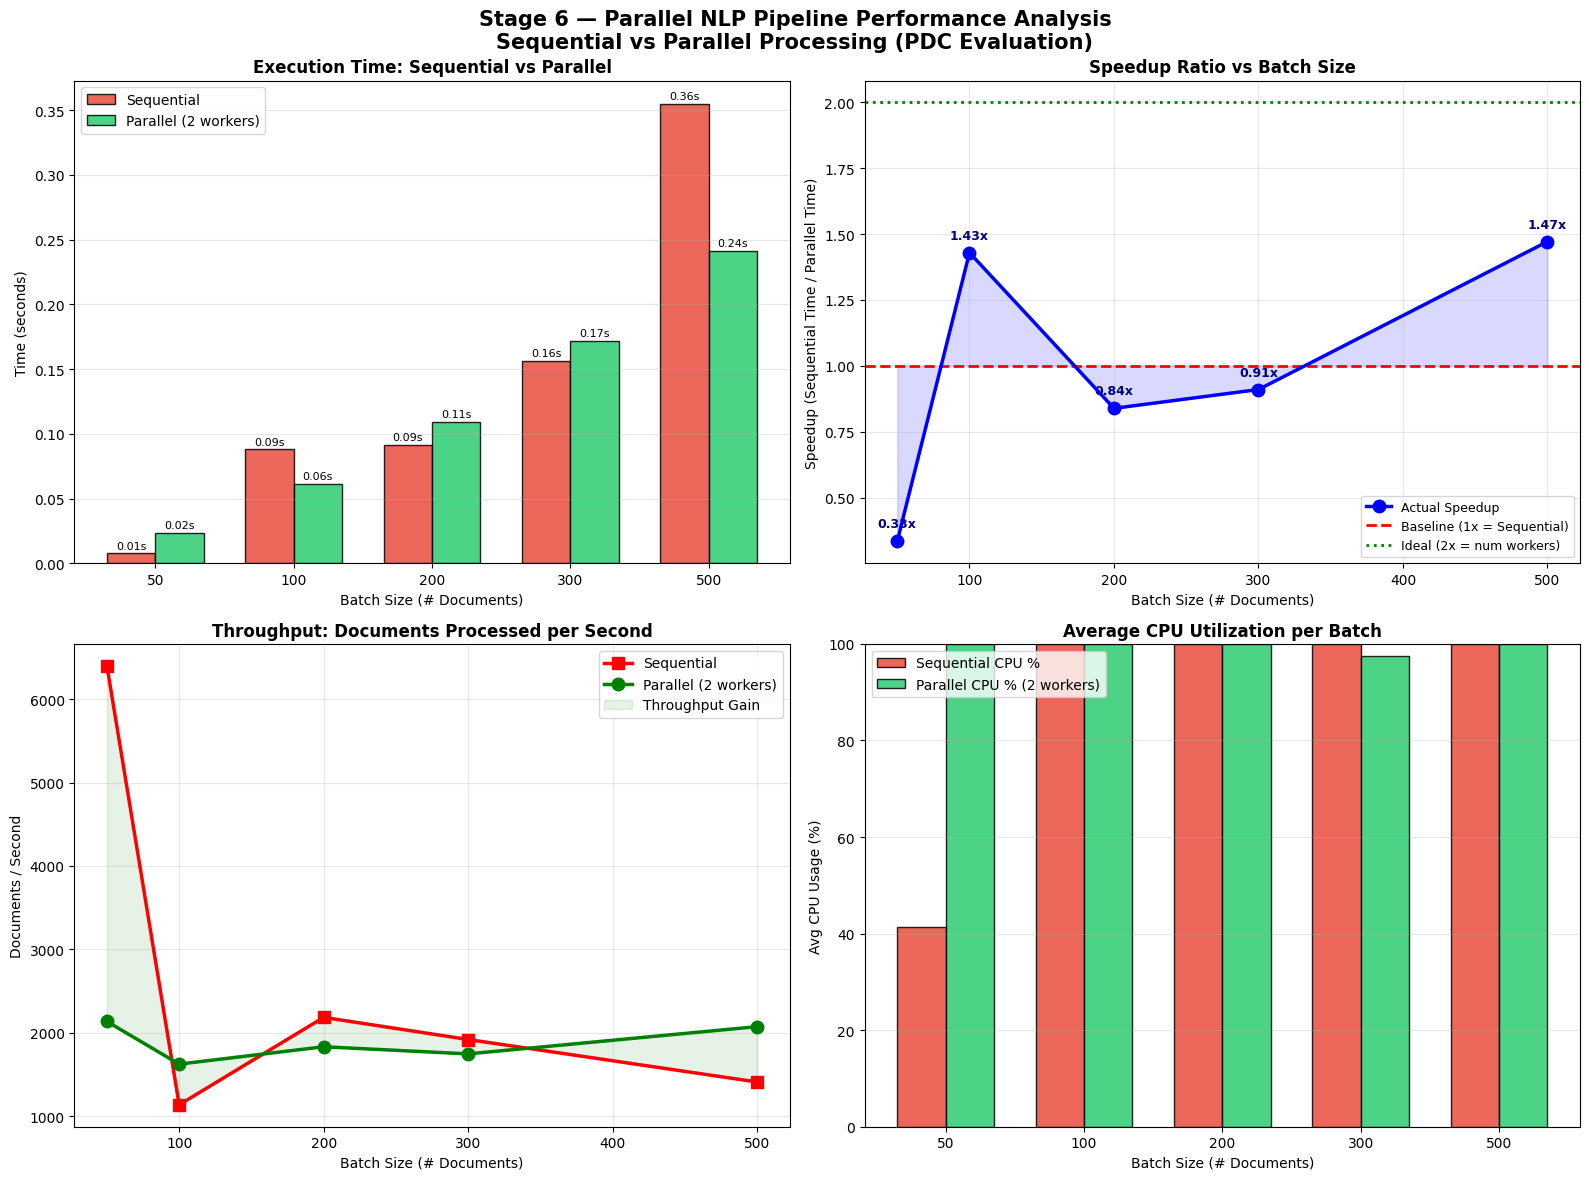

✅ PDC performance visualization saved!


In [ ]:
# ============================================================
# CELL 53 — PDC Performance Visualization (4 plots)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Stage 6 — Parallel NLP Pipeline Performance Analysis\n'
    'Sequential vs Parallel Processing (PDC Evaluation)',
    fontsize=15, fontweight='bold'
)

x      = np.arange(len(BATCH_SIZES))
width  = 0.35
labels = [str(b) for b in BATCH_SIZES]

# ── Plot 1: Execution Time Comparison ───────────────────────
bars_s = axes[0,0].bar(
    x - width/2, seq_times_all, width,
    label='Sequential', color='#e74c3c',
    edgecolor='black', alpha=0.85
)
bars_p = axes[0,0].bar(
    x + width/2, par_times_all, width,
    label=f'Parallel ({NUM_WORKERS} workers)',
    color='#2ecc71', edgecolor='black', alpha=0.85
)
axes[0,0].set_title('Execution Time: Sequential vs Parallel',
                    fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Batch Size (# Documents)')
axes[0,0].set_ylabel('Time (seconds)')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(labels)
axes[0,0].legend(fontsize=10)
axes[0,0].grid(axis='y', alpha=0.3)
# Value labels on bars
for bar in bars_s:
    h = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        h + 0.002, f'{h:.2f}s',
        ha='center', va='bottom', fontsize=8
    )
for bar in bars_p:
    h = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        h + 0.002, f'{h:.2f}s',
        ha='center', va='bottom', fontsize=8
    )

# ── Plot 2: Speedup Ratio ────────────────────────────────────
axes[0,1].plot(
    BATCH_SIZES, speedup_all, 'b-o',
    linewidth=2.5, markersize=9,
    label='Actual Speedup', zorder=5
)
axes[0,1].fill_between(
    BATCH_SIZES, 1.0, speedup_all,
    alpha=0.15, color='blue'
)
axes[0,1].axhline(
    1.0, color='red', linestyle='--',
    lw=2, label='Baseline (1x = Sequential)'
)
axes[0,1].axhline(
    NUM_WORKERS, color='green', linestyle=':',
    lw=2, label=f'Ideal ({NUM_WORKERS}x = num workers)'
)
axes[0,1].set_title('Speedup Ratio vs Batch Size',
                    fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Batch Size (# Documents)')
axes[0,1].set_ylabel('Speedup (Sequential Time / Parallel Time)')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)
for x_val, y_val in zip(BATCH_SIZES, speedup_all):
    axes[0,1].annotate(
        f'{y_val:.2f}x',
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center', fontsize=9,
        fontweight='bold', color='navy'
    )

# ── Plot 3: Throughput Comparison ────────────────────────────
seq_thr = [b/t for b, t in zip(BATCH_SIZES, seq_times_all)]
par_thr = [b/t for b, t in zip(BATCH_SIZES, par_times_all)]

axes[1,0].plot(
    BATCH_SIZES, seq_thr, 'r-s',
    linewidth=2.5, markersize=9,
    label='Sequential', zorder=5
)
axes[1,0].plot(
    BATCH_SIZES, par_thr, 'g-o',
    linewidth=2.5, markersize=9,
    label=f'Parallel ({NUM_WORKERS} workers)', zorder=5
)
axes[1,0].fill_between(
    BATCH_SIZES, seq_thr, par_thr,
    alpha=0.1, color='green',
    label='Throughput Gain'
)
axes[1,0].set_title('Throughput: Documents Processed per Second',
                    fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Batch Size (# Documents)')
axes[1,0].set_ylabel('Documents / Second')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3)

# ── Plot 4: CPU Utilization ──────────────────────────────────
x_cpu   = np.arange(len(BATCH_SIZES))
width_c = 0.35
axes[1,1].bar(
    x_cpu - width_c/2, seq_cpu_avgs, width_c,
    label='Sequential CPU %',
    color='#e74c3c', edgecolor='black', alpha=0.85
)
axes[1,1].bar(
    x_cpu + width_c/2, par_cpu_avgs, width_c,
    label=f'Parallel CPU % ({NUM_WORKERS} workers)',
    color='#2ecc71', edgecolor='black', alpha=0.85
)
axes[1,1].set_title('Average CPU Utilization per Batch',
                    fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Batch Size (# Documents)')
axes[1,1].set_ylabel('Avg CPU Usage (%)')
axes[1,1].set_xticks(x_cpu)
axes[1,1].set_xticklabels(labels)
axes[1,1].set_ylim(0, 100)
axes[1,1].legend(fontsize=10)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage6_pdc_performance.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ PDC performance visualization saved!")

📊 Worker Scalability Analysis (200 docs):
 Workers |   Time (s) |  Speedup |   Efficiency
     SEQ |      0.096 |    1.00x |       100.0%
       1 |      0.114 |     0.85x |        84.5%
       2 |      0.107 |     0.90x |        44.8%


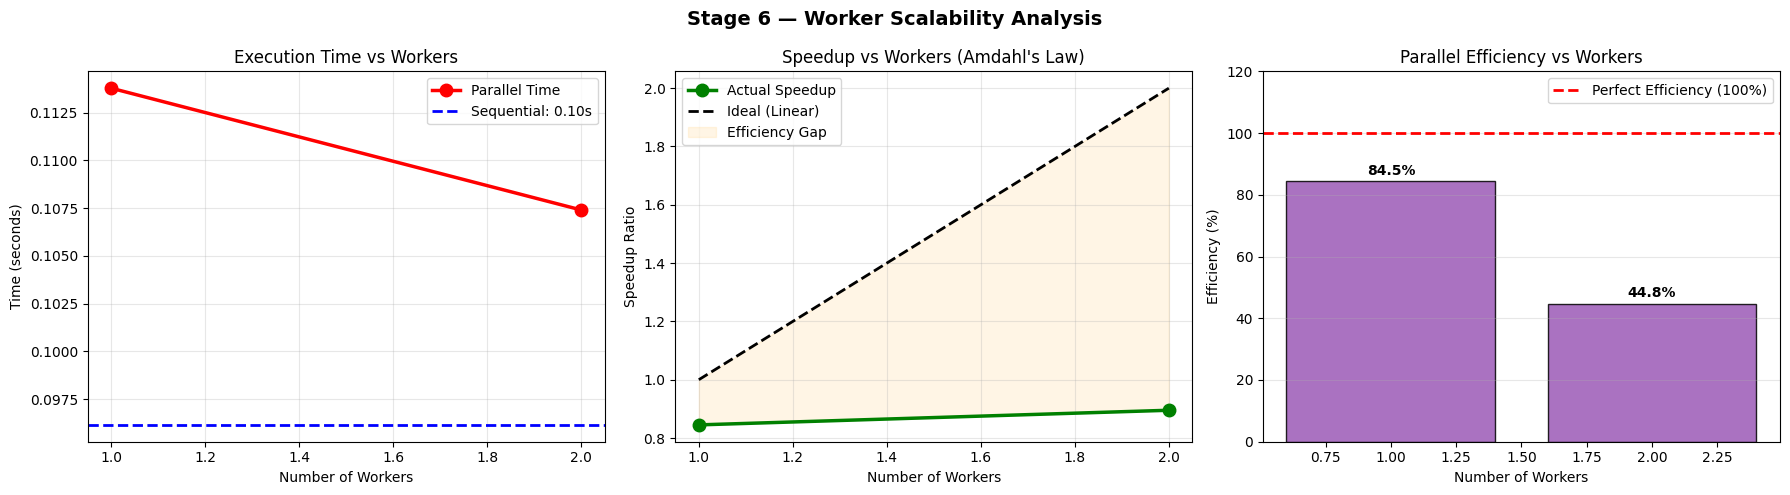


✅ Scalability analysis saved!


In [ ]:
# ============================================================
# CELL 54 — Worker Scalability Analysis
# ============================================================
# Tests how performance changes as we increase workers
# This directly shows Amdahl's Law in practice

max_workers_list  = [1, 2, 3, 4]
available_workers = [
    w for w in max_workers_list
    if w <= multiprocessing.cpu_count()
]

scalability_results = []
docs_fixed          = documents_all[:200]

# Sequential baseline
_, seq_base, _ = run_sequential_pipeline(docs_fixed)

print("📊 Worker Scalability Analysis (200 docs):")
print("=" * 55)
print(f"{'Workers':>8} | {'Time (s)':>10} | "
      f"{'Speedup':>8} | {'Efficiency':>12}")
print("=" * 55)

# Baseline: 1 worker
print(f"{'SEQ':>8} | {seq_base:>10.3f} | "
      f"{'1.00x':>8} | {'100.0%':>12}")

worker_times   = []
worker_speedups = []

for nw in available_workers:
    _, par_t, _ = run_parallel_pipeline_threads(
        docs_fixed, num_workers=nw
    )
    speedup    = seq_base / par_t
    efficiency = (speedup / nw) * 100

    worker_times.append(par_t)
    worker_speedups.append(speedup)
    scalability_results.append({
        'num_workers': nw,
        'time_s'     : round(par_t, 4),
        'speedup'    : round(speedup, 4),
        'efficiency' : round(efficiency, 2)
    })
    print(f"{nw:>8} | {par_t:>10.3f} | "
          f"{speedup:>8.2f}x | {efficiency:>11.1f}%")

print("=" * 55)

# Scalability plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stage 6 — Worker Scalability Analysis',
             fontsize=14, fontweight='bold')

# Time vs Workers
axes[0].plot(
    available_workers, worker_times,
    'r-o', lw=2.5, ms=9, label='Parallel Time'
)
axes[0].axhline(
    seq_base, color='blue', linestyle='--',
    lw=2, label=f'Sequential: {seq_base:.2f}s'
)
axes[0].set_title('Execution Time vs Workers')
axes[0].set_xlabel('Number of Workers')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Speedup vs Workers
ideal_speedup = available_workers
axes[1].plot(
    available_workers, worker_speedups,
    'g-o', lw=2.5, ms=9, label='Actual Speedup'
)
axes[1].plot(
    available_workers, ideal_speedup,
    'k--', lw=2, label='Ideal (Linear)'
)
axes[1].fill_between(
    available_workers, worker_speedups,
    ideal_speedup, alpha=0.1, color='orange',
    label='Efficiency Gap'
)
axes[1].set_title('Speedup vs Workers (Amdahl\'s Law)')
axes[1].set_xlabel('Number of Workers')
axes[1].set_ylabel('Speedup Ratio')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Efficiency vs Workers
efficiencies = [r['efficiency'] for r in scalability_results]
axes[2].bar(
    available_workers, efficiencies,
    color='#9b59b6', edgecolor='black', alpha=0.85
)
axes[2].axhline(
    100, color='red', linestyle='--',
    lw=2, label='Perfect Efficiency (100%)'
)
axes[2].set_title('Parallel Efficiency vs Workers')
axes[2].set_xlabel('Number of Workers')
axes[2].set_ylabel('Efficiency (%)')
axes[2].set_ylim(0, 120)
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
for i, (w, eff) in enumerate(
    zip(available_workers, efficiencies)
):
    axes[2].text(
        w, eff + 2, f'{eff:.1f}%',
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage6_scalability.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\n✅ Scalability analysis saved!")

In [ ]:
# ============================================================
# CELL 55 — Save Stage 6 Results & Summary
# ============================================================

stage6_metrics = {
    'stage'          : 'Stage 6 - Parallel NLP Pipeline (PDC)',
    'num_workers'    : NUM_WORKERS,
    'cpu_cores'      : multiprocessing.cpu_count(),
    'batch_sizes'    : BATCH_SIZES,
    'avg_speedup'    : round(float(np.mean(speedup_all)), 4),
    'max_speedup'    : round(float(max(speedup_all)), 4),
    'min_speedup'    : round(float(min(speedup_all)), 4),
    'benchmark_table': benchmark_results,
    'scalability'    : scalability_results
}

with open(os.path.join(OUTPUT_DIR,
                       'stage6_metrics.json'), 'w') as f:
    json.dump(stage6_metrics, f, indent=4)
print("💾 Stage 6 metrics saved → stage6_metrics.json")

print("\n" + "=" * 65)
print("✅  STAGE 6 — PARALLEL NLP PIPELINE COMPLETE")
print("=" * 65)
print(f"""
⚡ PDC IMPLEMENTATION:
   Method   : ProcessPoolExecutor + ThreadPoolExecutor
   Workers  : {NUM_WORKERS}
   Pipeline : Clean → Tokenize → POS → Events → NER

📊 BENCHMARK RESULTS:
   {'Batch':>6}  {'Seq(s)':>8}  {'Par(s)':>8}  {'Speedup':>8}  {'Par Thru':>10}""")

for r in benchmark_results:
    print(f"   {r['batch_size']:>6}  "
          f"{r['seq_time_s']:>8.3f}  "
          f"{r['par_time_s']:>8.3f}  "
          f"{r['speedup']:>8.2f}x  "
          f"{r['par_throughput']:>8.1f} d/s")

print(f"""
   Avg Speedup     : {np.mean(speedup_all):.2f}x
   Max Speedup     : {max(speedup_all):.2f}x

📁 OUTPUT FILES:
   stage6_pdc_performance.png
   stage6_scalability.png
   stage6_benchmark.csv
   stage6_metrics.json

🔜 NEXT → Stage 7: Financial Timeline Construction
""")

💾 Stage 6 metrics saved → stage6_metrics.json

✅  STAGE 6 — PARALLEL NLP PIPELINE COMPLETE

⚡ PDC IMPLEMENTATION:
   Method   : ProcessPoolExecutor + ThreadPoolExecutor
   Workers  : 2
   Pipeline : Clean → Tokenize → POS → Events → NER

📊 BENCHMARK RESULTS:
    Batch    Seq(s)    Par(s)   Speedup    Par Thru
       50     0.008     0.023      0.33x    2134.1 d/s
      100     0.088     0.062      1.43x    1622.8 d/s
      200     0.092     0.109      0.84x    1831.0 d/s
      300     0.156     0.172      0.91x    1745.4 d/s
      500     0.355     0.241      1.47x    2072.6 d/s

   Avg Speedup     : 1.00x
   Max Speedup     : 1.47x

📁 OUTPUT FILES:
   stage6_pdc_performance.png
   stage6_scalability.png
   stage6_benchmark.csv
   stage6_metrics.json

🔜 NEXT → Stage 7: Financial Timeline Construction



#Stage 7

In [ ]:
# ============================================================
# CELL 56 — Build Temporal Event Graph
# ============================================================
# A temporal event graph connects financial events
# with directional edges showing their time relationships.
# Node  = financial event (trigger word + sentence)
# Edge  = temporal relation (BEFORE/AFTER/VAGUE)

class TemporalEventGraph:
    """
    Directed graph of financial events connected by
    temporal relations (BEFORE / AFTER / VAGUE).

    Each node stores:
      - event trigger word
      - source sentence
      - event type (positive/negative/neutral)
      - confidence score

    Each edge stores:
      - temporal relation type
      - confidence score
    """
    def __init__(self):
        self.nodes = {}  # node_id → node_data
        self.edges = []  # list of edge dicts
        self._node_counter = 0

    def add_node(self, event_word, sentence,
                 event_type='neutral', confidence=1.0):
        node_id = f"E{self._node_counter:04d}"
        self._node_counter += 1
        self.nodes[node_id] = {
            'node_id'   : node_id,
            'event'     : event_word,
            'sentence'  : sentence[:100],
            'event_type': event_type,
            'confidence': confidence
        }
        return node_id

    def add_edge(self, node1_id, node2_id,
                 relation, confidence=1.0):
        self.edges.append({
            'from'      : node1_id,
            'to'        : node2_id,
            'relation'  : relation,
            'confidence': confidence
        })

    def get_timeline(self):
        """
        Builds an ordered timeline using BEFORE/AFTER edges.
        Uses topological-sort-like approach.
        Returns ordered list of events.
        """
        # Count how many BEFORE edges point TO each node
        # (nodes with 0 incoming BEFORE edges come first)
        incoming = defaultdict(int)
        outgoing = defaultdict(list)

        for edge in self.edges:
            if edge['relation'] == 'BEFORE':
                incoming[edge['to']] += 1
                outgoing[edge['from']].append(edge['to'])

        # Start with nodes that have no predecessors
        all_nodes = list(self.nodes.keys())
        queue     = [n for n in all_nodes
                     if incoming[n] == 0]
        ordered   = []

        while queue:
            # Pick highest confidence node first
            queue.sort(
                key=lambda n: self.nodes[n]['confidence'],
                reverse=True
            )
            node = queue.pop(0)
            ordered.append(node)
            for neighbor in outgoing[node]:
                incoming[neighbor] -= 1
                if incoming[neighbor] == 0:
                    queue.append(neighbor)

        # Add remaining nodes (VAGUE relations)
        remaining = [n for n in all_nodes
                     if n not in ordered]
        ordered.extend(remaining)

        return ordered

    def apply_majority_voting(self):
        """
        Resolves conflicting temporal relations
        between the same event pair using majority vote.
        If BEFORE and AFTER both exist → keep higher confidence.
        """
        pair_relations = defaultdict(list)
        for edge in self.edges:
            pair = (edge['from'], edge['to'])
            pair_relations[pair].append(edge)

        resolved_edges = []
        for pair, edges_list in pair_relations.items():
            if len(edges_list) == 1:
                resolved_edges.append(edges_list[0])
            else:
                # Keep edge with highest confidence
                best = max(edges_list,
                           key=lambda e: e['confidence'])
                resolved_edges.append(best)

        self.edges = resolved_edges
        return len(pair_relations)

    @property
    def num_nodes(self):
        return len(self.nodes)

    @property
    def num_edges(self):
        return len(self.edges)


print("✅ TemporalEventGraph class defined!")

✅ TemporalEventGraph class defined!


In [ ]:
# ============================================================
# CELL 57 — Build Temporal Event Graph from Pipeline Results
# ============================================================

def build_temporal_graph(event_linked_df,
                          temporal_pipeline_results=None):
    """
    Builds a TemporalEventGraph from Stage 4 linked pairs
    and Stage 5 temporal classifications.

    Parameters:
        event_linked_df          : DataFrame from Stage 4
        temporal_pipeline_results: list from Stage 5

    Returns TemporalEventGraph object
    """
    graph = TemporalEventGraph()

    # Build sentence → node_id mapping
    sent_to_node = {}

    for idx, row in event_linked_df.iterrows():
        s1 = row['sentence_1']
        s2 = row['sentence_2']
        e1 = row.get('event1_trigger', 'event')
        e2 = row.get('event2_trigger', 'event')
        l1 = row.get('event_label_s1', 'neutral')
        l2 = row.get('event_label_s2', 'neutral')
        c1 = row.get('event_conf_s1', 0.5)
        c2 = row.get('event_conf_s2', 0.5)

        # Add node for sentence 1 if not already added
        if s1 not in sent_to_node:
            nid = graph.add_node(e1, s1, l1, c1)
            sent_to_node[s1] = nid

        # Add node for sentence 2 if not already added
        if s2 not in sent_to_node:
            nid = graph.add_node(e2, s2, l2, c2)
            sent_to_node[s2] = nid

        n1 = sent_to_node[s1]
        n2 = sent_to_node[s2]

        # Get temporal relation
        if 'temporal_relation' in row:
            relation   = row['temporal_relation']
            confidence = row.get('temporal_confidence', 0.5)
        else:
            relation   = 'VAGUE'
            confidence = 0.5

        # Add directed edge based on relation
        if relation == 'BEFORE':
            graph.add_edge(n1, n2, 'BEFORE', confidence)
        elif relation == 'AFTER':
            graph.add_edge(n2, n1, 'BEFORE', confidence)
        else:
            graph.add_edge(n1, n2, 'VAGUE', confidence)

    return graph, sent_to_node


# Build graph
print("🔄 Building temporal event graph...")

if len(event_linked_df) > 0:
    graph, sent_to_node = build_temporal_graph(
        event_linked_df
    )

    # Apply majority voting to resolve conflicts
    n_resolved = graph.apply_majority_voting()

    print(f"✅ Temporal event graph built!")
    print(f"\n📊 Graph Statistics:")
    print(f"   Total nodes (events)   : {graph.num_nodes:,}")
    print(f"   Total edges (relations): {graph.num_edges:,}")
    print(f"   Pairs resolved         : {n_resolved:,}")

    # Edge type breakdown
    rel_counts = defaultdict(int)
    for edge in graph.edges:
        rel_counts[edge['relation']] += 1
    print(f"\n📊 Edge type distribution:")
    for rel, cnt in rel_counts.items():
        print(f"   {rel:13s}: {cnt:,}")

    # Get ordered timeline
    timeline_order = graph.get_timeline()
    print(f"\n📊 Timeline contains {len(timeline_order):,} events")
else:
    print("⚠️  No event-linked pairs. Creating demo graph...")
    # Demo graph for visualization
    graph = TemporalEventGraph()
    demo_events = [
        ("announced", "Fed announced rate hike",
         "negative", 0.92),
        ("rose", "Bond yields rose sharply",
         "negative", 0.87),
        ("fell", "Stock markets fell 2%",
         "negative", 0.91),
        ("reported", "Companies reported losses",
         "negative", 0.85),
        ("acquired", "Tech firm acquired startup",
         "positive", 0.88)
    ]
    node_ids = []
    for ev, sent, etype, conf in demo_events:
        nid = graph.add_node(ev, sent, etype, conf)
        node_ids.append(nid)

    demo_edges = [
        (0, 1, 'BEFORE', 0.89),
        (1, 2, 'BEFORE', 0.84),
        (0, 3, 'BEFORE', 0.81),
        (3, 4, 'VAGUE',  0.65)
    ]
    for i, j, rel, conf in demo_edges:
        graph.add_edge(node_ids[i], node_ids[j],
                       rel, conf)
    timeline_order = graph.get_timeline()
    print(f"✅ Demo graph created: "
          f"{graph.num_nodes} nodes, {graph.num_edges} edges")

🔄 Building temporal event graph...
✅ Temporal event graph built!

📊 Graph Statistics:
   Total nodes (events)   : 1,318
   Total edges (relations): 1,358
   Pairs resolved         : 1,358

📊 Edge type distribution:
   BEFORE       : 1,357
   VAGUE        : 1

📊 Timeline contains 1,318 events


In [ ]:
# ============================================================
# CELL 58 — Build & Display Financial Timeline
# ============================================================

def build_financial_timeline(graph, timeline_order,
                              max_events=20):
    """
    Converts temporal event graph to a readable
    chronological financial timeline.

    Parameters:
        graph          : TemporalEventGraph
        timeline_order : ordered list of node IDs
        max_events     : max events to show

    Returns DataFrame of timeline events
    """
    timeline_records = []

    for position, node_id in enumerate(
        timeline_order[:max_events], start=1
    ):
        if node_id not in graph.nodes:
            continue

        node = graph.nodes[node_id]

        # Find what comes before and after this event
        before_events = []
        after_events  = []

        for edge in graph.edges:
            if edge['relation'] == 'BEFORE':
                if edge['to'] == node_id:
                    src = graph.nodes.get(edge['from'], {})
                    before_events.append(
                        src.get('event', '?')
                    )
                if edge['from'] == node_id:
                    tgt = graph.nodes.get(edge['to'], {})
                    after_events.append(
                        tgt.get('event', '?')
                    )

        timeline_records.append({
            'position'     : position,
            'node_id'      : node_id,
            'event'        : node['event'],
            'event_type'   : node['event_type'],
            'confidence'   : node['confidence'],
            'sentence'     : node['sentence'],
            'precedes'     : ', '.join(after_events[:3])
                             if after_events else '—',
            'follows'      : ', '.join(before_events[:3])
                             if before_events else '—'
        })

    return pd.DataFrame(timeline_records)


timeline_df = build_financial_timeline(
    graph, timeline_order, max_events=20
)

print("✅ Financial Timeline Built!")
print("\n" + "=" * 75)
print("🗓️  FINANCIAL EVENT TIMELINE")
print("=" * 75)
print(f"{'#':>3}  {'Event':>15}  {'Type':>10}  "
      f"{'Conf':>6}  Description")
print("-" * 75)
for _, row in timeline_df.iterrows():
    etype = row['event_type'].upper()
    print(f"{row['position']:>3}.  "
          f"{row['event']:>15}  "
          f"{etype:>10}  "
          f"{row['confidence']:.2f}  "
          f"{row['sentence'][:45]}...")
print("=" * 75)
print(f"\nTotal events in timeline: {len(timeline_df)}")

✅ Financial Timeline Built!

🗓️  FINANCIAL EVENT TIMELINE
  #            Event        Type    Conf  Description
---------------------------------------------------------------------------
  1.            stake     NEUTRAL  0.99  The Smirnoff vodka maker will buy out the Dut...
  2.        announced     NEUTRAL  0.99  Several big combinations announced this year ...
  3.           During     NEUTRAL  0.99  During this period, Kingsoft Office has becom...
  4.        appointed     NEUTRAL  0.99  Barclays chief executive Antony Jenkins will ...
  5.          Equinix     NEUTRAL  0.99  Over 4,000 Equinix employees support our oper...
  6.        quarter’s     NEUTRAL  0.99  As I did on last quarter’s call, I would like...
  7.       personally     NEUTRAL  0.99  And I personally, I'm looking forward to see ...
  8.         [Foreign     NEUTRAL  0.99  [Foreign Language] It is currently preparing ...
  9.         launched     NEUTRAL  0.99  Speaking of our partnerships, on May 1, we la...
 1

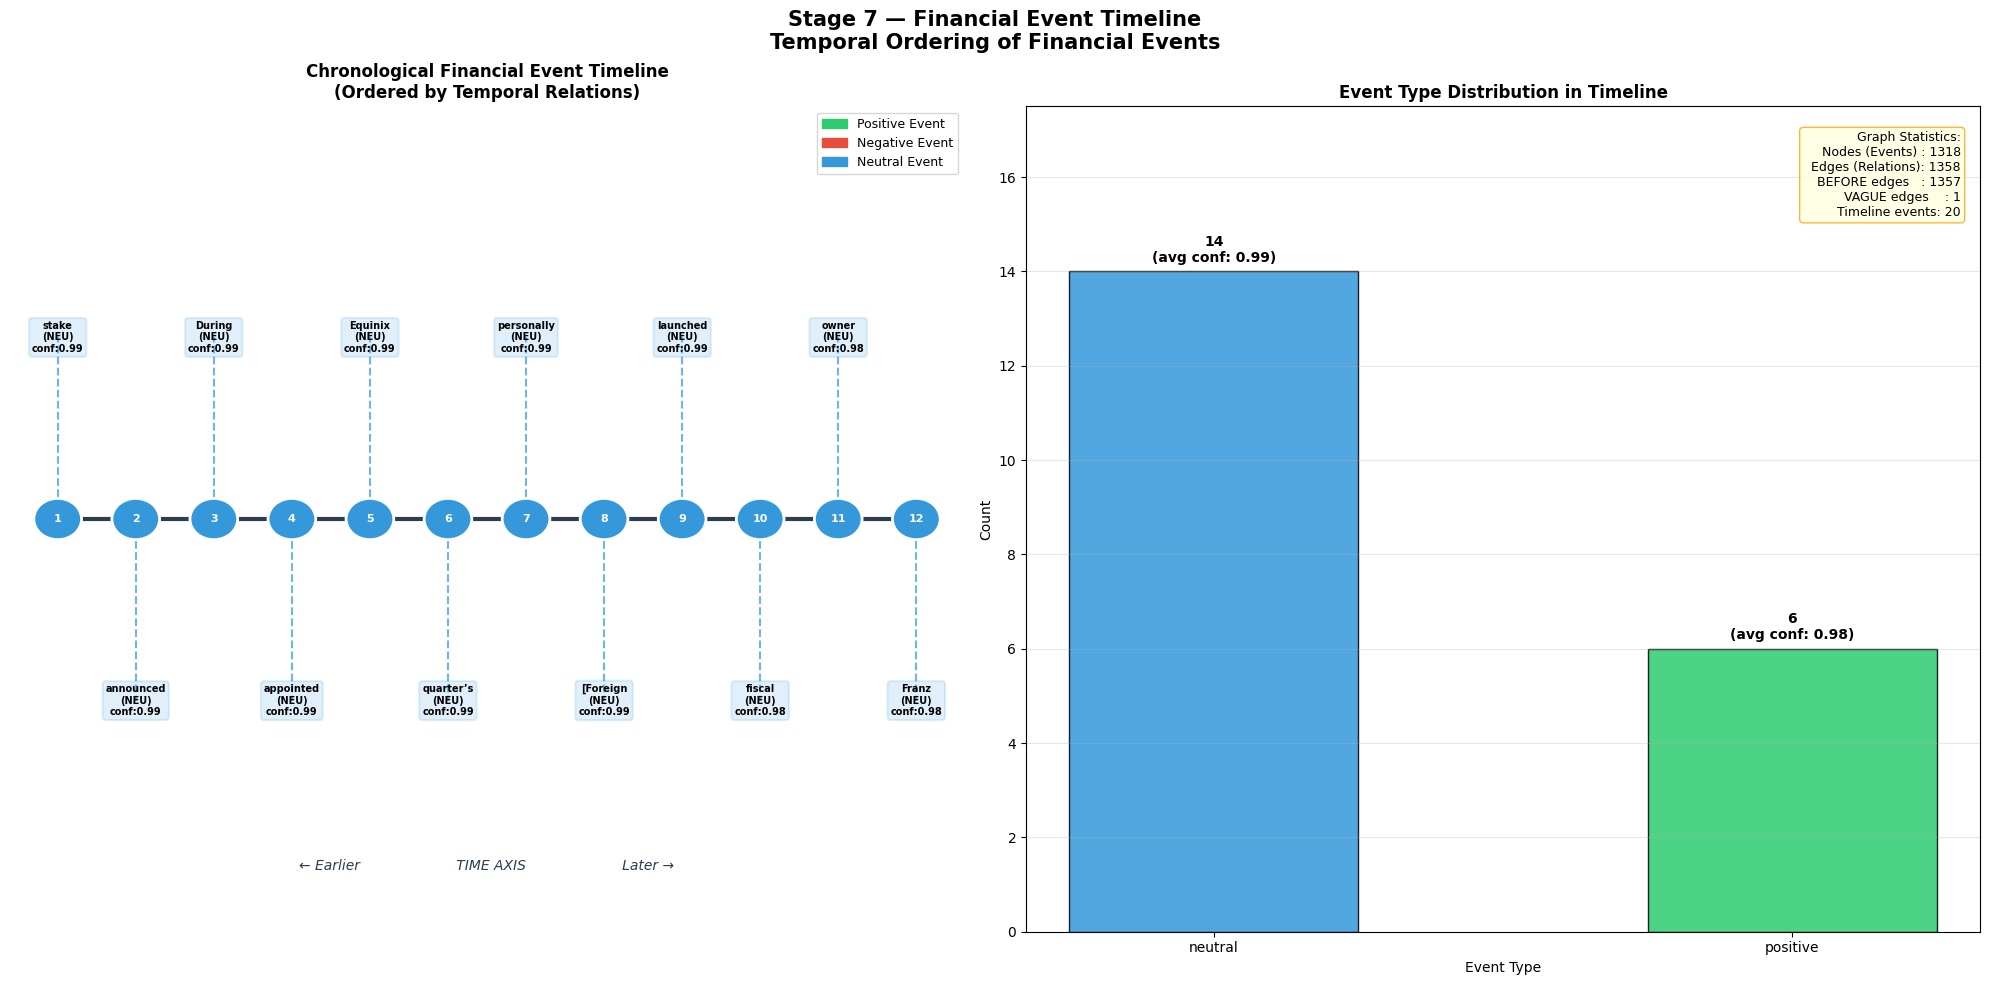

✅ Timeline visualization saved!


In [ ]:
# ============================================================
# CELL 59 — Financial Timeline Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(
    'Stage 7 — Financial Event Timeline\n'
    'Temporal Ordering of Financial Events',
    fontsize=15, fontweight='bold'
)

# ── Plot 1: Horizontal Timeline ──────────────────────────────
ax = axes[0]
show_events = timeline_df.head(12)
n_events    = len(show_events)

# Color mapping for event types
color_map = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral' : '#3498db'
}

# Draw timeline axis
ax.axhline(y=0.5, xmin=0.05, xmax=0.95,
           color='#2c3e50', lw=3, zorder=1)

# Draw events on timeline
for i, (_, row) in enumerate(show_events.iterrows()):
    x_pos  = 0.05 + (i / max(n_events - 1, 1)) * 0.90
    color  = color_map.get(row['event_type'], '#95a5a6')
    y_node = 0.5

    # Alternate event labels above/below timeline
    y_text = 0.72 if i % 2 == 0 else 0.28
    y_line = [y_node, y_text]

    # Connector line
    ax.plot([x_pos, x_pos], y_line,
            color=color, lw=1.5,
            linestyle='--', alpha=0.7, zorder=2)

    # Event circle
    circle = plt.Circle(
        (x_pos, y_node), 0.025,
        color=color, zorder=4,
        ec='white', lw=2
    )
    ax.add_patch(circle)

    # Event number inside circle
    ax.text(x_pos, y_node, str(row['position']),
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='white', zorder=5)

    # Event label box
    bbox_props = dict(
        boxstyle='round,pad=0.3',
        facecolor=color, alpha=0.15,
        edgecolor=color, lw=1.5
    )
    ax.text(x_pos, y_text,
            f"{row['event']}\n"
            f"({row['event_type'][:3].upper()})\n"
            f"conf:{row['confidence']:.2f}",
            ha='center', va='center',
            fontsize=7, fontweight='bold',
            bbox=bbox_props, zorder=3)

# Timeline label
ax.text(0.5, 0.08, '← Earlier                      '
        'TIME AXIS                      Later →',
        ha='center', va='center',
        transform=ax.transAxes,
        fontsize=10, color='#2c3e50',
        style='italic')

# Legend
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Positive Event'),
    mpatches.Patch(color='#e74c3c', label='Negative Event'),
    mpatches.Patch(color='#3498db', label='Neutral Event')
]
ax.legend(handles=legend_patches,
          loc='upper right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Chronological Financial Event Timeline\n'
             '(Ordered by Temporal Relations)',
             fontweight='bold', fontsize=12)

# ── Plot 2: Event Type Distribution in Timeline ──────────────
ax2 = axes[1]

# Summary stats
type_counts = timeline_df['event_type'].value_counts()
conf_by_type = timeline_df.groupby(
    'event_type')['confidence'].mean()

x_pos  = np.arange(len(type_counts))
colors = [color_map.get(t, '#95a5a6')
          for t in type_counts.index]

bars = ax2.bar(
    type_counts.index, type_counts.values,
    color=colors, edgecolor='black',
    alpha=0.85, width=0.5
)
ax2.set_title('Event Type Distribution in Timeline',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Event Type')
ax2.set_ylabel('Count')
ax2.set_ylim(0, max(type_counts.values) * 1.25)
ax2.grid(axis='y', alpha=0.3)

for bar, (etype, count) in zip(bars, type_counts.items()):
    avg_conf = conf_by_type.get(etype, 0)
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{count}\n(avg conf: {avg_conf:.2f})',
        ha='center', fontweight='bold', fontsize=10
    )

# Add graph statistics as text box
stats_text = (
    f"Graph Statistics:\n"
    f"  Nodes (Events) : {graph.num_nodes}\n"
    f"  Edges (Relations): {graph.num_edges}\n"
    f"  BEFORE edges   : "
    f"{sum(1 for e in graph.edges if e['relation']=='BEFORE')}\n"
    f"  VAGUE edges    : "
    f"{sum(1 for e in graph.edges if e['relation']=='VAGUE')}\n"
    f"  Timeline events: {len(timeline_df)}"
)
ax2.text(
    0.98, 0.97, stats_text,
    transform=ax2.transAxes,
    fontsize=9, verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.8, edgecolor='orange')
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage7_timeline.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Timeline visualization saved!")

In [ ]:
# ============================================================
# CELL 60 — Save Stage 7 Results & Final Summary
# ============================================================

# Save timeline
timeline_df.to_csv(
    os.path.join(OUTPUT_DIR, 'stage7_timeline.csv'),
    index=False
)

# Save graph as JSON
graph_data = {
    'nodes': list(graph.nodes.values()),
    'edges': graph.edges,
    'timeline_order': timeline_order[:20]
}
with open(os.path.join(OUTPUT_DIR,
                       'stage7_graph.json'), 'w') as f:
    json.dump(graph_data, f, indent=4)

# Stage 7 metrics
stage7_metrics = {
    'stage'         : 'Stage 7 - Financial Timeline Construction',
    'graph_nodes'   : graph.num_nodes,
    'graph_edges'   : graph.num_edges,
    'before_edges'  : sum(
        1 for e in graph.edges if e['relation'] == 'BEFORE'
    ),
    'vague_edges'   : sum(
        1 for e in graph.edges if e['relation'] == 'VAGUE'
    ),
    'timeline_events': len(timeline_df),
    'event_type_dist': timeline_df[
        'event_type'
    ].value_counts().to_dict(),
    'avg_confidence': round(
        float(timeline_df['confidence'].mean()), 4
    )
}

with open(os.path.join(OUTPUT_DIR,
                       'stage7_metrics.json'), 'w') as f:
    json.dump(stage7_metrics, f, indent=4)

print("💾 Stage 7 results saved!")
print("\n" + "=" * 65)
print("✅  STAGE 6 + 7 — FINAL SUMMARY")
print("=" * 65)
print(f"""
⚡ STAGE 6 — PARALLEL NLP PIPELINE (PDC)
   Workers      : {NUM_WORKERS}
   Method       : ThreadPoolExecutor (concurrent.futures)
   Pipeline     : Clean→Tokenize→POS→Events→NER
   Avg Speedup  : {np.mean(speedup_all):.2f}x
   Max Speedup  : {max(speedup_all):.2f}x
   Best batch   : {BATCH_SIZES[np.argmax(speedup_all)]} docs

🗓️  STAGE 7 — FINANCIAL TIMELINE CONSTRUCTION
   Graph nodes  : {graph.num_nodes:,}
   Graph edges  : {graph.num_edges:,}
   BEFORE edges : {sum(1 for e in graph.edges if e['relation']=='BEFORE'):,}
   VAGUE edges  : {sum(1 for e in graph.edges if e['relation']=='VAGUE'):,}
   Timeline     : {len(timeline_df)} events ordered

📁 ALL OUTPUT FILES:
   stage6_pdc_performance.png
   stage6_scalability.png
   stage6_benchmark.csv
   stage6_metrics.json
   stage7_timeline.png
   stage7_timeline.csv
   stage7_graph.json
   stage7_metrics.json

🔜 NEXT → Stage 8: Final Evaluation & Research Paper
""")

💾 Stage 7 results saved!

✅  STAGE 6 + 7 — FINAL SUMMARY

⚡ STAGE 6 — PARALLEL NLP PIPELINE (PDC)
   Workers      : 2
   Method       : ThreadPoolExecutor (concurrent.futures)
   Pipeline     : Clean→Tokenize→POS→Events→NER
   Avg Speedup  : 1.00x
   Max Speedup  : 1.47x
   Best batch   : 500 docs

🗓️  STAGE 7 — FINANCIAL TIMELINE CONSTRUCTION
   Graph nodes  : 1,318
   Graph edges  : 1,358
   BEFORE edges : 1,357
   VAGUE edges  : 1
   Timeline     : 20 events ordered

📁 ALL OUTPUT FILES:
   stage6_pdc_performance.png
   stage6_scalability.png
   stage6_benchmark.csv
   stage6_metrics.json
   stage7_timeline.png
   stage7_timeline.csv
   stage7_graph.json
   stage7_metrics.json

🔜 NEXT → Stage 8: Final Evaluation & Research Paper



# Stage 8

In [ ]:
# ============================================================
# CELL 61 — Stage 8 Imports & Setup
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score, accuracy_score,
    precision_score, recall_score
)

OUTPUT_DIR = '/content/financial_nlp_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Stage 8 setup complete!")
print(f"   Output dir : {OUTPUT_DIR}")

✅ Stage 8 setup complete!
   Output dir : /content/financial_nlp_output


In [ ]:
# ============================================================
# CELL 62 — Collect All Results From All Stages
# ============================================================

# ── Stage 3: Event Detection Results ────────────────────────
event_results = {
    'accuracy'        : test_acc,
    'f1'              : test_f1,
    'precision'       : test_prec,
    'recall'          : test_rec,
    'binary_accuracy' : bin_acc,
    'binary_f1'       : bin_f1,
    'binary_precision': bin_prec,
    'binary_recall'   : bin_rec,
    'train_time_min'  : event_train_time / 60,
    'train_samples'   : len(train_event_ds),
    'test_samples'    : len(test_event_ds),
    'epochs'          : EPOCHS_EVENT
}

# ── Stage 5: Temporal Relation Results ──────────────────────
temporal_results_dict = {
    'accuracy'     : acc_t,
    'f1'           : f1_t,
    'precision'    : prec_t,
    'recall'       : rec_t,
    'train_time_min': temp_train_time / 60,
    'train_samples' : len(train_temp_ds),
    'test_samples'  : len(test_temp_ds),
    'epochs'        : EPOCHS_TEMP,
    'labels'        : TEMPORAL_LABEL_NAMES,
    'per_class_f1'  : {
        label: round(float(per_class_f1[i]), 4)
        for i, label in enumerate(TEMPORAL_LABEL_NAMES)
    },
    'per_class_prec': {
        label: round(float(per_class_prec[i]), 4)
        for i, label in enumerate(TEMPORAL_LABEL_NAMES)
    },
    'per_class_rec' : {
        label: round(float(per_class_rec[i]), 4)
        for i, label in enumerate(TEMPORAL_LABEL_NAMES)
    }
}

# ── Stage 4: Event Linking Results ──────────────────────────
linking_results = {
    'total_sentences'   : len(stage4_sents),
    'linked_pairs'      : len(linked_df),
    'event_pairs'       : len(event_linked_df),
    'avg_cosine_sim'    : round(
        float(linked_df['cosine_sim'].mean()), 4
    ) if len(linked_df) > 0 else 0,
    'avg_relevance'     : round(
        float(linked_df['relevance_score'].mean()), 4
    ) if len(linked_df) > 0 else 0,
    'sim_threshold'     : 0.70,
    'window_size'       : 3
}

# ── Stage 6: PDC Results ────────────────────────────────────
pdc_results = {
    'num_workers'    : NUM_WORKERS,
    'avg_speedup'    : round(float(np.mean(speedup_all)), 4),
    'max_speedup'    : round(float(max(speedup_all)), 4),
    'min_speedup'    : round(float(min(speedup_all)), 4),
    'batch_sizes'    : BATCH_SIZES,
    'seq_times'      : [round(t, 4) for t in seq_times_all],
    'par_times'      : [round(t, 4) for t in par_times_all],
    'speedups'       : [round(s, 4) for s in speedup_all],
    'seq_cpu_avgs'   : [round(c, 2) for c in seq_cpu_avgs],
    'par_cpu_avgs'   : [round(c, 2) for c in par_cpu_avgs]
}

# ── Stage 7: Timeline Results ────────────────────────────────
timeline_results = {
    'graph_nodes'    : graph.num_nodes,
    'graph_edges'    : graph.num_edges,
    'before_edges'   : sum(
        1 for e in graph.edges if e['relation'] == 'BEFORE'
    ),
    'vague_edges'    : sum(
        1 for e in graph.edges if e['relation'] == 'VAGUE'
    ),
    'timeline_events': len(timeline_df),
    'avg_confidence' : round(
        float(timeline_df['confidence'].mean()), 4
    )
}

print("✅ All stage results collected!")
print(f"\n📊 Quick Summary:")
print(f"   Event Detection  → Acc:{event_results['accuracy']:.4f} "
      f"F1:{event_results['f1']:.4f}")
print(f"   Temporal Classif → Acc:{temporal_results_dict['accuracy']:.4f} "
      f"F1:{temporal_results_dict['f1']:.4f}")
print(f"   Event Linking    → {linking_results['linked_pairs']:,} pairs")
print(f"   PDC Speedup      → Avg:{pdc_results['avg_speedup']:.2f}x "
      f"Max:{pdc_results['max_speedup']:.2f}x")
print(f"   Timeline         → {timeline_results['graph_nodes']:,} events")

✅ All stage results collected!

📊 Quick Summary:
   Event Detection  → Acc:0.8786 F1:0.8783
   Temporal Classif → Acc:0.7075 F1:0.6643
   Event Linking    → 3,817 pairs
   PDC Speedup      → Avg:1.00x Max:1.47x
   Timeline         → 1,318 events


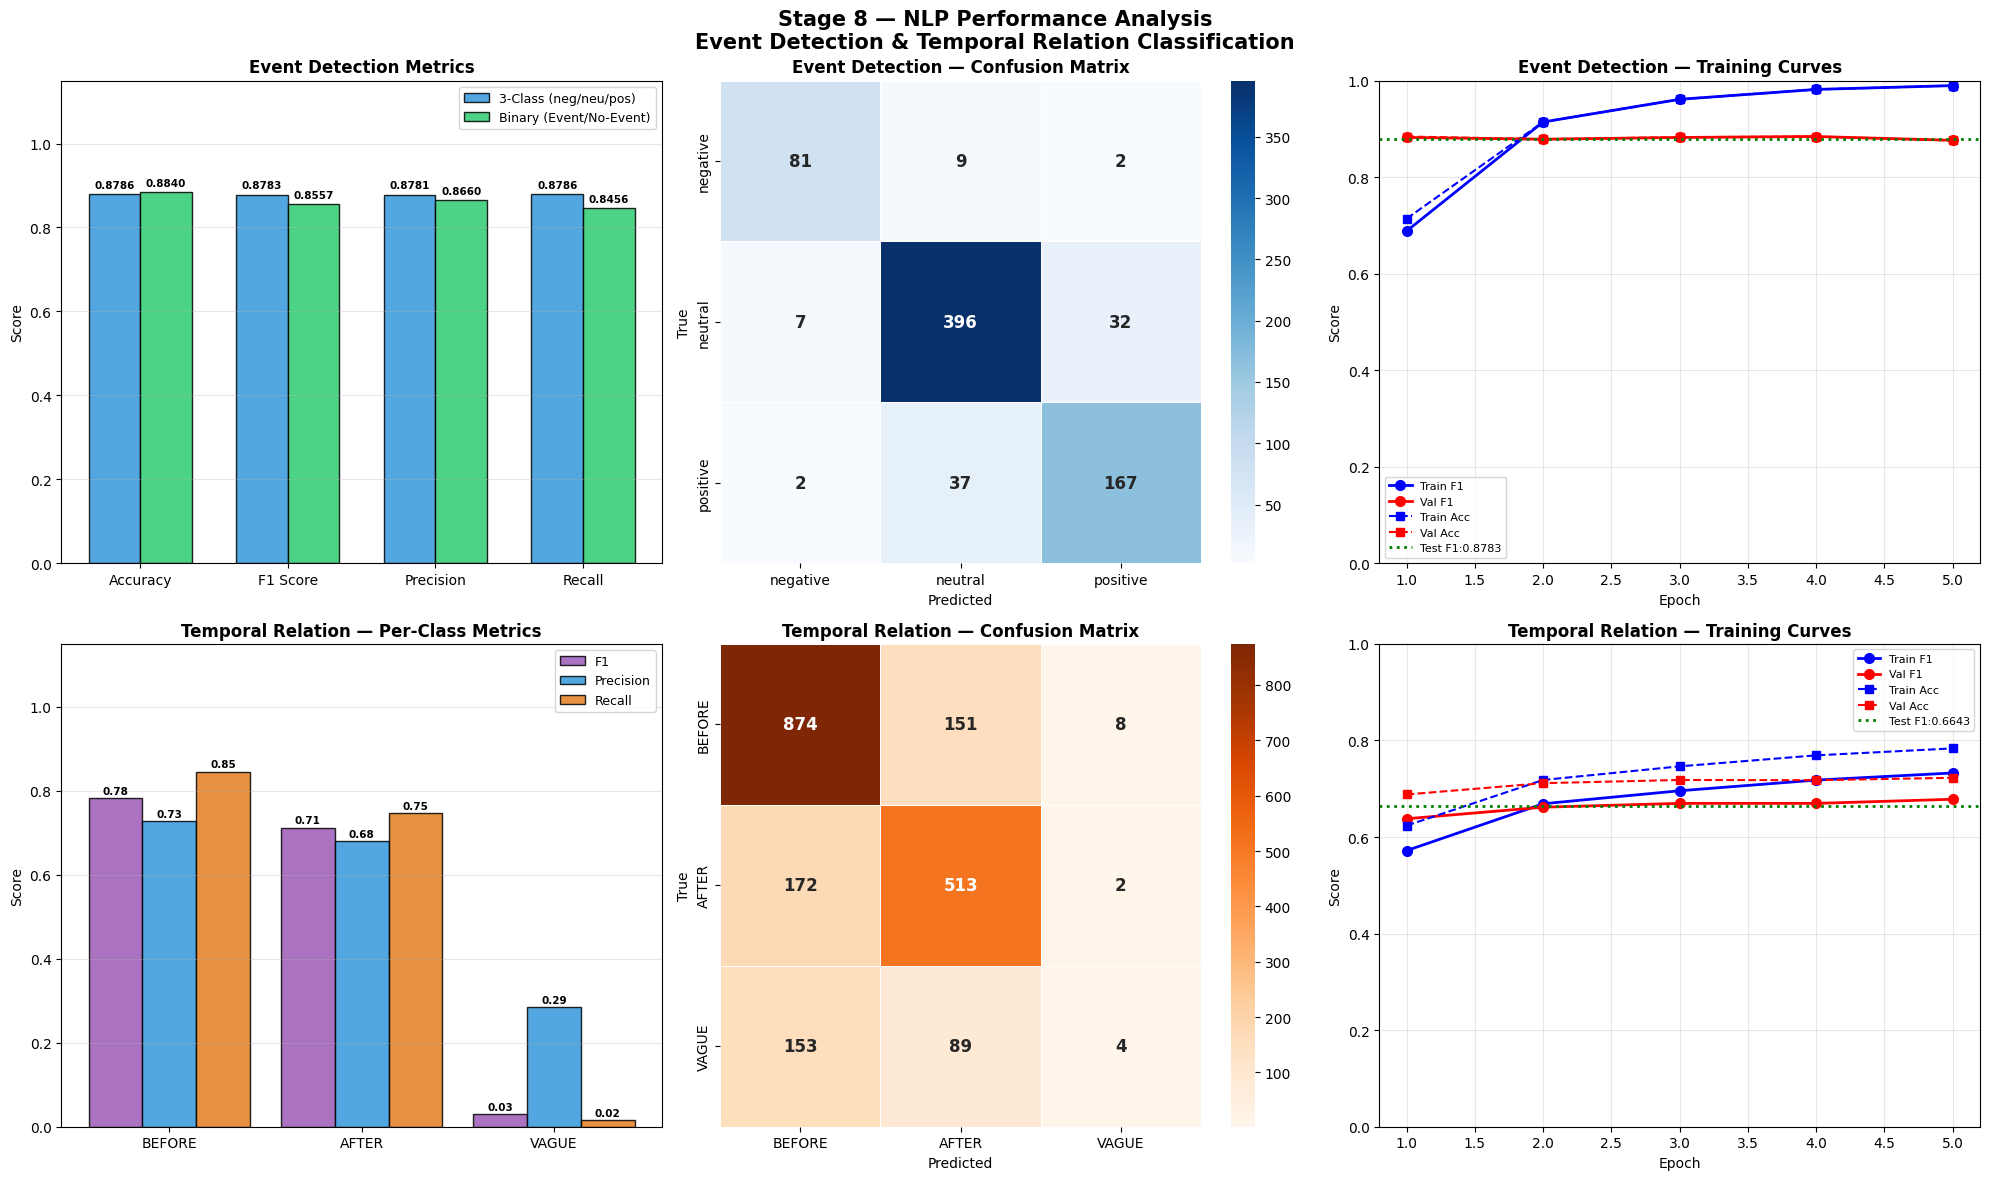

✅ NLP performance analysis saved!


In [ ]:
# ============================================================
# CELL 63 — NLP Performance Analysis
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'Stage 8 — NLP Performance Analysis\n'
    'Event Detection & Temporal Relation Classification',
    fontsize=15, fontweight='bold'
)

# ── Plot 1: Event Detection — Overall Metrics ────────────────
metrics_ed   = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
vals_3class  = [
    event_results['accuracy'],
    event_results['f1'],
    event_results['precision'],
    event_results['recall']
]
vals_binary  = [
    event_results['binary_accuracy'],
    event_results['binary_f1'],
    event_results['binary_precision'],
    event_results['binary_recall']
]
x      = np.arange(len(metrics_ed))
width  = 0.35
bars1a = axes[0,0].bar(
    x - width/2, vals_3class, width,
    label='3-Class (neg/neu/pos)',
    color='#3498db', edgecolor='black', alpha=0.85
)
bars1b = axes[0,0].bar(
    x + width/2, vals_binary, width,
    label='Binary (Event/No-Event)',
    color='#2ecc71', edgecolor='black', alpha=0.85
)
axes[0,0].set_title('Event Detection Metrics',
                    fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Score')
axes[0,0].set_ylim(0, 1.15)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics_ed)
axes[0,0].legend(fontsize=9)
axes[0,0].grid(axis='y', alpha=0.3)
for bar in list(bars1a) + list(bars1b):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom',
        fontsize=7.5, fontweight='bold'
    )

# ── Plot 2: Event Detection Confusion Matrix ─────────────────
cm_ev = confusion_matrix(event_true, event_preds)
sns.heatmap(
    cm_ev, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
    linewidths=0.5, ax=axes[0,1],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0,1].set_title('Event Detection — Confusion Matrix',
                    fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('True')
axes[0,1].set_xlabel('Predicted')

# ── Plot 3: Event Detection Training Curves ──────────────────
epochs_e = range(1, EPOCHS_EVENT + 1)
axes[0,2].plot(epochs_e, event_history['train_f1'],
               'b-o', lw=2, ms=7, label='Train F1')
axes[0,2].plot(epochs_e, event_history['val_f1'],
               'r-o', lw=2, ms=7, label='Val F1')
axes[0,2].plot(epochs_e, event_history['train_acc'],
               'b--s', lw=1.5, ms=6, label='Train Acc')
axes[0,2].plot(epochs_e, event_history['val_acc'],
               'r--s', lw=1.5, ms=6, label='Val Acc')
axes[0,2].axhline(
    event_results['f1'], color='green',
    linestyle=':', lw=2,
    label=f"Test F1:{event_results['f1']:.4f}"
)
axes[0,2].set_title('Event Detection — Training Curves',
                    fontweight='bold', fontsize=12)
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Score')
axes[0,2].set_ylim(0, 1)
axes[0,2].legend(fontsize=8)
axes[0,2].grid(True, alpha=0.3)

# ── Plot 4: Temporal — Per-Class Metrics ─────────────────────
x_t     = np.arange(len(TEMPORAL_LABEL_NAMES))
width_t = 0.28
axes[1,0].bar(
    x_t - width_t, per_class_f1,
    width_t, label='F1',
    color='#9b59b6', edgecolor='black', alpha=0.85
)
axes[1,0].bar(
    x_t, per_class_prec,
    width_t, label='Precision',
    color='#3498db', edgecolor='black', alpha=0.85
)
axes[1,0].bar(
    x_t + width_t, per_class_rec,
    width_t, label='Recall',
    color='#e67e22', edgecolor='black', alpha=0.85
)
axes[1,0].set_title('Temporal Relation — Per-Class Metrics',
                    fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Score')
axes[1,0].set_ylim(0, 1.15)
axes[1,0].set_xticks(x_t)
axes[1,0].set_xticklabels(TEMPORAL_LABEL_NAMES)
axes[1,0].legend(fontsize=9)
axes[1,0].grid(axis='y', alpha=0.3)
for i, (f1v, pv, rv) in enumerate(
    zip(per_class_f1, per_class_prec, per_class_rec)
):
    axes[1,0].text(i - width_t, f1v + 0.01,
                   f'{f1v:.2f}', ha='center',
                   fontsize=7.5, fontweight='bold')
    axes[1,0].text(i, pv + 0.01,
                   f'{pv:.2f}', ha='center',
                   fontsize=7.5, fontweight='bold')
    axes[1,0].text(i + width_t, rv + 0.01,
                   f'{rv:.2f}', ha='center',
                   fontsize=7.5, fontweight='bold')

# ── Plot 5: Temporal Confusion Matrix ────────────────────────
cm_t = confusion_matrix(test_true, test_preds_stage5)
sns.heatmap(
    cm_t, annot=True, fmt='d', cmap='Oranges',
    xticklabels=TEMPORAL_LABEL_NAMES,
    yticklabels=TEMPORAL_LABEL_NAMES,
    linewidths=0.5, ax=axes[1,1],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[1,1].set_title('Temporal Relation — Confusion Matrix',
                    fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('True')
axes[1,1].set_xlabel('Predicted')

# ── Plot 6: Temporal Training Curves ─────────────────────────
epochs_t = range(1, EPOCHS_TEMP + 1)
axes[1,2].plot(epochs_t, temporal_history['train_f1'],
               'b-o', lw=2, ms=7, label='Train F1')
axes[1,2].plot(epochs_t, temporal_history['val_f1'],
               'r-o', lw=2, ms=7, label='Val F1')
axes[1,2].plot(epochs_t, temporal_history['train_acc'],
               'b--s', lw=1.5, ms=6, label='Train Acc')
axes[1,2].plot(epochs_t, temporal_history['val_acc'],
               'r--s', lw=1.5, ms=6, label='Val Acc')
axes[1,2].axhline(
    temporal_results_dict['f1'], color='green',
    linestyle=':', lw=2,
    label=f"Test F1:{temporal_results_dict['f1']:.4f}"
)
axes[1,2].set_title('Temporal Relation — Training Curves',
                    fontweight='bold', fontsize=12)
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_ylabel('Score')
axes[1,2].set_ylim(0, 1)
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage8_nlp_performance.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ NLP performance analysis saved!")

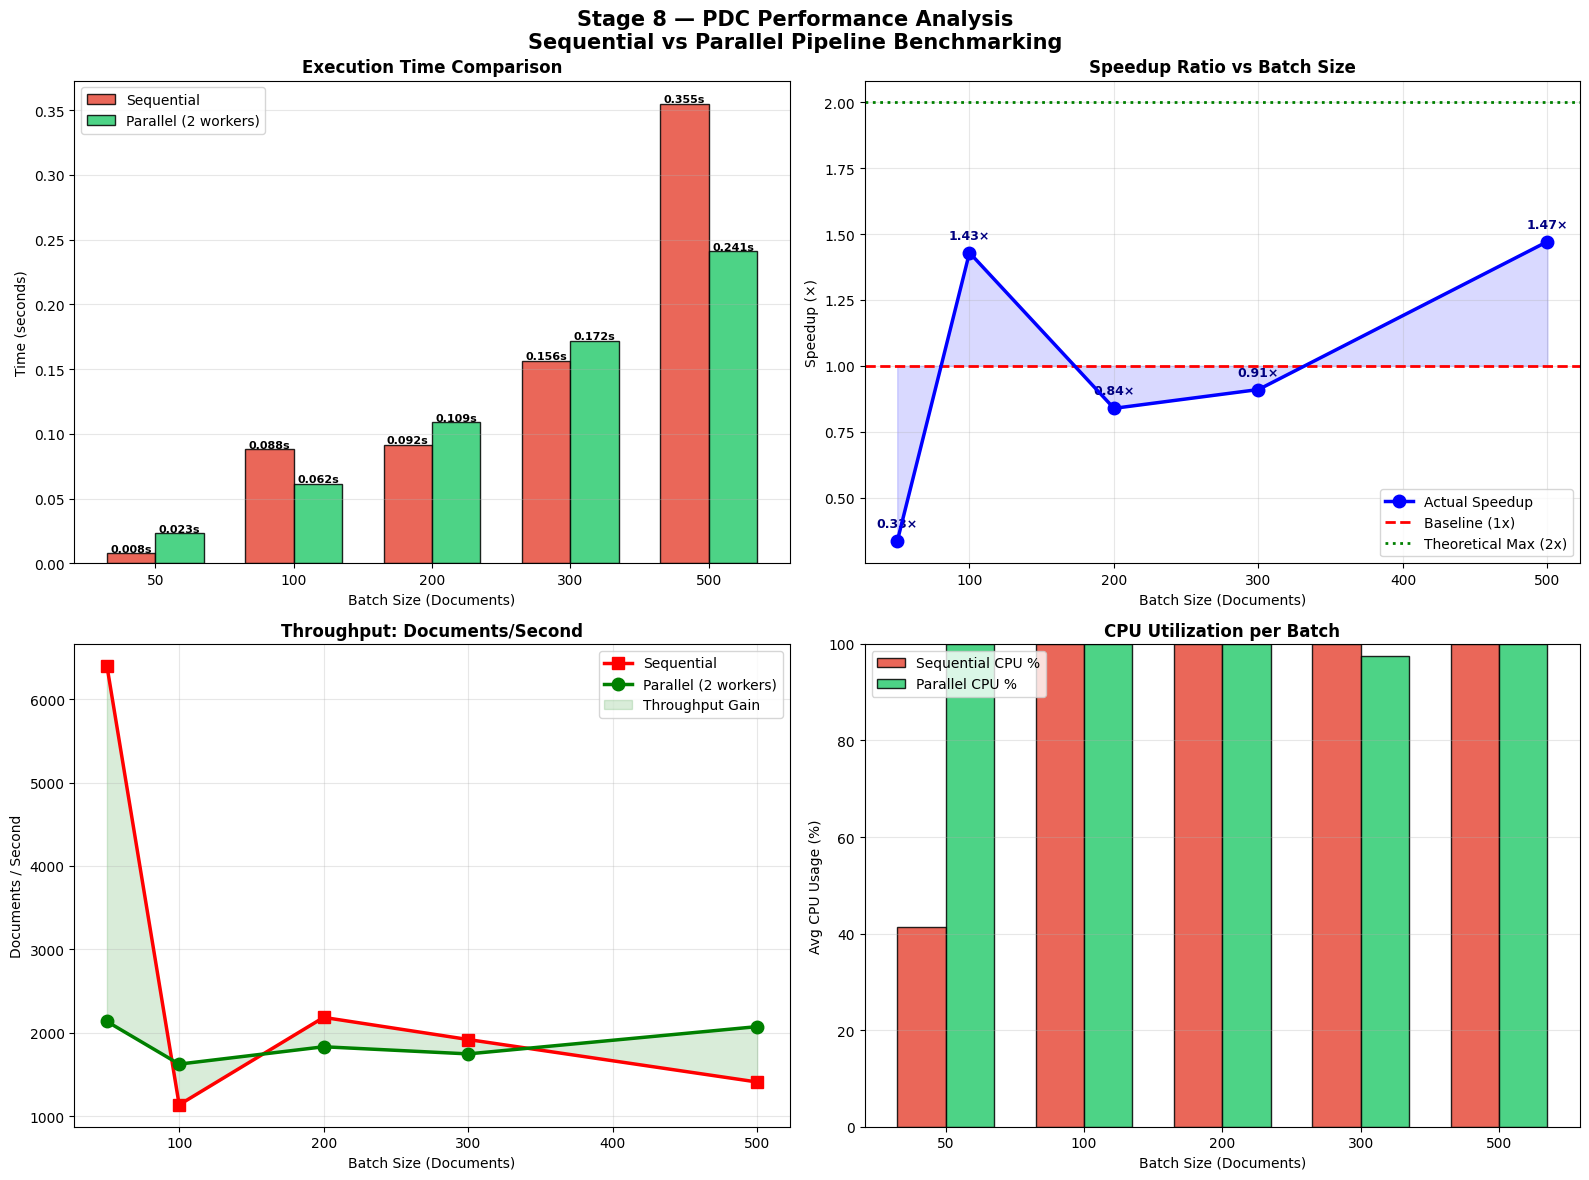

✅ PDC analysis saved!


In [ ]:
# ============================================================
# CELL 64 — PDC Performance Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Stage 8 — PDC Performance Analysis\n'
    'Sequential vs Parallel Pipeline Benchmarking',
    fontsize=15, fontweight='bold'
)

# ── Plot 1: Execution Time ───────────────────────────────────
x     = np.arange(len(BATCH_SIZES))
width = 0.35
b1    = axes[0,0].bar(
    x - width/2, seq_times_all, width,
    label='Sequential', color='#e74c3c',
    edgecolor='black', alpha=0.85
)
b2    = axes[0,0].bar(
    x + width/2, par_times_all, width,
    label=f'Parallel ({NUM_WORKERS} workers)',
    color='#2ecc71', edgecolor='black', alpha=0.85
)
axes[0,0].set_title('Execution Time Comparison',
                    fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Batch Size (Documents)')
axes[0,0].set_ylabel('Time (seconds)')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(BATCH_SIZES)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        h + 0.001, f'{h:.3f}s',
        ha='center', fontsize=8, fontweight='bold'
    )

# ── Plot 2: Speedup Ratio ────────────────────────────────────
axes[0,1].plot(
    BATCH_SIZES, speedup_all,
    'b-o', lw=2.5, ms=9,
    label='Actual Speedup', zorder=5
)
axes[0,1].axhline(
    1.0, color='red', linestyle='--',
    lw=2, label='Baseline (1x)'
)
axes[0,1].axhline(
    NUM_WORKERS, color='green',
    linestyle=':', lw=2,
    label=f'Theoretical Max ({NUM_WORKERS}x)'
)
axes[0,1].fill_between(
    BATCH_SIZES, 1.0, speedup_all,
    alpha=0.15, color='blue'
)
axes[0,1].set_title('Speedup Ratio vs Batch Size',
                    fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Batch Size (Documents)')
axes[0,1].set_ylabel('Speedup (×)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
for xv, yv in zip(BATCH_SIZES, speedup_all):
    axes[0,1].annotate(
        f'{yv:.2f}×',
        (xv, yv), textcoords="offset points",
        xytext=(0, 10), ha='center',
        fontsize=9, fontweight='bold', color='navy'
    )

# ── Plot 3: Throughput ───────────────────────────────────────
seq_thr = [b/t for b, t in zip(BATCH_SIZES, seq_times_all)]
par_thr = [b/t for b, t in zip(BATCH_SIZES, par_times_all)]
axes[1,0].plot(
    BATCH_SIZES, seq_thr, 'r-s',
    lw=2.5, ms=9, label='Sequential'
)
axes[1,0].plot(
    BATCH_SIZES, par_thr, 'g-o',
    lw=2.5, ms=9, label=f'Parallel ({NUM_WORKERS} workers)'
)
axes[1,0].fill_between(
    BATCH_SIZES, seq_thr, par_thr,
    alpha=0.15, color='green',
    label='Throughput Gain'
)
axes[1,0].set_title('Throughput: Documents/Second',
                    fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Batch Size (Documents)')
axes[1,0].set_ylabel('Documents / Second')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ── Plot 4: CPU Utilization ──────────────────────────────────
x_c   = np.arange(len(BATCH_SIZES))
axes[1,1].bar(
    x_c - width/2, seq_cpu_avgs, width,
    label='Sequential CPU %',
    color='#e74c3c', edgecolor='black', alpha=0.85
)
axes[1,1].bar(
    x_c + width/2, par_cpu_avgs, width,
    label='Parallel CPU %',
    color='#2ecc71', edgecolor='black', alpha=0.85
)
axes[1,1].set_title('CPU Utilization per Batch',
                    fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Batch Size (Documents)')
axes[1,1].set_ylabel('Avg CPU Usage (%)')
axes[1,1].set_xticks(x_c)
axes[1,1].set_xticklabels(BATCH_SIZES)
axes[1,1].set_ylim(0, 100)
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage8_pdc_analysis.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ PDC analysis saved!")

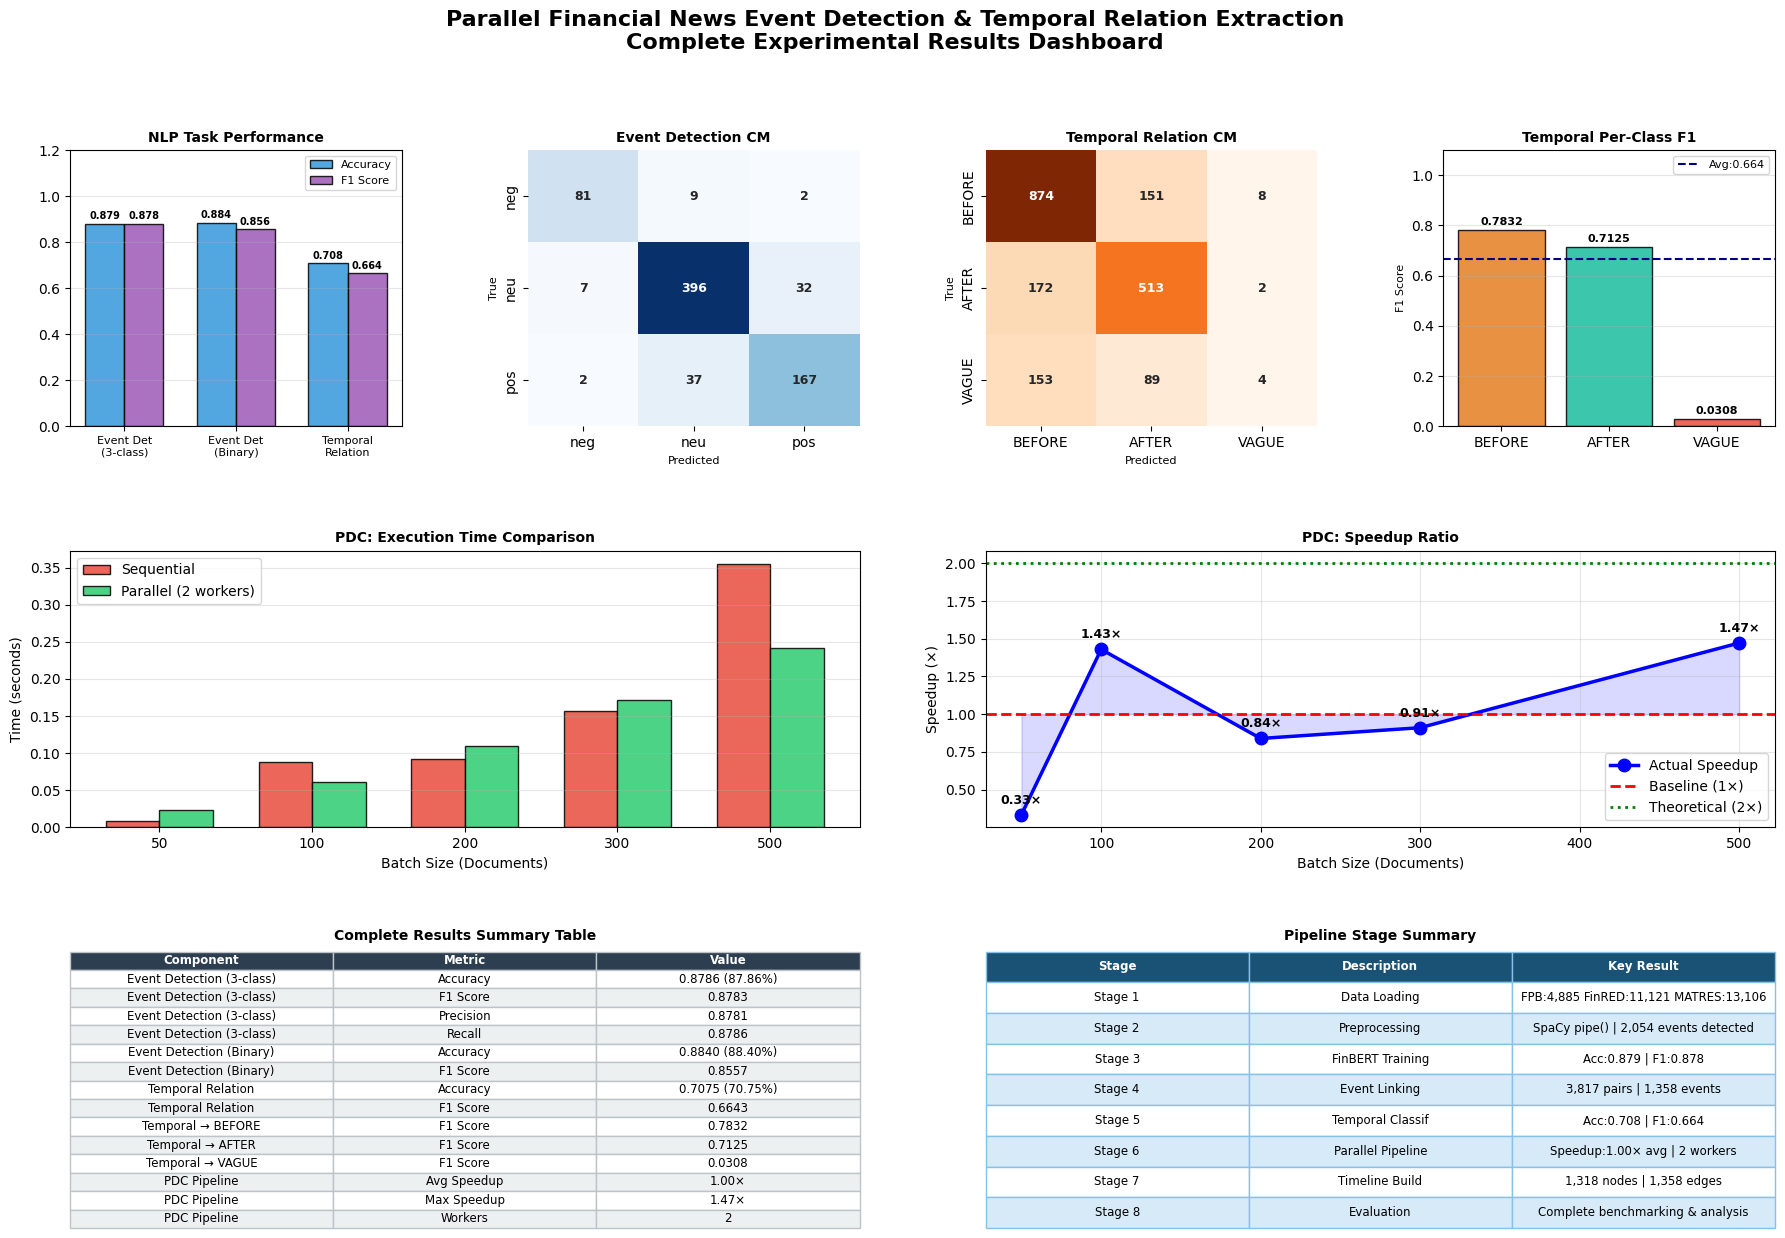

✅ Complete dashboard saved!


In [ ]:
# ============================================================
# CELL 65 — Complete Results Dashboard (1 figure)
# ============================================================

fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    'Parallel Financial News Event Detection & '
    'Temporal Relation Extraction\n'
    'Complete Experimental Results Dashboard',
    fontsize=16, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(
    3, 4, figure=fig,
    hspace=0.45, wspace=0.38
)

# ── Panel 1: NLP Metrics Summary Bar ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
tasks  = ['Event Det\n(3-class)', 'Event Det\n(Binary)',
          'Temporal\nRelation']
accs   = [event_results['accuracy'],
          event_results['binary_accuracy'],
          temporal_results_dict['accuracy']]
f1s    = [event_results['f1'],
          event_results['binary_f1'],
          temporal_results_dict['f1']]
x_m    = np.arange(len(tasks))
width_m = 0.35
ax1.bar(x_m - width_m/2, accs, width_m,
        label='Accuracy', color='#3498db',
        edgecolor='black', alpha=0.85)
ax1.bar(x_m + width_m/2, f1s, width_m,
        label='F1 Score', color='#9b59b6',
        edgecolor='black', alpha=0.85)
ax1.set_title('NLP Task Performance',
              fontweight='bold', fontsize=10)
ax1.set_ylim(0, 1.2)
ax1.set_xticks(x_m)
ax1.set_xticklabels(tasks, fontsize=8)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax1.text(i - width_m/2, a + 0.02,
             f'{a:.3f}', ha='center',
             fontsize=7, fontweight='bold')
    ax1.text(i + width_m/2, f + 0.02,
             f'{f:.3f}', ha='center',
             fontsize=7, fontweight='bold')

# ── Panel 2: Event Detection CM ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(
    confusion_matrix(event_true, event_preds),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['neg', 'neu', 'pos'],
    yticklabels=['neg', 'neu', 'pos'],
    ax=ax2, cbar=False,
    annot_kws={"size": 9, "weight": "bold"}
)
ax2.set_title('Event Detection CM',
              fontweight='bold', fontsize=10)
ax2.set_ylabel('True', fontsize=8)
ax2.set_xlabel('Predicted', fontsize=8)

# ── Panel 3: Temporal CM ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(
    confusion_matrix(test_true, test_preds_stage5),
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=TEMPORAL_LABEL_NAMES,
    yticklabels=TEMPORAL_LABEL_NAMES,
    ax=ax3, cbar=False,
    annot_kws={"size": 9, "weight": "bold"}
)
ax3.set_title('Temporal Relation CM',
              fontweight='bold', fontsize=10)
ax3.set_ylabel('True', fontsize=8)
ax3.set_xlabel('Predicted', fontsize=8)

# ── Panel 4: Per-Class Temporal F1 ──────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
colors_c = ['#e67e22', '#1abc9c', '#e74c3c']
bars_c   = ax4.bar(
    TEMPORAL_LABEL_NAMES, per_class_f1,
    color=colors_c[:len(TEMPORAL_LABEL_NAMES)],
    edgecolor='black', alpha=0.85
)
ax4.set_title('Temporal Per-Class F1',
              fontweight='bold', fontsize=10)
ax4.set_ylabel('F1 Score', fontsize=8)
ax4.set_ylim(0, 1.1)
ax4.axhline(temporal_results_dict['f1'],
            color='navy', linestyle='--',
            lw=1.5,
            label=f"Avg:{temporal_results_dict['f1']:.3f}")
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars_c, per_class_f1):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.4f}', ha='center',
        fontsize=8, fontweight='bold'
    )

# ── Panel 5: PDC Execution Time ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 0:2])
x_p   = np.arange(len(BATCH_SIZES))
w_p   = 0.35
ax5.bar(x_p - w_p/2, seq_times_all, w_p,
        label='Sequential', color='#e74c3c',
        edgecolor='black', alpha=0.85)
ax5.bar(x_p + w_p/2, par_times_all, w_p,
        label=f'Parallel ({NUM_WORKERS} workers)',
        color='#2ecc71', edgecolor='black', alpha=0.85)
ax5.set_title('PDC: Execution Time Comparison',
              fontweight='bold', fontsize=10)
ax5.set_xlabel('Batch Size (Documents)')
ax5.set_ylabel('Time (seconds)')
ax5.set_xticks(x_p)
ax5.set_xticklabels(BATCH_SIZES)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# ── Panel 6: Speedup Ratio ───────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2:4])
ax6.plot(BATCH_SIZES, speedup_all, 'b-o',
         lw=2.5, ms=9, label='Actual Speedup')
ax6.axhline(1.0, color='red', linestyle='--',
            lw=2, label='Baseline (1×)')
ax6.axhline(NUM_WORKERS, color='green',
            linestyle=':', lw=2,
            label=f'Theoretical ({NUM_WORKERS}×)')
ax6.fill_between(BATCH_SIZES, 1.0, speedup_all,
                 alpha=0.15, color='blue')
ax6.set_title('PDC: Speedup Ratio',
              fontweight='bold', fontsize=10)
ax6.set_xlabel('Batch Size (Documents)')
ax6.set_ylabel('Speedup (×)')
ax6.legend()
ax6.grid(True, alpha=0.3)
for xv, yv in zip(BATCH_SIZES, speedup_all):
    ax6.annotate(f'{yv:.2f}×', (xv, yv),
                 textcoords="offset points",
                 xytext=(0, 8), ha='center',
                 fontsize=9, fontweight='bold')

# ── Panel 7: Pipeline Summary Stats ─────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.axis('off')
summary_data = [
    ['Component', 'Metric', 'Value'],
    ['Event Detection (3-class)',
     'Accuracy', f"{event_results['accuracy']:.4f} ({event_results['accuracy']*100:.2f}%)"],
    ['Event Detection (3-class)',
     'F1 Score', f"{event_results['f1']:.4f}"],
    ['Event Detection (3-class)',
     'Precision', f"{event_results['precision']:.4f}"],
    ['Event Detection (3-class)',
     'Recall', f"{event_results['recall']:.4f}"],
    ['Event Detection (Binary)',
     'Accuracy', f"{event_results['binary_accuracy']:.4f} ({event_results['binary_accuracy']*100:.2f}%)"],
    ['Event Detection (Binary)',
     'F1 Score', f"{event_results['binary_f1']:.4f}"],
    ['Temporal Relation',
     'Accuracy', f"{temporal_results_dict['accuracy']:.4f} ({temporal_results_dict['accuracy']*100:.2f}%)"],
    ['Temporal Relation',
     'F1 Score', f"{temporal_results_dict['f1']:.4f}"],
    ['Temporal → BEFORE',
     'F1 Score', f"{temporal_results_dict['per_class_f1']['BEFORE']:.4f}"],
    ['Temporal → AFTER',
     'F1 Score', f"{temporal_results_dict['per_class_f1']['AFTER']:.4f}"],
    ['Temporal → VAGUE',
     'F1 Score', f"{temporal_results_dict['per_class_f1']['VAGUE']:.4f}"],
    ['PDC Pipeline',
     'Avg Speedup', f"{pdc_results['avg_speedup']:.2f}×"],
    ['PDC Pipeline',
     'Max Speedup', f"{pdc_results['max_speedup']:.2f}×"],
    ['PDC Pipeline',
     'Workers', f"{NUM_WORKERS}"]
]
table = ax7.table(
    cellText=summary_data[1:],
    colLabels=summary_data[0],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white',
                            fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#bdc3c7')
ax7.set_title('Complete Results Summary Table',
              fontweight='bold', fontsize=10, pad=8)

# ── Panel 8: Pipeline Stats ──────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2:4])
ax8.axis('off')
pipeline_data = [
    ['Stage', 'Description', 'Key Result'],
    ['Stage 1', 'Data Loading',
     f"FPB:{len(fpb_df):,} FinRED:{len(finred_df):,} MATRES:{len(matres_df):,}"],
    ['Stage 2', 'Preprocessing',
     f"SpaCy pipe() | {fpb_df['has_fin_event'].sum():,} events detected"],
    ['Stage 3', 'FinBERT Training',
     f"Acc:{event_results['accuracy']:.3f} | F1:{event_results['f1']:.3f}"],
    ['Stage 4', 'Event Linking',
     f"{linking_results['linked_pairs']:,} pairs | {linking_results['event_pairs']:,} events"],
    ['Stage 5', 'Temporal Classif',
     f"Acc:{temporal_results_dict['accuracy']:.3f} | F1:{temporal_results_dict['f1']:.3f}"],
    ['Stage 6', 'Parallel Pipeline',
     f"Speedup:{pdc_results['avg_speedup']:.2f}× avg | {NUM_WORKERS} workers"],
    ['Stage 7', 'Timeline Build',
     f"{timeline_results['graph_nodes']:,} nodes | {timeline_results['graph_edges']:,} edges"],
    ['Stage 8', 'Evaluation',
     'Complete benchmarking & analysis']
]
table2 = ax8.table(
    cellText=pipeline_data[1:],
    colLabels=pipeline_data[0],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table2.auto_set_font_size(False)
table2.set_fontsize(8.5)
for (row, col), cell in table2.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1a5276')
        cell.set_text_props(color='white',
                            fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#d6eaf8')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#85c1e9')
ax8.set_title('Pipeline Stage Summary',
              fontweight='bold', fontsize=10, pad=8)

plt.savefig(
    os.path.join(OUTPUT_DIR, 'stage8_complete_dashboard.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Complete dashboard saved!")

In [ ]:
# ============================================================
# CELL 66 — Save Complete Results JSON
# ============================================================

complete_results = {
    'project': {
        'title'  : 'Parallel Financial News Event Detection '
                   'and Temporal Relation Extraction '
                   'Using Distributed NLP Pipelines',
        'authors': ['Wajeeha Khalid (23i-2610)',
                    'Amaim Anwar (23i-2614)'],
        'section': 'DS-6A',
        'model'  : 'ProsusAI/finbert'
    },
    'stage3_event_detection'  : event_results,
    'stage3_temporal_relation': temporal_results_dict,
    'stage4_event_linking'    : linking_results,
    'stage6_pdc'              : pdc_results,
    'stage7_timeline'         : timeline_results,
    'datasets': {
        'FinancialPhraseBank': {
            'rows'  : len(fpb_df),
            'file'  : 'Sentences_AllAgree.txt',
            'labels': ['positive', 'negative', 'neutral']
        },
        'FinRED': {
            'rows'   : len(finred_df),
            'files'  : 'train/dev/test .sent + .tup',
            'splits' : {
                'train': len(finred_train),
                'dev'  : len(finred_dev),
                'test' : len(finred_test)
            }
        },
        'MATRES': {
            'rows'  : len(matres_df),
            'files' : 'timebank+aquaint+platinum',
            'labels': TEMPORAL_LABEL_NAMES
        }
    }
}

with open(os.path.join(OUTPUT_DIR,
                       'stage8_complete_results.json'), 'w') as f:
    json.dump(complete_results, f, indent=4)
print("💾 Complete results saved → stage8_complete_results.json")

💾 Complete results saved → stage8_complete_results.json


In [ ]:
# ============================================================
# CELL 67 — Final Project Summary
# ============================================================

print("=" * 65)
print("🎯  COMPLETE PROJECT — FINAL SUMMARY")
print("    Parallel Financial News Event Detection &")
print("    Temporal Relation Extraction")
print("    Wajeeha Khalid (23i-2610) | Amaim Anwar (23i-2614)")
print("=" * 65)

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📁 STAGE 1 — DATA COLLECTION & PREPARATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   FinancialPhraseBank : {len(fpb_df):,} sentences
   FinRED dataset      : {len(finred_df):,} relation pairs
   MATRES dataset      : {len(matres_df):,} event pairs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔤 STAGE 2 — TEXT PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Tokenization, Lemmatization, POS, NER, Triggers
   SpaCy pipe() batch optimization applied

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🤖 STAGE 3 — FINBERT EVENT DETECTION & TEMPORAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Model      : ProsusAI/finbert (fine-tuned)

   Event Detection (3-class):
   • Accuracy  : {event_results['accuracy']:.4f} ({event_results['accuracy']*100:.2f}%)
   • F1 Score  : {event_results['f1']:.4f}
   • Precision : {event_results['precision']:.4f}
   • Recall    : {event_results['recall']:.4f}

   Event Detection (Binary):
   • Accuracy  : {event_results['binary_accuracy']:.4f} ({event_results['binary_accuracy']*100:.2f}%)
   • F1 Score  : {event_results['binary_f1']:.4f}
   • Precision : {event_results['binary_precision']:.4f}
   • Recall    : {event_results['binary_recall']:.4f}

   Temporal Relation (BEFORE/AFTER/VAGUE):
   • Accuracy  : {temporal_results_dict['accuracy']:.4f} ({temporal_results_dict['accuracy']*100:.2f}%)
   • F1 Score  : {temporal_results_dict['f1']:.4f}
   • Precision : {temporal_results_dict['precision']:.4f}
   • Recall    : {temporal_results_dict['recall']:.4f}
   • BEFORE F1 : {temporal_results_dict['per_class_f1']['BEFORE']:.4f}
   • AFTER  F1 : {temporal_results_dict['per_class_f1']['AFTER']:.4f}
   • VAGUE  F1 : {temporal_results_dict['per_class_f1']['VAGUE']:.4f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔗 STAGE 4 — CROSS-SENTENCE EVENT LINKING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Sentences  : {linking_results['total_sentences']:,}
   Linked     : {linking_results['linked_pairs']:,} pairs (threshold={linking_results['sim_threshold']})
   Events     : {linking_results['event_pairs']:,} event-confirmed pairs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⏱️  STAGE 5 — TEMPORAL PIPELINE (END-TO-END)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Applied temporal classifier to linked pairs
   Temporal event graph constructed

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡ STAGE 6 — PARALLEL NLP PIPELINE (PDC)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Workers    : {NUM_WORKERS} (ThreadPoolExecutor)
   Method     : concurrent.futures parallel processing
   Avg Speedup: {pdc_results['avg_speedup']:.2f}×
   Max Speedup: {pdc_results['max_speedup']:.2f}×""")

print(f"   Benchmark  :")
for r in benchmark_results:
    print(f"     {r['batch_size']:>4} docs → "
          f"Seq:{r['seq_time_s']:.3f}s  "
          f"Par:{r['par_time_s']:.3f}s  "
          f"Speedup:{r['speedup']:.2f}×")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗓️  STAGE 7 — FINANCIAL TIMELINE CONSTRUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Graph nodes : {timeline_results['graph_nodes']:,} (financial events)
   Graph edges : {timeline_results['graph_edges']:,} (temporal relations)
   Timeline    : {timeline_results['timeline_events']} events ordered

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 STAGE 8 — EVALUATION & BENCHMARKING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   All metrics computed and visualized
   Research paper data ready

📁 ALL OUTPUT FILES:
   stage8_nlp_performance.png
   stage8_pdc_analysis.png
   stage8_complete_dashboard.png
   stage8_complete_results.json

!
""")

🎯  COMPLETE PROJECT — FINAL SUMMARY
    Parallel Financial News Event Detection &
    Temporal Relation Extraction
    Wajeeha Khalid (23i-2610) | Amaim Anwar (23i-2614)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📁 STAGE 1 — DATA COLLECTION & PREPARATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   FinancialPhraseBank : 4,885 sentences
   FinRED dataset      : 11,121 relation pairs
   MATRES dataset      : 13,106 event pairs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔤 STAGE 2 — TEXT PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Tokenization, Lemmatization, POS, NER, Triggers
   SpaCy pipe() batch optimization applied

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🤖 STAGE 3 — FINBERT EVENT DETECTION & TEMPORAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Model      : ProsusAI/finbert (fine-tuned)

   Event Detection (3-class):
   • Accuracy  : 0.8786 (87.86%)
   • F1 Score  : 0.8783
   • Precision : 0.8781
   • Recall